# IMPORT PACKAGES

In [876]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import fdrcorrection
import matplotlib_venn
from venny4py.venny4py import *
from scipy import stats
import math
from matplotlib.lines import Line2D
from matplotlib.text import Text
from sklearn.preprocessing import RobustScaler,MinMaxScaler,StandardScaler
import lightgbm as lgb
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
import pickle
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
import matplotlib
import random
import unicodeit
from matplotlib.colors import LinearSegmentedColormap
import umap
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from scipy.stats import shapiro

# DEFINE FUNCTION

In [877]:
def histogram_entropy(data, bins=500):
    # Create histogram
    hist, bin_edges = np.histogram(data, bins=bins, density=True)

    # Normalize histogram to represent a probability density function
    hist = hist / hist.sum()
    
    # Remove zero entries to avoid log(0)
    hist = hist[hist > 0]
    
    # Calculate entropy
    entropy = -np.sum(hist * np.log(hist))
    
    return entropy

In [878]:
#Hàm wilcoxon mới
def STATS_binary(df_1,df_2,col_start,name_1,name_2,groups_PADJ=[]):
    # import pandas as pd
    # import numpy as np
    # from statsmodels.stats.multitest import fdrcorrection
    # from scipy import stats
    # import math
    Mean_1,Mean_2,Median_1,Median_2,Feature,P_value,AUC,Log2FC, Log2FC_Median=[],[],[],[],[],[],[],[],[]
    SD_1,SD_2,CVpct_1,CVpct_2=[],[],[],[]
    Entropy_1,Entropy_2=[],[]
    for i in range(col_start,df_1.shape[1]):
        #Mean
        m1=np.mean(list(df_1.iloc[:,i]))
        m2=np.mean(list(df_2.iloc[:,i]))
        Mean_1+=[m1]
        Mean_2+=[m2]
        #Median
        me1=np.median(list(df_1.iloc[:,i]))
        me2=np.median(list(df_2.iloc[:,i]))
        Median_1+=[me1]
        Median_2+=[me2]
        #P-value
        P_value+=[stats.ranksums(df_1.iloc[:,i],df_2.iloc[:,i])[1]]
        #Log2FC
        if m1 !=0 and m2 !=0:
            Log2FC+=[math.log2(abs(m2/m1))]
        else:
            Log2FC+=[0]

        if me1 !=0 and me2 !=0:
            Log2FC_Median+=[math.log2(abs(me2/me1))]
        else:
            Log2FC_Median+=[0]
        #Features
        Feature+=[df_1.columns[i]]
        #AUC
        AUC+=[metrics.roc_auc_score([0]*len(df_1)+[1]*len(df_2), list(df_1.iloc[:,i])+list(df_2.iloc[:,i]))]
        #SD and CV%
        sd1=np.std(list(df_1.iloc[:,i]))
        sd2=np.std(list(df_2.iloc[:,i]))
        SD_1+=[sd1]
        SD_2+=[sd2]
        if m1 != 0:
            CVpct_1+=[sd1/m1*100]
        else: 
            CVpct_1+=[np.nan]
        if m2 != 0:
            CVpct_2+=[sd2/m2*100]
        else: 
            CVpct_2+=[np.nan]
        #Entropy
        Entropy_1+=[histogram_entropy(data=list(df_1.iloc[:,i]),bins=int(len(df_1)/2))]
        Entropy_2+=[histogram_entropy(data=list(df_2.iloc[:,i]),bins=int(len(df_2)/2))]
    else:
        result=pd.DataFrame({'FEATURES':Feature,
                             'Mean of '+name_1:Mean_1,
                             'Mean of '+name_2:Mean_2,
                             'Median of '+name_1:Median_1,
                             'Median of '+name_2:Median_2,
                             'SD of '+name_1:SD_1,
                             'SD of '+name_2:SD_2,
                             'CV% of '+name_1:CVpct_1,
                             'CV% of '+name_2:CVpct_2,
                             'Entropy of '+name_1:Entropy_1,
                             'Entropy of '+name_2:Entropy_2, 
                             'Log2FC of '+name_1+' vs '+name_2:Log2FC,
                             'Log2FC Median of '+name_1+' vs '+name_2:Log2FC_Median,
                             'P of '+name_1+' vs '+name_2:P_value})
        #Adjust p-value
        PADJ=[]
        for g in groups_PADJ:
            filtered_result=result[result['FEATURES'].str.startswith(g)]
            if len(filtered_result)>0:
                PADJ+=list(fdrcorrection(filtered_result['P of '+name_1+' vs '+name_2])[1])
            else:
                PADJ+=[] 
        result['PADJ of '+name_1+' vs '+name_2]=PADJ
        result['Round_Mean of '+name_1]=result.apply(lambda row: round(row['Mean of '+name_1],2),axis=1)
        result['Round_Mean of '+name_2]=result.apply(lambda row: round(row['Mean of '+name_2],2),axis=1)
        result['-log10(p-value) of '+name_1+' vs '+name_2]=result.apply(lambda row: -math.log10(row['PADJ of '+name_1+' vs '+name_2]),axis=1)
        result['Distance of '+name_1+' vs '+name_2]=result.apply(lambda row: row['Mean of '+name_2]-row['Mean of '+name_1],axis=1)
        result['AUC of '+name_1+' vs '+name_2]=AUC
        result['AUCADJ of '+name_1+' vs '+name_2]=result.apply(lambda row: row['AUC of '+name_1+' vs '+name_2] if row['Log2FC of '+name_1+' vs '+name_2]>=0 else 1-row['AUC of '+name_1+' vs '+name_2],axis=1)
    return result
def STATS_features(df,pair,groups_PADJ=[],col_start=5):
    # import pandas as pd
    Cancer=df[df['Type']!='Healthy']
    Major=df[(df["Type"]=='Breast')|(df["Type"]=='Gastric')|(df["Type"]=='Colorectal')|(df["Type"]=='Liver')|(df["Type"]=='Lung')]
    Rare=df[(df["Type"]!='Breast')&(df["Type"]!='Gastric')&(df["Type"]!='Colorectal')&(df["Type"]!='Liver')&(df["Type"]!='Lung')]#|(df["Type"]=='Biliary tract')|(df["Type"]=='Kidney')|(df["Type"]=='Laryngeal'))]
    Healthy=df[df['Type']=='Healthy']
    Breast=df[df["Type"]=='Breast']
    Cervical=df[df["Type"]=='Cervical']
    Colorectal=df[df["Type"]=='Colorectal']
    Endometrial=df[df["Type"]=='Endometrial']
    Esophageal=df[df["Type"]=='Esophageal']
    Gastric=df[df["Type"]=='Gastric']
    Head_and_neck=df[df["Type"]=='Head and neck']
    Liver=df[df["Type"]=='Liver']
    Lung=df[df["Type"]=='Lung']
    Ovarian=df[df["Type"]=='Ovarian']
    Pancreatic=df[df["Type"]=='Pancreatic']
    Biliary_tract=df[df["Type"]=='Biliary tract']
    Laryngeal=df[df["Type"]=='Laryngeal']

    Group={
            'Cancer':Cancer,
            'Major':Major,
            'Rare':Rare,
            'Healthy':Healthy,
            'Breast':Breast,
            'Cervical':Cervical,
            'Colorectal':Colorectal,
            'Endometrial':Endometrial,
            'Esophageal':Esophageal,
            'Gastric':Gastric,
            'Head and neck':Head_and_neck,
            'Liver':Liver,
            'Lung':Lung,
            'Ovarian':Ovarian,
            'Pancreatic':Pancreatic,
            'Biliary tract':Biliary_tract,
            'Laryngeal':Laryngeal
            }
    result=pd.DataFrame()
    for p in pair:
        name_1=p.split(' vs ')[0]
        name_2=p.split(' vs ')[1]
        stats_bi=STATS_binary(df_1=Group[name_1],df_2=Group[name_2],col_start=col_start,name_1=name_1,name_2=name_2,groups_PADJ=groups_PADJ)
        result=pd.concat([result,stats_bi],axis=1)
    else:
        result = result.loc[:,~result.columns.duplicated()].copy()
    return result

def introundup(a):
    import math
    b=math.ceil(a)
    c=len(str(b))
    d=pow(10,c-1)
    e=a/d
    f=math.ceil(e)
    g=f*d
    return g
def features_include(features,lst_fea,fsm,f_group):
    df=pd.DataFrame({'FEATURES':list(lst_fea)})
    Number=[]
    for f in features:
        Number+=[len(df[df['FEATURES'].str.startswith(f)])]
    fea_include=pd.DataFrame({'FEATURES':features,fsm+' | '+f_group:Number})
    return fea_include

Volcanofea

In [879]:
def volcanofea(f,pair=['Lung vs Heathy'],alpha=0.05,show_region=False):
    data=stats_fea[f]
    data.index=data.FEATURES
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                        Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        col_log='Log2FC of '+p
        col_PADJ='-log10(p-value) of '+p
        cols=[]
        for r in data['FEATURES']:
            if data.loc[r,'PADJ of '+p] >=alpha:
                cols+=['gray']
            elif data.loc[r,'PADJ of '+p] < alpha:
                if data.loc[r,col_log] >= 0:
                    cols+=['r']
                else:
                    cols+=['b']
        plt.figure(figsize=(6,6))
        x=data[col_log]
        y=data[col_PADJ]
        sb.scatterplot(x=x,y=y,c=cols,linewidth=0.5,edgecolor='black')
        plt.axvline(x=0, color='gray', label='axvline - full height',ls='--')
        left, right = plt.xlim()
        plt.axhline(y=-math.log10(alpha), color='green', label='axhline - full height',ls='--')
        plt.xlabel(u'log\u2082(fold change of means '+p.split(' vs ')[1]+'/'+ p.split(' vs ')[0]+')')
        plt.ylabel(unicodeit.replace('-log_1_0(adjusted p-value)'))
        plt.title('Volcano plot - '+f+' - '+p)
        # plt.yticks(np.arange(0,8,1))
        # plt.xticks(np.arange(-0.1,0.4,0.1))
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.2))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        
        lst_name_show=list(data[((data[col_log]<=-0.1)|(data[col_log]>=0.015))]['FEATURES'])
        if show_region:
            region_name = list(data['FEATURES'])
            for i, txt in enumerate(region_name):
                if txt in lst_name_show:
                    plt.text(x[i],y[i],txt,fontsize=8,color='red')

AUCplotfea

In [880]:
def AUCplotfea(f,pair=['Lung vs Healthy'],alpha=0.05): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES','PADJ of '+p,'Log2FC of '+p,'AUCADJ of '+p]]
        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL' or f=='TMD':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        plt.figure(figsize=(10,5))
        sb.scatterplot(data=df,x=x,y=list(df['AUCADJ of '+p]),c=cols)
        plt.yticks(np.arange(0.3,1.05,0.05))
        plt.xticks([])
        plt.xlabel('Regions')
        plt.ylabel('AUC')
        plt.title('AUC of '+f+' features - '+p)
        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='center left', bbox_to_anchor=(1, 0.5))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

Variability

In [881]:
def Varplotfea(f,pair=['Lung vs Healthy'],sig=False,alpha=0.05,VAR='AUC',ytick=[0,110,10],fea_compare='TMD',show_region=False,region_to_show=[]): 
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='gray', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='green', markersize=5),
                            # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='blue', markersize=5),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=5)]
    for p in pair:
        df=stats_fea[f][['FEATURES',
                        'PADJ of '+p,
                        'Log2FC of '+p,
                        'AUCADJ of '+p,
                        # 'CV% of Healthy',
                        # 'Entropy of Healthy',
                        'CV% of '+p.split(' vs ')[0],
                        'CV% of '+p.split(' vs ')[1],
                        'Entropy of '+p.split(' vs ')[0],
                        'Entropy of '+p.split(' vs ')[1],                        
                        ]]
        df.fillna(0,inplace=True)
        mean_=[np.mean(list(df[VAR+' of '+p.split(' vs ')[0]])),np.mean(list(df[VAR+' of '+p.split(' vs ')[1]]))]
        if sig:
            df=df[df['PADJ of '+p]<alpha]          

        if f=='TM_RATIO_SHORT_LONG' or f=='TM_RATIO_SHORT_TOTAL':
            df.index=[int(i.split('_')[-1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[-1] for i in list(df['FEATURES'])]
        elif f in ['TM_CNA','TM_flen','TM_EM']:
            df.index=[int(i.split('_')[2]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[2] for i in list(df['FEATURES'])]
        elif f =='GWMD' or f=='CNA':
            x=[i for i in list(df['FEATURES'])]
        else:
            df.index=[int(i.split('_')[1]) for i in df['FEATURES']]
            df.sort_index(inplace=True)
            x=[i.split('_')[1] for i in list(df['FEATURES'])]

        # data_concatenate=stats_fea['All_features']
        col_PADJ='PADJ of '+p
        col_L2FC='Log2FC of '+p
        cols=[]
        for i in list(df.iloc[:,0]):
            PADJ_split=df[df[df.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
            L2FC_split=df[df[df.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]
            if PADJ_split < alpha and L2FC_split <0:
                cols.append('b')
            elif PADJ_split < alpha and L2FC_split >=0:
                cols.append('r')
            elif PADJ_split >= alpha:
                cols.append('gray')

        
        if VAR == 'AUC':
            plt.figure(figsize=(10,5))
            sb.scatterplot(data=df,x=x,y=list(df[VAR+'ADJ of '+p]),c=cols)
            plt.yticks(np.arange(0.3,1.05,0.05))
            plt.xticks([])
            plt.xlabel('Regions (features)')
            plt.ylabel(VAR)
            plt.title(VAR+' of '+f+' features - '+p)
        else:
            for i in [0,1]:
                plt.figure(figsize=(10,5))
                y=list(df[VAR+' of '+p.split(' vs ')[i]])
                sb.scatterplot(data=df,x=x,y=y,c=cols,markers='.')
                # plt.axhline(y=np.mean(list(df[VAR+' of Healthy'])), color='magenta', label='axvline - full height',ls='--')
                # plt.axhline(y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), color='red', label='axvline - full height',ls='--')
                plt.axhline(y=mean_[i], color='black', label='axvline - full height',ls='--')
                # plt.text(x=len(x)*1.06, y=np.mean(list(df[VAR+' of Healthy']))+ytick[2]/10, s='Average in Healthy', fontsize=12,color='magenta')
                # plt.text(x=len(x)*1.06, y=np.mean(list(stats_fea[fea_compare][VAR+' of '+p.split(' vs ')[i]])), s='Average in '+fea_compare+' of '+p.split(' vs ')[i], fontsize=12,color='red')
                plt.text(x=len(x)*1.06, y=mean_[i]-ytick[2]/3, s='Average in '+p.split(' vs ')[i], fontsize=12)
                plt.yticks(np.arange(ytick[0],ytick[1],ytick[2]))
                plt.xticks([])
                plt.xlabel('Regions (features)')
                plt.ylabel(VAR)
                plt.title(VAR+' of '+f+' features - '+p.split(' vs ')[i])

                se_cols=pd.Series(cols)
                count=se_cols.value_counts()
                lst=[]
                for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
                    lst+=[i+' ('+str(count.get(j, 0))+')']
                plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
                plt.gca().spines['top'].set_visible(False)
                plt.gca().spines['right'].set_visible(False)
                
                if show_region:
                    region_name = list(df['FEATURES'])
                    for i, txt in enumerate(region_name):
                        if txt in region_to_show:
                            plt.text(x[i],y[i],txt,fontsize=8,color='red')

        se_cols=pd.Series(cols)
        count=se_cols.value_counts()
        lst=[]
        for j, i in zip(['gray','b','r'],['No change','Down','Up']):    
            lst+=[i+' ('+str(count.get(j, 0))+')']
        plt.legend(custom_lines,lst,title='Change',loc='upper left', bbox_to_anchor=(1, 1))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)

PCAsigfea

In [882]:
def PCAsigfea(DATA,SAMPLES,stats_fea,dict_cols,p='A vs B',f='TMD',
              sig=True,alpha=0.05,show_ID=False,IDs=[],
              plot_pct_explain=False,top_pc=2,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='PCA.png'
              ):
    
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2


    pca=PCA(random_state=0)
    pca.fit(data.iloc[:,col_start:])
    pca_data=pca.transform(data.iloc[:,col_start:])

    # pca_data=pca.transform(scaled_data)

    per_var=np.round(pca.explained_variance_ratio_*100,decimals=1)
    labels=['PC'+str(x) for x in range(1,len(per_var)+1)]

    if plot_pct_explain ==True:
        if top_pc > data.shape[1]-col_start:
            top_pc = data.shape[1]-col_start
        ax1=plt.figure(figsize=(5,5))
        plt.bar(x=range(1,len(per_var[0:top_pc])+1),height=per_var[0:top_pc],tick_label=labels[0:top_pc])
        plt.ylabel('Percentage of Explained Variance')   
        plt.xlabel('Principal Component')
        if sig:
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:        
            plt.title('Top '+str(top_pc)+' PC | '+p+' | '+f,pad=20)
        plt.yticks(np.arange(0,110,top_pc))
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        if save:
            plt.savefig(figname[0:len(figname)-4]+'_top10.png',dpi=600,bbox_inches='tight')
    

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=pca_data[:,0],y=pca_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(pca_data[:,0][i], pca_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('PCA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('PCA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('PCA | '+p+' | '+f,pad=20)
    
    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


LDAsigfea

In [883]:
def LDAsigfea(DATA,SAMPLES,stats_fea,
            dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
            p='Nongastric vs Gastric',
            f='EM',
            sig=False,
            alpha=0.05,
            show_ID=False,
            IDs=[],
            yticks=[0,5,1],
            xticks=[0,5,1],
            save=False,
            figname='LDA.png'):
              
    
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Label0=[]
    Type0=[]
    for s in data0['SampleID']:
        Type0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
        Label0+=[list(sample_list0[sample_list0['SampleID']==s]['Label'])[0]]
    data0.insert(loc=1,column='Type',value=Type0)
    data0.insert(loc=1,column='Label',value=Label0)


    data1=DATA[f][vector1]
    Label1=[]
    Type1=[]
    for s in data1['SampleID']:
        Type1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
        Label1+=[list(sample_list1[sample_list1['SampleID']==s]['Label'])[0]]
    data1.insert(loc=1,column='Type',value=Type1)
    data1.insert(loc=1,column='Label',value=Label1)

    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)

    col_start=3


    lda=LDA()
    X=data.iloc[:,col_start:]
    y=list(data.iloc[:,2])
    lda_data=lda.fit_transform(X, y)

    # pca_data=pca.transform(scaled_data)
    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    ax2=plt.figure(figsize=(5,5))
    sb.scatterplot(x=lda_data[:,0],y=lda_data[:,1],c=cols)
    # sb.scatterplot(x=pca_data[:,0][::-1],y=pca_data[:,1][::-1],c=cols)

    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(lda_data[:,0][i], lda_data[:,1][i], label, fontsize=12, ha='right')

    plt.xlabel('LD 1')
    plt.ylabel('LD 2')
    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    if p == 'Non_cancer vs Cancer':
        if sig:
            plt.title('LDA | Multiclass | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('LDA | Multiclass | '+f,pad=20)
    else:
        if sig:
            plt.title('LDA | '+p+' | '+str(len(sig_features))+' Significant '+f+'s',pad=20)
        else:
            plt.title('LDA | '+p+' | '+f,pad=20)

    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
                loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


In [884]:
def LDAbinary(pairs=['Healthy vs Lung'],features=['TMD'],sig=True,alpha=0.05,
              yticks=[0,5,1],xticks=[0,5,1],
              save=False,figname='LDA.png'
              ):
    for p in pairs:
        LDA_data=pd.DataFrame()
        for f in features:
            if sig:
                sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
                df=fea[f][list(fea[f].columns)[:col_start]+sig_features]
            else:
                df=fea[f]

            if df.shape[1]<=col_start:
                df=fea[f]
                
            Healthy=df[df['Class']==0]
            Lung=df[df['Class']==1]


            Group={'Lung':Lung,
                    'Healthy':Healthy,
                    }
            
            data_pair0=Group[p.split(' vs ')[0]]
            data_pair0.insert(loc=1,column='Group',value=0)
            data_pair1=Group[p.split(' vs ')[1]]
            data_pair1.insert(loc=1,column='Group',value=1)
            data_pair=pd.concat([data_pair0,data_pair1],axis=0)
            data_pair.reset_index(drop=True,inplace=True)
            # data_pair

            X=data_pair.drop(list(data_pair.columns[0:col_start+1]),axis=1)
            y=data_pair['Group']

            lda=LDA()
            X_train = lda.fit_transform(X, y)

            lst=[]
            for i in range(len(X_train)):
                lst+=[X_train[i,0]]
            LDA_data[f]=list(lst)
            # else:
            LDA_data['Class']=y
            cols=[]
            for t in data_pair['Class']:
                if t == 0: cols+=['b']
                elif t == 1: cols+=['r']
                #Plot LDA
        plt.figure(figsize=(len(features)*3,5))
        ax=sb.swarmplot(data=LDA_data.melt(id_vars='Class'),x='variable',y='value',c=cols)
        custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=7),
                        # Line2D([0], [0],marker='o', color='w', markerfacecolor='orange', markersize=7),
                            Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=7)
                            ]
        plt.legend(custom_lines,['Healthy','Lung'],loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
        plt.xticks(ticks=[0],labels=['']
                   )
        plt.xlabel('')
        plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
        plt.ylabel('LD1')
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.title('LDA | '+p+' | '+f,pad=20)
        if save:
            plt.savefig(figname,dpi=600,bbox_inches='tight')


UMAPfea

In [885]:
def UMAPfea(
        DATA, SAMPLES,stats_fea,dict_cols,
        f='EM',p='Healthy vs Lung',
        sig=False,alpha=0.05,show_ID=False,IDs=[],
        yticks=[0,5,1],
        xticks=[0,5,1],
        n_neighbors=3,n_components=2,
        save=False,figname='UMAP.png'
            ):
    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2
    umap_model = umap.UMAP(n_neighbors=n_neighbors,n_components=n_components, random_state=0)
    X_umap = umap_model.fit_transform(data.iloc[:,col_start:])

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)

    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_umap[:, 0],y=X_umap[:, 1],c=cols)
    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(X_umap[:,0][i],X_umap[:,1][i], label, fontsize=12, ha='right')
    plt.title('UMAP | '+p+' | '+f+' | n_neighbors='+str(n_neighbors),pad=20)
    plt.xlabel('UMAP1')
    plt.ylabel('UMAP2')
    # plt.yticks(np.arange(0,9,1))
    # plt.xticks(np.arange(-6,18,2))

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))

    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')

TSMEfea

In [886]:
def TSNEfea(
    DATA, SAMPLES,stats_fea,dict_cols,f='EM',
    p='Healthy vs Lung',
    sig=True,alpha=0.05,show_ID=False,IDs=[],
    yticks=[0,5,1],
    xticks=[0,5,1],
    perplexity=30,
    save=False,
    figname='TSNE.png'):

    name0=p.split(' vs ')[0]
    name1=p.split(' vs ')[1]
    sample_list0=SAMPLES[name0]
    sample_list1=SAMPLES[name1]
    #Lấy data
    vector0=[]
    vector1=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list0['SampleID']):
            vector0+=[True]
        else:
            vector0+=[False]
        if s in list(sample_list1['SampleID']):
            vector1+=[True]
        else:
            vector1+=[False]    
    data0=DATA[f][vector0]
    Labe0=[]
    for s in data0['SampleID']:
        Labe0+=[list(sample_list0[sample_list0['SampleID']==s]['Type'])[0]]
    data0.insert(loc=1,column='Type',value=Labe0)

    data1=DATA[f][vector1]
    Labe1=[]
    for s in data1['SampleID']:
        Labe1+=[list(sample_list1[sample_list1['SampleID']==s]['Type'])[0]]
    data1.insert(loc=1,column='Type',value=Labe1)


    if sig:
        sig_features=list(stats_fea[f][stats_fea[f]['PADJ of '+p]<alpha]['FEATURES'])
        data0=data0[['SampleID']+sig_features]
        data1=data1[['SampleID']+sig_features]

    data=pd.concat([data0,data1],axis=0)
    
    col_start=2

    tsne = TSNE(perplexity=perplexity,n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(data.iloc[:,col_start:])

    cols=[]
    if sorted(list(dict_cols.keys())) == sorted(list(data['Type'].unique())):
        for i in data['Type']:
            cols+=[dict_cols[i]]
    else:
        cols=['b']*len(data)


    plt.figure(figsize=(5, 5))
    sb.scatterplot(x=X_tsne[:, 0],y=X_tsne[:, 1],c=cols)
    if show_ID == True:
        labels=list(data['SampleID'])
        for i, label in enumerate(labels):
            if label in IDs:
                plt.text(X_tsne[:,0][i], X_tsne[:,1][i], label, fontsize=12, ha='right')

    plt.title('t-SNE | '+p+' | '+f+' | perplexity='+str(perplexity),pad=20)
    plt.xlabel('t-SNE component 1')
    plt.ylabel('t-SNE component 2')

    plt.yticks(np.arange(yticks[0],yticks[1],yticks[2]))
    plt.xticks(np.arange(xticks[0],xticks[1],xticks[2]))
    custom_lines =[]
    for c in dict_cols.keys():
        custom_lines +=[Line2D([0], [0],marker='o',color='w', markerfacecolor=dict_cols[c], markersize=7)]

    plt.legend(custom_lines,list(dict_cols.keys()),
            #    title='Type',
               loc='center left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    if save:
        plt.savefig(figname,dpi=600,bbox_inches='tight')


FEATURES

In [887]:
#features=['EM','FLEN','NFP','CNA','SCNA','RATIOSL','RATIOST','CLE']
features=['EM','FLEN','NFP','CNA','SCNA','RATIOSL','RATIOST']

In [888]:
# STOP

DATA

In [ ]:
EM=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\EM.csv")
cols=[]
for c in list(EM.columns[1:]):
    cols+=['EM_'+c]
EM.columns=['SampleID']+cols
#-----------------------------------------------------------------------
FLEN=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\FLEN.csv")
cols=[]
for c in list(FLEN.columns[1:]):
    cols+=['FLEN_'+c]
FLEN.columns=['SampleID']+cols
#-----------------------------------------------------------------------
NFP=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\NFP.csv")
cols=[]
for c in list(NFP.columns[1:]):
    cols+=['NFP_'+c]
NFP.columns=['SampleID']+cols
#-----------------------------------------------------------------------
CNA=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\CNA.csv")
cols=[]
for c in list(CNA.columns[1:]):
    cols+=['CNA_'+c]
CNA.columns=['SampleID']+cols
#-----------------------------------------------------------------------
SCNA=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\SCNA.csv")
cols=[]
for c in list(SCNA.columns[1:]):
    cols+=['SCNA_'+c]
SCNA.columns=['SampleID']+cols
#-----------------------------------------------------------------------
RATIOSL=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\RATIOSL.csv")
cols=[]
for c in list(RATIOSL.columns[1:]):
    cols+=['RATIOSL_'+c]
RATIOSL.columns=['SampleID']+cols
#-----------------------------------------------------------------------
RATIOST=pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\RATIOST.csv")
cols=[]
for c in list(RATIOST.columns[1:]):
    cols+=['RATIOST_'+c]
RATIOST.columns=['SampleID']+cols
#-----------------------------------------------------------------------
#CLE=pd.read_csv('D:\VoDacHo\Database\Data\cleave_profile\CLE.csv')
#cols=[]
#for c in list(CLE.columns[1:]):
#    cols+=['CLE_'+c]
#CLE.columns=['SampleID']+cols

In [890]:
EM

,SampleID,EM_AAAA,EM_AAAC,EM_AAAG,EM_AAAT,EM_AACA,EM_AACC,EM_AACG,EM_AACT,EM_AAGA,...,EM_TTCG,EM_TTCT,EM_TTGA,EM_TTGC,EM_TTGG,EM_TTGT,EM_TTTA,EM_TTTC,EM_TTTG,EM_TTTT
0,HNGK001,0.010002,0.003747,0.006099,0.006238,0.004157,0.002018,0.000397,0.002601,0.003548,...,0.000151,0.002102,0.002079,0.000969,0.001242,0.001996,0.003844,0.002839,0.002394,0.006330
1,HNGK003,0.009742,0.003858,0.005981,0.006235,0.004285,0.002115,0.000381,0.002635,0.003499,...,0.000114,0.001718,0.001746,0.000785,0.000892,0.001551,0.003532,0.002485,0.001952,0.005333
2,HNGK004,0.009902,0.003871,0.006057,0.006271,0.004263,0.002077,0.000367,0.002536,0.003512,...,0.000111,0.001744,0.001757,0.000794,0.000902,0.001546,0.003608,0.002501,0.001930,0.005455
3,HNGK005,0.009750,0.003536,0.005887,0.005790,0.003952,0.001954,0.000378,0.002390,0.003556,...,0.000138,0.001866,0.002195,0.001011,0.001300,0.001795,0.003618,0.002610,0.002214,0.005625
4,HNGK006,0.009926,0.003827,0.006058,0.006192,0.004244,0.002101,0.000379,0.002554,0.003579,...,0.000127,0.001817,0.001972,0.000902,0.001011,0.001665,0.003691,0.002906,0.002104,0.005884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGH149,0.009219,0.003826,0.005724,0.006272,0.004314,0.002094,0.000387,0.002685,0.003328,...,0.000106,0.001682,0.001596,0.000742,0.000812,0.001455,0.003271,0.002326,0.001802,0.005106
358,HNGK204,0.008916,0.003960,0.005862,0.005963,0.004260,0.002063,0.000345,0.002428,0.003260,...,0.000091,0.001724,0.001585,0.000716,0.000754,0.001503,0.003241,0.002305,0.001712,0.004826
359,HNGK205,0.008299,0.003909,0.005573,0.005796,0.004254,0.002112,0.000362,0.002512,0.003038,...,0.000087,0.001613,0.001318,0.000619,0.000574,0.001377,0.002981,0.002192,0.001541,0.004639
360,HNGK206,0.009715,0.003972,0.006126,0.006219,0.004229,0.002047,0.000350,0.002408,0.003447,...,0.000105,0.001766,0.001707,0.000744,0.000789,0.001564,0.003838,0.002599,0.001916,0.005941


In [891]:
FLEN

,SampleID,FLEN_50,FLEN_51,FLEN_52,FLEN_53,FLEN_54,FLEN_55,FLEN_56,FLEN_57,FLEN_58,...,FLEN_341,FLEN_342,FLEN_343,FLEN_344,FLEN_345,FLEN_346,FLEN_347,FLEN_348,FLEN_349,FLEN_350
0,HNGK001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
1,HNGK003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
2,HNGK004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
3,HNGK005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
4,HNGK006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGH149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
358,HNGK204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
359,HNGK205,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0
360,HNGK206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0,0.0,0,0.0,0.0,0.0,0.0


In [892]:
CNA

,SampleID,CNA_1:6000001-7000000,CNA_1:7000001-8000000,CNA_1:8000001-9000000,CNA_1:9000001-10000000,CNA_1:10000001-11000000,CNA_1:11000001-12000000,CNA_1:12000001-13000000,CNA_1:14000001-15000000,CNA_1:15000001-16000000,...,CNA_22:41000001-42000000,CNA_22:42000001-43000000,CNA_22:43000001-44000000,CNA_22:44000001-45000000,CNA_22:45000001-46000000,CNA_22:46000001-47000000,CNA_22:47000001-48000000,CNA_22:48000001-49000000,CNA_22:50000001-51000000,CNA_22:51000001-51304566
0,HNGK001,1.018016,1.063778,0.987738,1.070316,1.028665,1.062704,0.964312,1.072903,1.084140,...,1.024982,1.026122,1.032073,1.057389,1.070589,1.001256,0.987625,1.023846,0.983063,0.914211
1,HNGK003,1.020199,1.035067,1.011258,1.047474,1.043701,1.087757,1.017607,1.065453,1.059965,...,1.007184,1.033327,1.053940,1.060802,1.105707,1.015542,1.014652,1.025647,0.973157,0.911449
2,HNGK004,1.034155,1.049954,0.992136,1.073107,1.049984,1.072490,1.012841,1.077601,1.064612,...,1.024700,1.046257,1.036747,1.046826,1.085286,1.022888,1.003960,1.048791,0.968309,0.948614
3,HNGK005,1.042288,1.018402,0.996910,1.051305,1.016682,1.085040,0.989948,1.068053,1.085393,...,1.027638,1.033488,1.052192,1.050672,1.083466,0.995113,0.985227,1.019359,0.963947,0.875826
4,HNGK006,1.020349,1.058041,0.983374,1.072291,1.021935,1.075910,0.984892,1.075419,1.076936,...,1.018815,1.031875,1.051283,1.056967,1.078042,1.024056,0.974319,1.024176,0.959872,0.917218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGH149,1.046826,1.036316,1.005365,1.059808,1.033035,1.067252,1.014545,1.072099,1.091251,...,1.042948,1.099602,1.049073,1.011394,1.101868,1.018598,1.003015,1.021470,0.977051,0.946805
358,HNGK204,1.030691,1.055183,0.980997,1.041053,1.033700,1.067785,0.970116,1.062919,1.102468,...,1.017186,1.056125,1.001726,1.043211,1.091243,0.997216,0.975279,1.025108,0.971979,0.936246
359,HNGK205,1.053771,1.054506,1.041974,1.045971,1.011488,1.085671,1.002366,1.087346,1.067790,...,1.029320,1.024616,1.042010,1.029728,1.074842,1.011142,1.001703,1.020218,0.967628,0.860847
360,HNGK206,1.061008,1.031883,0.987992,1.028684,1.021709,1.080625,0.977200,1.062075,1.061337,...,1.045665,1.033387,1.030316,1.045257,1.076398,1.019890,0.975570,1.025252,0.984462,0.885581


In [893]:
SCNA

,SampleID,SCNA_1:6000001-7000000,SCNA_1:7000001-8000000,SCNA_1:8000001-9000000,SCNA_1:9000001-10000000,SCNA_1:10000001-11000000,SCNA_1:11000001-12000000,SCNA_1:12000001-13000000,SCNA_1:14000001-15000000,SCNA_1:15000001-16000000,...,SCNA_22:41000001-42000000,SCNA_22:42000001-43000000,SCNA_22:43000001-44000000,SCNA_22:44000001-45000000,SCNA_22:45000001-46000000,SCNA_22:46000001-47000000,SCNA_22:47000001-48000000,SCNA_22:48000001-49000000,SCNA_22:50000001-51000000,SCNA_22:51000001-51304566
0,HNGK001,0.994309,1.052894,0.991439,1.051818,1.020713,0.960869,0.998181,0.962426,1.079923,...,1.105309,1.016558,0.988409,1.053519,0.978296,1.034568,0.932565,0.952320,0.991657,0.849530
1,HNGK003,0.984579,0.976901,0.986893,1.018314,0.982861,1.065218,0.990659,0.979193,1.057308,...,1.032095,0.996477,1.060219,1.053560,1.037817,0.960557,0.982227,0.932707,1.013571,0.879196
2,HNGK004,1.005021,1.011131,0.984069,1.052312,1.019146,1.015589,0.988104,1.016948,1.011727,...,1.105881,1.011951,1.043251,1.055913,1.013605,0.978610,0.986714,0.999237,0.994389,0.951387
3,HNGK005,1.008686,1.025462,1.021529,1.016672,1.017268,1.006954,0.983583,0.997781,1.046866,...,1.057653,1.037076,1.049603,0.983699,0.943891,0.976809,0.991671,0.982544,0.946161,0.854986
4,HNGK006,0.961802,1.005065,1.023013,1.056857,1.031481,1.033574,0.987278,0.993080,1.060298,...,1.085148,0.994049,1.042513,1.029866,0.970957,1.076790,1.023725,0.942325,1.006725,0.948676
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGH149,1.019754,1.009203,0.984916,0.992246,1.008139,0.947839,0.977456,1.048182,1.037706,...,1.046729,1.059089,1.057131,1.048685,1.020813,1.032356,0.964296,0.912590,0.988159,0.790541
358,HNGK204,0.930861,0.964127,1.036294,1.064019,1.037733,0.998639,1.008711,0.999971,1.026070,...,1.070242,1.060709,1.053956,0.966629,1.011743,0.982417,1.008231,0.941514,1.019546,0.822808
359,HNGK205,1.012175,1.058818,1.073810,1.056411,1.032030,1.001632,0.987247,0.978216,1.044133,...,1.073819,0.965092,1.029552,1.004664,1.001710,1.034696,0.998088,0.990782,0.949549,0.783766
360,HNGK206,0.995552,0.949774,1.044083,1.013301,1.018990,0.979820,0.972636,1.007059,1.077371,...,1.055739,0.971038,1.037724,1.002629,0.971233,1.011416,0.943531,0.989825,1.041734,0.799416


In [894]:
NFP

,SampleID,NFP_-300,NFP_-299,NFP_-298,NFP_-297,NFP_-296,NFP_-295,NFP_-294,NFP_-293,NFP_-292,...,NFP_291,NFP_292,NFP_293,NFP_294,NFP_295,NFP_296,NFP_297,NFP_298,NFP_299,NFP_300
0,HNGK001,0.000070,0.000073,0.000080,0.000075,0.000076,0.000079,0.000086,0.000087,0.000084,...,0.000094,0.000087,0.000079,0.000088,0.000082,0.000080,0.000072,0.000077,0.000073,0.000071
1,HNGK003,0.000069,0.000071,0.000077,0.000074,0.000074,0.000076,0.000080,0.000086,0.000084,...,0.000087,0.000085,0.000082,0.000083,0.000083,0.000077,0.000072,0.000072,0.000074,0.000069
2,HNGK004,0.000073,0.000071,0.000077,0.000073,0.000074,0.000081,0.000086,0.000085,0.000082,...,0.000092,0.000086,0.000084,0.000086,0.000083,0.000080,0.000071,0.000073,0.000076,0.000069
3,HNGK005,0.000071,0.000071,0.000076,0.000077,0.000076,0.000079,0.000083,0.000083,0.000085,...,0.000093,0.000085,0.000080,0.000087,0.000081,0.000082,0.000075,0.000075,0.000075,0.000067
4,HNGK006,0.000073,0.000072,0.000080,0.000074,0.000079,0.000084,0.000086,0.000084,0.000082,...,0.000094,0.000085,0.000080,0.000087,0.000082,0.000079,0.000073,0.000074,0.000076,0.000068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGH149,0.000073,0.000072,0.000082,0.000076,0.000077,0.000081,0.000085,0.000090,0.000083,...,0.000092,0.000083,0.000081,0.000089,0.000082,0.000080,0.000073,0.000077,0.000074,0.000069
358,HNGK204,0.000072,0.000073,0.000079,0.000074,0.000078,0.000076,0.000082,0.000083,0.000080,...,0.000093,0.000087,0.000083,0.000088,0.000084,0.000077,0.000073,0.000075,0.000073,0.000068
359,HNGK205,0.000073,0.000071,0.000077,0.000075,0.000072,0.000077,0.000081,0.000083,0.000083,...,0.000089,0.000088,0.000080,0.000086,0.000083,0.000078,0.000074,0.000073,0.000072,0.000067
360,HNGK206,0.000077,0.000074,0.000084,0.000077,0.000077,0.000081,0.000089,0.000088,0.000088,...,0.000097,0.000089,0.000088,0.000093,0.000086,0.000080,0.000077,0.000075,0.000074,0.000071


In [895]:
DATA={
    'EM':EM,
    'FLEN':FLEN,
    'NFP':NFP,
    'CNA':CNA,
    'SCNA':SCNA,
    'RATIOSL':RATIOSL,
    'RATIOST':RATIOST,
    #'CLE':CLE
}

DANH SÁCH MẪU

In [896]:
exp_id='Gastric2'

In [897]:
metadata=pd.read_excel(r'C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\Metadata.xlsx',sheet_name='QC')
metadata

,SampleID,Labcode,Cohort_Hồ gửi,Cohort,Type,Phân loại,Label,No,Testcode,Labcode M0,...,V plasma tách chiết (ml)_HNG,Original cfDNA conc (ng/uL),cfDNA elution volume (ul)_HNG,cfDNA yield (ng/ml plasma)_HNG,Diluted cfDNA conc (ng/uL)_HNG,cfDNA input volume (ul)_HNG,cfDNA Input (ng)_HNG,V H2O (ul)_HNG,Primer_HNG,Lib prep conc (ng/ul)_HNG
0,HNGH001,HNGH001,Gastric Dr Dung,NaN,NaN,Healthy,0.0,1,C1,HNGH001,...,2.00,0.325,30,4.875,0.325,15.0,4.875,3.000,577,36.0
1,HNGH002,HNGH002,Gastric Dr Dung,NaN,NaN,Healthy,0.0,2,C3,HNGH002,...,2.00,0.258,30,3.870,0.258,18.0,4.644,0.000,578,53.0
2,HNGH003,HNGH003,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,3,C2,HNGH003,...,2.00,0.153,30,2.295,0.153,18.0,2.754,0.000,579,55.0
3,HNGH004,HNGH004,Gastric Dr Dung,NaN,NaN,Healthy,0.0,4,C4,HNGH004,...,1.76,0.337,30,5.055,0.337,14.0,4.718,4.000,633,33.0
4,HNGH005,HNGH005,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,5,C5,HNGH005,...,1.50,0.498,30,9.960,0.498,10.0,4.980,8.000,605,34.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGK031,HNGK031,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,191,P30,HNGK031,...,1.00,0.277,30,8.310,0.277,18.0,4.986,4.986,580,30.0
358,HNGK032,HNGK032,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,192,P31,HNGK032,...,1.00,0.221,30,6.630,0.221,18.0,3.978,3.978,581,25.0
359,HNGK033,HNGK033,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,193,P32,HNGK033,...,1.00,0.243,30,7.290,0.243,18.0,4.374,4.374,582,19.0
360,HNGK034,HNGK034,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,194,P33,HNGK034,...,1.00,0.151,30,4.530,0.151,18.0,2.718,0.000,583,17.0


In [898]:
# liver=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Liver')]
# liver_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Liver_benign')]
# lung=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Lung')]
# lung_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Lung_benign')]
# colorectal=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Colorectal')]
# colorectal_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Colorectal_benign')]
# gastric=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Gastric')]
gastric=metadata[(metadata['Type']=='Gastric')]
# gastric_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Gastric_benign')]
# pancreatic=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Pancreatic')]
# esophageal=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Esophageal')]
# head_and_neck=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Head_and_neck')]
# breast=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Breast')]
# breast_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Breast_benign')]
# ovarian=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Ovarian')]
# ovarian_benign=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Ovarian_benign')]
# endometrial=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Endometrial')]
# healthy=metadata[(metadata[exp_id+'_Cohort']=='Discovery')&(metadata['Type']=='Healthy')]
healthy=metadata[(metadata['Type']=='Healthy')]
# Nongastric=pd.concat([healthy,gastric_benign],axis=0)

In [899]:
SAMPLES={
    # 'Healthy':healthy[healthy['Have data CLE']=='Yes'],
     'Healthy':healthy,
    # 'Colorectal':colorectal,
    # 'Liver':liver,
    # 'Lung':lung,
    # 'Gastric':gastric[gastric['Have data CLE']=='Yes'],
    'Gastric':gastric,
    # 'Pancreatic':pancreatic,
    # 'Esophageal':esophageal,
    # 'Head_and_neck':head_and_neck,
    # 'Breast':breast,
    # 'Ovarian':ovarian,
    # 'Endometrial':endometrial,
    # 'Colorectal_benign':colorectal_benign,
    # 'Liver_benign':liver_benign,
    # 'Lung_benign':lung_benign,
    #'Gastric_benign':gastric_benign[gastric_benign['Have data CLE']=='Yes'],
    # 'Breast_benign':breast_benign,
    # 'Ovarian_benign':ovarian_benign,
    # 'Nongastric':Nongastric[Nongastric['Have data CLE']=='Yes']
}

In [900]:
# sample_list_all=pd.concat([healthy,gastric_benign,gastric],axis=0)
sample_list_all=pd.concat([healthy,gastric],axis=0)
sample_list_all

,SampleID,Labcode,Cohort_Hồ gửi,Cohort,Type,Phân loại,Label,No,Testcode,Labcode M0,...,V plasma tách chiết (ml)_HNG,Original cfDNA conc (ng/uL),cfDNA elution volume (ul)_HNG,cfDNA yield (ng/ml plasma)_HNG,Diluted cfDNA conc (ng/uL)_HNG,cfDNA input volume (ul)_HNG,cfDNA Input (ng)_HNG,V H2O (ul)_HNG,Primer_HNG,Lib prep conc (ng/ul)_HNG
2,HNGH003,HNGH003,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,3,C2,HNGH003,...,2.00,0.153,30,2.295,0.153,18.0,2.754,0.000,579,55.0
4,HNGH005,HNGH005,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,5,C5,HNGH005,...,1.50,0.498,30,9.960,0.498,10.0,4.980,8.000,605,34.0
5,HNGH006,HNGH006,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,6,C6,HNGH006,...,1.76,0.882,30,13.230,0.882,5.0,4.410,13.000,606,27.0
6,HNGH007,HNGH007,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,7,C7,HNGH007,...,1.76,0.645,30,9.675,0.645,7.0,4.515,11.000,609,35.0
11,HNGH012,HNGH012,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,12,C12,HNGH012,...,1.50,0.390,30,7.800,0.390,12.0,4.680,6.000,614,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGK031,HNGK031,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,191,P30,HNGK031,...,1.00,0.277,30,8.310,0.277,18.0,4.986,4.986,580,30.0
358,HNGK032,HNGK032,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,192,P31,HNGK032,...,1.00,0.221,30,6.630,0.221,18.0,3.978,3.978,581,25.0
359,HNGK033,HNGK033,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,193,P32,HNGK033,...,1.00,0.243,30,7.290,0.243,18.0,4.374,4.374,582,19.0
360,HNGK034,HNGK034,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,194,P33,HNGK034,...,1.00,0.151,30,4.530,0.151,18.0,2.718,0.000,583,17.0


In [901]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats

# 1. LOẠI BỎ GIÁ TRỊ NGOẠI LAI (OUTLIERS) BẰNG PHƯƠNG PHÁP IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc dữ liệu
    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    outliers_count = len(df) - len(df_clean)
    print(f"[*] Đã loại bỏ {outliers_count} giá trị ngoại lai cho cột '{column}'")
    return df_clean

# Thực hiện loại bỏ outliers trước khi phân tích
sample_list_all = remove_outliers(sample_list_all, 'cfDNA conc')

# 2. KHẢO SÁT PHÂN BỐ DỮ LIỆU (Normality Test)
print("\n--- KIỂM ĐỊNH PHÂN PHỐI CHUẨN (SHAPIRO-WILK) ---")
for g in ['Healthy', 'Gastric']:
    data = sample_list_all[sample_list_all['Type'] == g]['cfDNA conc'].dropna()
    stat, p_norm = stats.shapiro(data)
    print(f"Nhóm {g}: p = {p_norm:.4f} -> {'Chuẩn' if p_norm > 0.05 else 'Không chuẩn'}")

# 3. CHỌN THUẬT TOÁN KIỂM ĐỊNH
# Nếu ít nhất 1 nhóm không chuẩn -> dùng Mann-Whitney U (Phi tham số)
group1 = sample_list_all[sample_list_all['Type'] == 'Healthy']['cfDNA conc']
group2 = sample_list_all[sample_list_all['Type'] == 'Gastric']['cfDNA conc']
u_stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')

# 4. PHIÊN GIẢI KẾT QUẢ
print("-" * 50)
print(f"Kết quả Mann-Whitney U Test: p-value = {p_val:.4e}")
interpretation = "Có sự khác biệt ý nghĩa" if p_val < 0.05 else "Không có sự khác biệt ý nghĩa"
print(f"Kết luận: {interpretation}")
print("-" * 50)


[*] Đã loại bỏ 15 giá trị ngoại lai cho cột 'cfDNA conc'

--- KIỂM ĐỊNH PHÂN PHỐI CHUẨN (SHAPIRO-WILK) ---
Nhóm Healthy: p = 0.0000 -> Không chuẩn
Nhóm Gastric: p = 0.0001 -> Không chuẩn
--------------------------------------------------
Kết quả Mann-Whitney U Test: p-value = 4.4467e-01
Kết luận: Không có sự khác biệt ý nghĩa
--------------------------------------------------


C:\Users\XN\AppData\Local\Temp\ipykernel_24948\3195419679.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\3195419679.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.stripplot(data=sample_list_all,y='cfDNA conc',x='Type',
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\3195419679.py:20: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(1.5,1.5)


<Figure size 500x900 with 0 Axes>

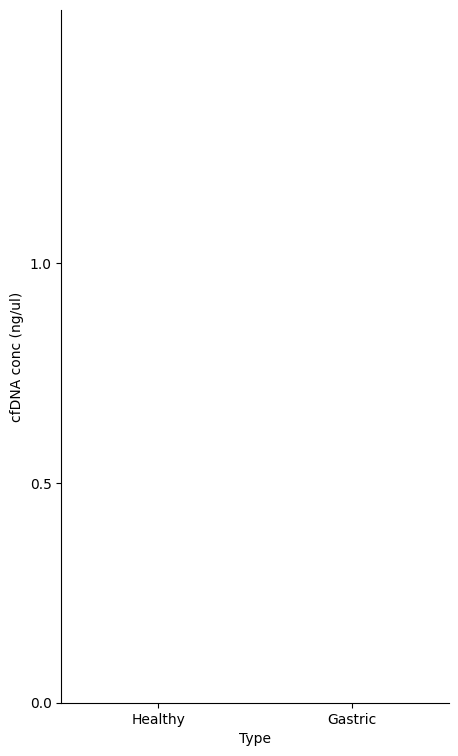

In [902]:
plt.figure(figsize=(5,9))
plt.figure(figsize=(5,9))
sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
           #palette=['b','g','r'],
           palette=['b','r'],
           #order=['Healthy','Gastric_benign','Gastric'],
           order=['Healthy','Gastric'],
           fill=False,linewidth=2,
           flierprops=dict(marker='.',markersize=3),
           showfliers=True,legend=False,
           dodge=False,width=0.8,gap=0.1)

sb.stripplot(data=sample_list_all,y='cfDNA conc',x='Type',
             #palette=['b','g','r'],size=4,marker='.',linewidth=0,legend=False,
             palette=['b','r'],size=4,marker='.',linewidth=0,legend=False,
             dodge=False,
             #order=['Healthy','Gastric_benign','Gastric'])
             order=['Healthy','Gastric'])

plt.ylim(1.5,1.5)
plt.yticks(np.arange(0,1.5,0.5))
plt.ylabel('cfDNA conc (ng/ul)')
plt.xlabel('Type')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axhline(y=2.5,ls='--',color='gray')


C:\Users\XN\AppData\Local\Temp\ipykernel_24948\2381808292.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=sample_list_all,
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\2381808292.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.stripplot(data=sample_list_all,


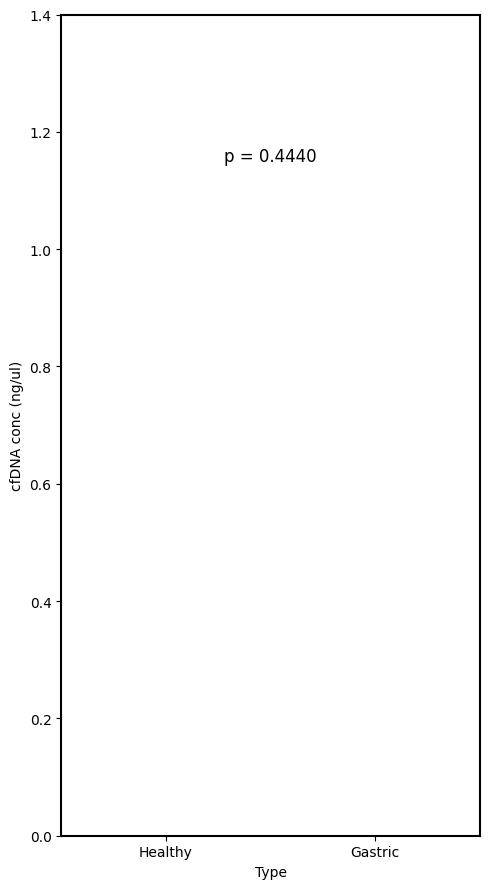

In [903]:
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kruskal

# Tính p-value theo nhóm 'Type'
groups = [group['cfDNA conc'].dropna().tolist()
          for _, group in sample_list_all.groupby('Type')]
stat, p_value = kruskal(*groups)

plt.figure(figsize=(5, 9))

# Boxplot: không fill, có viền màu
sb.boxplot(data=sample_list_all,
           y='cfDNA conc',
           x='Type',
           palette=['b', 'r'],
           order=['Healthy', 'Gastric'],
           fill=False,
           linewidth=2,
           flierprops=dict(marker='.', markersize=3),
           showfliers=True,
           dodge=False,
           width=0.8,
           gap=0.1)

# Scatter dot
sb.stripplot(data=sample_list_all,
             y='cfDNA conc',
             x='Type',
             palette=['b', 'r'],
             size=4,
             marker='.',
             linewidth=0,
             legend=False,
             dodge=False,
             order=['Healthy', 'Gastric'])

# Thiết lập trục tung
plt.ylim(0, 1.2)
plt.yticks(np.arange(0, 1.5, 0.2))

# Nhãn trục
plt.ylabel('cfDNA conc (ng/ul)')
plt.xlabel('Type')

# Viền quanh toàn bộ biểu đồ
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)

# Thêm giá trị p
plt.text(0.5, 1.15, f'p = {p_value:.4f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()




In [904]:
import numpy as np
import pandas as pd
from scipy import stats

# Tách 2 nhóm
healthy = sample_list_all[sample_list_all['Type'] == 'Healthy']['cfDNA conc']
gastric = sample_list_all[sample_list_all['Type'] == 'Gastric']['cfDNA conc']

# Tính trung vị
median_healthy = np.median(healthy)
median_gastric = np.median(gastric)

# Hàm tính khoảng tin cậy 95% bằng bootstrap
def bootstrap_ci(data, n_bootstrap=1000, ci=95):
    boot_medians = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        boot_medians.append(np.median(sample))
    lower = np.percentile(boot_medians, (100 - ci) / 2)
    upper = np.percentile(boot_medians, 100 - (100 - ci) / 2)
    return lower, upper

# Tính khoảng tin cậy
ci_healthy = bootstrap_ci(healthy)
ci_gastric = bootstrap_ci(gastric)

# Kiểm định Mann-Whitney U
u_stat, p_value = stats.mannwhitneyu(healthy, gastric, alternative='two-sided')

# In kết quả
print(f"Healthy Median: {median_healthy:.3f} ng/ul, 95% CI: {ci_healthy}")
print(f"Gastric Median: {median_gastric:.3f} ng/ul, 95% CI: {ci_gastric}")
print(f"Mann-Whitney U Test: U = {u_stat}, p = {p_value:.4f}")



Healthy Median: 7.688 ng/ul, 95% CI: (np.float64(6.698863636), np.float64(8.778947368))
Gastric Median: 7.745 ng/ul, 95% CI: (np.float64(7.133333333), np.float64(8.810681818181818))
Mann-Whitney U Test: U = 4925.0, p = 0.4447


C:\Users\XN\AppData\Local\Temp\ipykernel_24948\2712071788.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = gastric_df.groupby("tnm")["cfdna conc"].apply(list)


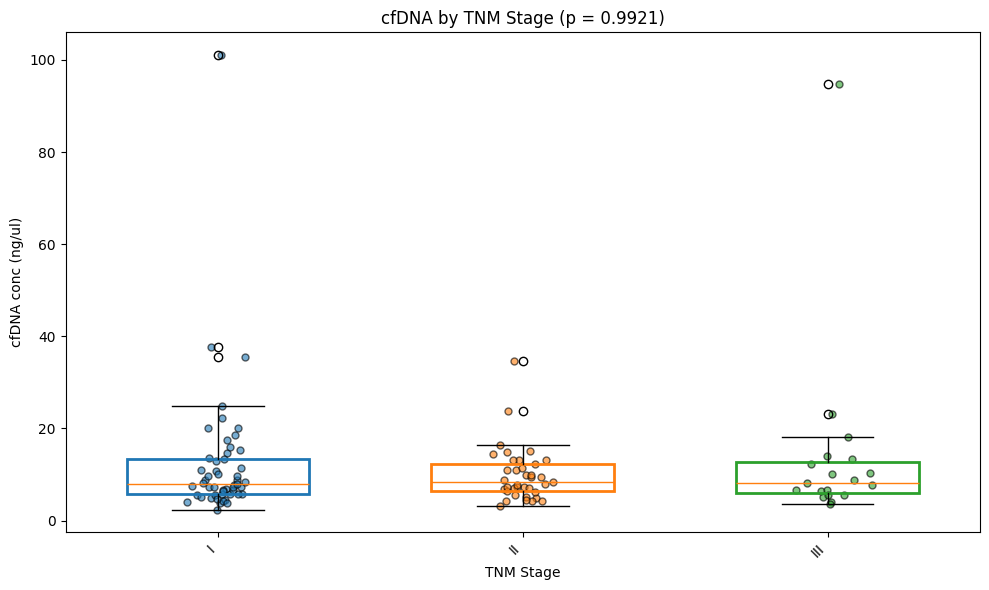

In [905]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import numpy as np

# Đọc dữ liệu
df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\Metadata.xlsx", sheet_name="QC")

# Chuẩn hóa tên cột
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={
    'loại mẫu': 'type',
    'giai đoạn theo tnm': 'tnm',
    'cfdna conc (ng/ml)': 'cfdna conc'
})

# Lọc dữ liệu gastric và loại bỏ NA
gastric_df = df[df['type'].str.lower() == 'gastric'].dropna(subset=['tnm', 'cfdna conc'])

# Đảm bảo thứ tự TNM
order = ['I', 'II', 'III']
gastric_df['tnm'] = pd.Categorical(gastric_df['tnm'], categories=order, ordered=True)

# Kiểm định Kruskal-Wallis
grouped = gastric_df.groupby("tnm")["cfdna conc"].apply(list)
stat, p_value = kruskal(*grouped)

# Thiết lập màu và vị trí
colors = plt.cm.tab10.colors[:len(order)]
positions = range(1, len(order) + 1)

# Vẽ boxplot
plt.figure(figsize=(10, 6))
box = plt.boxplot(
    [grouped[cat] for cat in order],
    positions=positions,
    patch_artist=True,
    widths=0.6
)

# Chỉnh boxplot: trong suốt, có viền màu
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor('none')           # Trong suốt
    patch.set_edgecolor(color)
    patch.set_linewidth(2)

# Scatter dot nhỏ hơn
for i, cat in enumerate(order):
    y = grouped[cat]
    x = np.random.normal(loc=positions[i], scale=0.05, size=len(y))
    plt.scatter(x, y, color=colors[i], alpha=0.6, edgecolors='k', s=25)

# Thiết lập biểu đồ
plt.xticks(positions, order, rotation=45, ha='right')
plt.xlabel("TNM Stage")
plt.ylabel("cfDNA conc (ng/ul)")
plt.title(f"cfDNA by TNM Stage (p = {p_value:.4f})")
plt.grid(False)
plt.tight_layout()
plt.show()



THỐNG KÊ ĐẶC ĐIỂM ĐỐI TƯỢNG NC

In [906]:
# THỐNG KÊ THEO GIỚI

import pandas as pd
from scipy.stats import chi2_contingency

# 1. Đọc dữ liệu
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\Metadata.xlsx"
data = pd.read_excel(file_path, sheet_name='QC')

# 2. Loại bỏ giá trị trống (NaN) ở các cột quan trọng trước khi xử lý
data = data.dropna(subset=['Type', 'Giới tính'])

# 3. Lọc dữ liệu nhóm Gastric và Healthy
filtered_data = data[data['Type'].isin(['Gastric', 'Healthy'])].copy()

# 4. Chuẩn hóa giá trị giới tính
# Sử dụng mapping để đưa tất cả các dạng về 'Male' và 'Female'
gender_map = {
    'Nam': 'Male', 'M': 'Male', 'Male': 'Male',
    'Nữ': 'Female', 'F': 'Female', 'Female': 'Female', 'NỮ': 'Female', 'NAM': 'Male'
}

# Loại bỏ khoảng trắng và chuẩn hóa
filtered_data['Giới tính'] = filtered_data['Giới tính'].str.strip()
filtered_data['Giới tính'] = filtered_data['Giới tính'].replace(gender_map)

# Loại bỏ những dòng có giá trị giới tính không nằm trong danh sách chuẩn hóa (nếu có)
filtered_data = filtered_data[filtered_data['Giới tính'].isin(['Male', 'Female'])]

# 5. Đếm số lượng và tính tỷ lệ (%)
gender_counts = pd.crosstab(filtered_data['Giới tính'], filtered_data['Type'])

# Kiểm tra nếu bảng gender_counts có đủ dữ liệu để tránh lỗi Index
if not gender_counts.empty:
    # 6. Tạo bảng định dạng theo yêu cầu của bạn
    # Tính toán trực tiếp để bảng chuyên nghiệp hơn
    result_data = {
        ("Gender", "Gastric", "N"): [gender_counts.get("Gastric", {}).get("Male", 0), 
                                     gender_counts.get("Gastric", {}).get("Female", 0)],
        ("Gender", "Gastric", "%"): [(gender_counts.get("Gastric", {}).get("Male", 0) / gender_counts["Gastric"].sum() * 100),
                                     (gender_counts.get("Gastric", {}).get("Female", 0) / gender_counts["Gastric"].sum() * 100)],
        ("Gender", "Healthy", "N"): [gender_counts.get("Healthy", {}).get("Male", 0), 
                                     gender_counts.get("Healthy", {}).get("Female", 0)],
        ("Gender", "Healthy", "%"): [(gender_counts.get("Healthy", {}).get("Male", 0) / gender_counts["Healthy"].sum() * 100),
                                     (gender_counts.get("Healthy", {}).get("Female", 0) / gender_counts["Healthy"].sum() * 100)]
    }

    formatted_table = pd.DataFrame(result_data, index=["Male", "Female"])
    formatted_table.columns = pd.MultiIndex.from_tuples(formatted_table.columns)

    print("Bảng kết quả giới tính theo nhóm:")
    print(formatted_table.round(2)) # Làm tròn 2 chữ số thập phân

    # 7. Thực hiện kiểm định Chi-squared
    # Lưu ý: gender_counts hiện tại đang có index là Giới tính, columns là Type (phù hợp cho chi2)
    chi2_stat, p_value, dof, expected = chi2_contingency(gender_counts)

    # Diễn giải kết quả
    interpretation = "Có sự khác biệt có ý nghĩa thống kê (p < 0.05)" if p_value < 0.05 else "Không có sự khác biệt có ý nghĩa thống kê (p ≥ 0.05)"

    print("\nKết quả kiểm định Chi-squared:")
    print(f"Chi-squared statistic: {chi2_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Degrees of freedom: {dof}")
    print("Phiên giải:", interpretation)
else:
    print("Không có dữ liệu phù hợp sau khi lọc.")

Bảng kết quả giới tính theo nhóm:
        Gender                      
       Gastric        Healthy       
             N      %       N      %
Male        68  61.82      61  55.45
Female      42  38.18      49  44.55

Kết quả kiểm định Chi-squared:
Chi-squared statistic: 0.6747
p-value: 0.4114
Degrees of freedom: 1
Phiên giải: Không có sự khác biệt có ý nghĩa thống kê (p ≥ 0.05)


In [907]:
# THỐNG KÊ THEO TUỔI

import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, chi2_contingency

# 📥 Đọc dữ liệu
file_path = r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\Metadata.xlsx"
data = pd.read_excel(file_path, sheet_name='QC')

# 🎯 Lọc dữ liệu chỉ lấy nhóm Gastric và Healthy
filtered_data = data[data['Type'].isin(['Gastric', 'Healthy'])].copy()
filtered_data['Giới tính'] = filtered_data['Giới tính'].str.strip()  # Chuẩn hóa giới tính

# =========================================
# 📌 1. TÍNH TUỔI + KIỂM ĐỊNH SỰ KHÁC BIỆT
print("📊 Thống kê tuổi theo nhóm:")
for group in ['Gastric', 'Healthy']:
    ages = filtered_data[filtered_data['Type'] == group]['Tuổi'].dropna()
    print(f"\n{group}:")
    print(f"  Số lượng: {len(ages)}")
    print(f"  Mean: {ages.mean():.2f}")
    print(f"  Min: {ages.min()}, Max: {ages.max()}")
    print(f"  Median: {ages.median():.2f}")

# 🧪 Kiểm định phân phối tuổi (Shapiro-Wilk)
gastric_age = filtered_data[filtered_data['Type'] == 'Gastric']['Tuổi'].dropna()
healthy_age = filtered_data[filtered_data['Type'] == 'Healthy']['Tuổi'].dropna()

_, p_gastric = shapiro(gastric_age)
_, p_healthy = shapiro(healthy_age)
print("\n🔍 Kiểm định phân phối tuổi (Shapiro-Wilk):")
print(f"  Gastric: p = {p_gastric:.4f} {'✅ Bình thường' if p_gastric >= 0.05 else '❌ Không bình thường'}")
print(f"  Healthy: p = {p_healthy:.4f} {'✅ Bình thường' if p_healthy >= 0.05 else '❌ Không bình thường'}")

# 🧪 Kiểm định sự khác biệt tuổi giữa 2 nhóm
if p_gastric >= 0.05 and p_healthy >= 0.05:
    stat, p_age = ttest_ind(gastric_age, healthy_age)
    method = "T-test"
else:
    stat, p_age = mannwhitneyu(gastric_age, healthy_age, alternative='two-sided')
    method = "Mann-Whitney U test"

print(f"\n🧪 {method} giữa Gastric và Healthy:")
print(f"  Statistic: {stat:.4f}, p-value: {p_age:.4g}")
if p_age < 0.05:
    print("  ✅ Kết luận: Có sự khác biệt tuổi giữa Gastric và Healthy.")
else:
    print("  ❌ Kết luận: Không có sự khác biệt tuổi giữa Gastric và Healthy.")



📊 Thống kê tuổi theo nhóm:

Gastric:
  Số lượng: 110
  Mean: 61.65
  Min: 35.0, Max: 86.0
  Median: 62.50

Healthy:
  Số lượng: 110
  Mean: 60.94
  Min: 31.0, Max: 85.0
  Median: 61.00

🔍 Kiểm định phân phối tuổi (Shapiro-Wilk):
  Gastric: p = 0.4862 ✅ Bình thường
  Healthy: p = 0.6182 ✅ Bình thường

🧪 T-test giữa Gastric và Healthy:
  Statistic: 0.4989, p-value: 0.6183
  ❌ Kết luận: Không có sự khác biệt tuổi giữa Gastric và Healthy.


[*] Đã loại bỏ 8 giá trị ngoại lai cho cột 'cfDNA conc'

--- KIỂM ĐỊNH PHÂN PHỐI CHUẨN (SHAPIRO-WILK) ---
Nhóm Healthy: p = 0.0100 -> Không chuẩn
Nhóm Gastric: p = 0.0003 -> Không chuẩn
--------------------------------------------------
Kết quả Mann-Whitney U Test: p-value = 1.9587e-01
Kết luận: Không có sự khác biệt ý nghĩa
--------------------------------------------------


C:\Users\XN\AppData\Local\Temp\ipykernel_24948\989994367.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.boxplot(data=sample_list_all, y='cfDNA conc', x='Type',
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\989994367.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.stripplot(data=sample_list_all, y='cfDNA conc', x='Type',


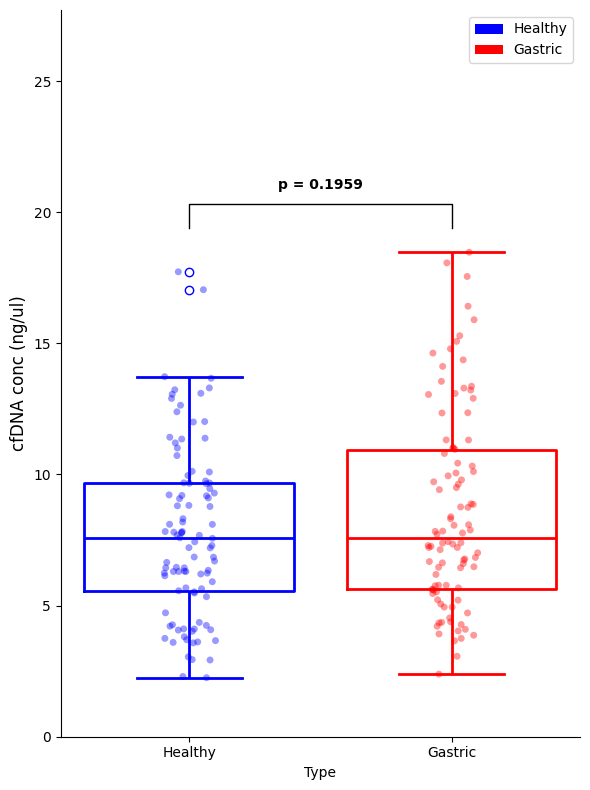

In [908]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy import stats

# 1. LOẠI BỎ GIÁ TRỊ NGOẠI LAI (OUTLIERS) BẰNG PHƯƠNG PHÁP IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc dữ liệu
    df_clean = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    outliers_count = len(df) - len(df_clean)
    print(f"[*] Đã loại bỏ {outliers_count} giá trị ngoại lai cho cột '{column}'")
    return df_clean

# Thực hiện loại bỏ outliers trước khi phân tích
sample_list_all = remove_outliers(sample_list_all, 'cfDNA conc')

# 2. KHẢO SÁT PHÂN BỐ DỮ LIỆU (Normality Test)
print("\n--- KIỂM ĐỊNH PHÂN PHỐI CHUẨN (SHAPIRO-WILK) ---")
for g in ['Healthy', 'Gastric']:
    data = sample_list_all[sample_list_all['Type'] == g]['cfDNA conc'].dropna()
    stat, p_norm = stats.shapiro(data)
    print(f"Nhóm {g}: p = {p_norm:.4f} -> {'Chuẩn' if p_norm > 0.05 else 'Không chuẩn'}")

# 3. CHỌN THUẬT TOÁN KIỂM ĐỊNH
# Nếu ít nhất 1 nhóm không chuẩn -> dùng Mann-Whitney U (Phi tham số)
group1 = sample_list_all[sample_list_all['Type'] == 'Healthy']['cfDNA conc']
group2 = sample_list_all[sample_list_all['Type'] == 'Gastric']['cfDNA conc']
u_stat, p_val = stats.mannwhitneyu(group1, group2, alternative='two-sided')

# 4. PHIÊN GIẢI KẾT QUẢ
print("-" * 50)
print(f"Kết quả Mann-Whitney U Test: p-value = {p_val:.4e}")
interpretation = "Có sự khác biệt ý nghĩa" if p_val < 0.05 else "Không có sự khác biệt ý nghĩa"
print(f"Kết luận: {interpretation}")
print("-" * 50)

# 5. VẼ BIỂU ĐỒ VỚI MÀU GASTRIC ĐỎ VÀ CHÚ GIẢI
plt.figure(figsize=(6, 8))
my_pal = {'Healthy': 'blue', 'Gastric': 'red'} # 4. Thay màu Gastric là đỏ

ax = sb.boxplot(data=sample_list_all, y='cfDNA conc', x='Type',
                palette=my_pal, order=['Healthy', 'Gastric'],
                fill=False, linewidth=2, showfliers=True)

sb.stripplot(data=sample_list_all, y='cfDNA conc', x='Type',
             palette=my_pal, size=5, alpha=0.4, order=['Healthy', 'Gastric'])

# HIỂN THỊ P-VALUE TRÊN BIỂU ĐỒ
y_max = sample_list_all['cfDNA conc'].max()
h = y_max * 0.05
plt.plot([0, 0, 1, 1], [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h], lw=1, c='k')
plt.text(0.5, y_max + 2.5*h, f"p = {p_val:.4f}", ha='center', va='bottom', fontweight='bold')

# 5. THÊM CHÚ GIẢI MÀU SẮC
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Healthy'),
    Patch(facecolor='red', label='Gastric')
]
plt.legend(handles=legend_elements,  loc='upper right')

# ĐỊNH DẠNG TRỤC
plt.ylabel('cfDNA conc (ng/ul)', fontsize=12)
plt.ylim(0, y_max + 10*h) # Để không gian cho p-value
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

C:\Users\XN\AppData\Local\Temp\ipykernel_24948\1997597656.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\1997597656.py:4: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\1997597656.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.stripplot(data=sample_list_all,y='cfDNA conc',x='Type',
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\1997597656.py:13: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sb.stri

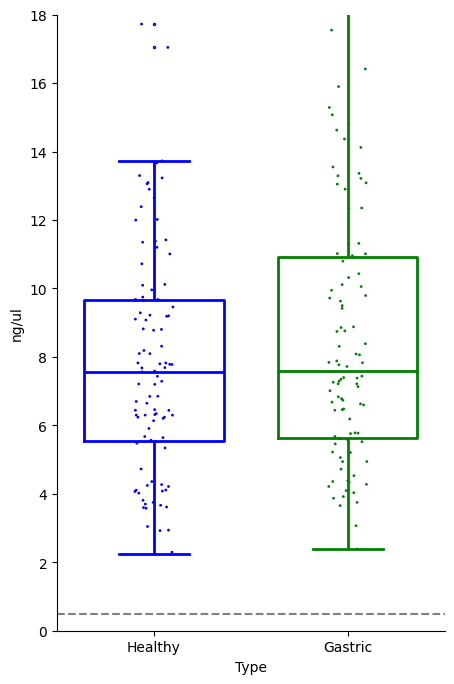

In [909]:
# NỒNG ĐỘ CFDNA Yield

plt.figure(figsize=(5,8))
sb.boxplot(data=sample_list_all,y='cfDNA conc',x='Type',
           palette=['b','g','r'],
           #order=['Healthy','Gastric_benign','Gastric'],
           order=['Healthy','Gastric'],
           fill=False,linewidth=2,
           flierprops=dict(marker='.',markersize=3),
           showfliers=True,legend=False,
           dodge=False,width=0.8,gap=0.1)

sb.stripplot(data=sample_list_all,y='cfDNA conc',x='Type',
             palette=['b','g','r'],size=4,marker='.',linewidth=0,legend=False,
             dodge=False,
             #order=['Healthy','Gastric_benign','Gastric'])
             order=['Healthy','Gastric'])

plt.ylim(2,9)
plt.yticks(np.arange(0,20,2))
plt.ylabel('ng/ul')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axhline(y=0.5,ls='--',color='gray')

In [910]:
# Lấy danh sách tên các nhóm (EM, FLEN, NFP, CNA...) từ dictionary DATA
features = list(DATA.keys()) 

FEATURES=[]
Group=[]

features
# ... (phần còn lại của code bạn)

['EM', 'FLEN', 'NFP', 'CNA', 'SCNA', 'RATIOSL', 'RATIOST']

In [911]:
from scipy.stats import shapiro  # Sửa lỗi name 'shapiro' is not defined
from statsmodels.stats.multitest import fdrcorrection # Để tránh lỗi tiếp theo với fdrcorrection
import pandas as pd

# THỐNG KÊ

In [912]:
FEATURES=[]
Group=[]
P_value=[]
for f in features:
    p_value=[]
    vector=[]
    for s in list(DATA[f]['SampleID']):
        if s in list(sample_list_all['SampleID']):
            vector+=[True]
        else:
            vector+=[False]
    data=DATA[f][vector]

    for c in data.columns[1:]:
        FEATURES+=[c]
        Group+=[f]
        p_value+=[shapiro(data[c])[1]]
    P_value+=list(fdrcorrection(p_value)[1])
df_norm=pd.DataFrame({
    'FEATURES':FEATURES,
    'Group':Group,
    'p_value':P_value
})
df_norm

c:\Users\XN\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


,FEATURES,Group,p_value
0,EM_AAAA,EM,0.511817
1,EM_AAAC,EM,0.445250
2,EM_AAAG,EM,0.514971
3,EM_AAAT,EM,0.183217
4,EM_AACA,EM,0.357062
...,...,...,...
10783,RATIOST_Y:10000001-11000000,RATIOST,0.556861
10784,RATIOST_Y:13000001-14000000,RATIOST,0.008328
10785,RATIOST_Y:58000001-59000000,RATIOST,0.562730
10786,RATIOST_Y:59000001-59373566,RATIOST,0.450323


In [913]:
df_norm['Group'].value_counts()

Group
RATIOST    2874
RATIOSL    2872
SCNA       1942
CNA        1942
NFP         601
FLEN        301
EM          256
Name: count, dtype: int64

In [914]:
df_norm[df_norm['p_value']>0.05]['Group'].value_counts()

Group
SCNA       1880
CNA        1780
NFP         509
RATIOST     480
EM          166
FLEN        108
RATIOSL      16
Name: count, dtype: int64

In [915]:
df_norm[df_norm['p_value']<0.05]['Group'].value_counts()

Group
RATIOSL    2856
RATIOST    2394
FLEN        193
CNA         162
NFP          92
EM           90
SCNA         62
Name: count, dtype: int64

In [916]:
df_norm[df_norm['p_value']>0.05]

,FEATURES,Group,p_value
0,EM_AAAA,EM,0.511817
1,EM_AAAC,EM,0.445250
2,EM_AAAG,EM,0.514971
3,EM_AAAT,EM,0.183217
4,EM_AACA,EM,0.357062
...,...,...,...
10774,RATIOST_X:91000001-92000000,RATIOST,0.054728
10783,RATIOST_Y:10000001-11000000,RATIOST,0.556861
10785,RATIOST_Y:58000001-59000000,RATIOST,0.562730
10786,RATIOST_Y:59000001-59373566,RATIOST,0.450323


In [917]:
df_norm[df_norm['p_value']<0.05]

,FEATURES,Group,p_value
5,EM_AACC,EM,0.045152
9,EM_AAGC,EM,0.000115
22,EM_ACCG,EM,0.011126
24,EM_ACGA,EM,0.000025
25,EM_ACGC,EM,0.013882
...,...,...,...
10779,RATIOST_X:96000001-97000000,RATIOST,0.020208
10780,RATIOST_X:97000001-98000000,RATIOST,0.020679
10781,RATIOST_X:98000001-99000000,RATIOST,0.011636
10782,RATIOST_X:99000001-100000000,RATIOST,0.008766


In [918]:
list_columns_vlookup=[exp_id+'Cohort','Label','Class','Type','Age','Gender']

In [919]:
col_start=len(list_columns_vlookup)+1
col_start


7

In [920]:
#PAIR=[
#    'Healthy vs Gastric',
#    'Gastric_benign vs Gastric',
#    'Nongastric vs Gastric'
#]
PAIR=[
    'Healthy vs Gastric',
]


In [921]:
# KIỂM TRA DATA
DATA[f]

,SampleID,RATIOST_1:1-1000000,RATIOST_1:100000001-101000000,RATIOST_1:10000001-11000000,RATIOST_1:1000001-2000000,RATIOST_1:101000001-102000000,RATIOST_1:102000001-103000000,RATIOST_1:103000001-104000000,RATIOST_1:104000001-105000000,RATIOST_1:105000001-106000000,...,RATIOST_X:95000001-96000000,RATIOST_X:96000001-97000000,RATIOST_X:97000001-98000000,RATIOST_X:98000001-99000000,RATIOST_X:99000001-100000000,RATIOST_Y:10000001-11000000,RATIOST_Y:13000001-14000000,RATIOST_Y:58000001-59000000,RATIOST_Y:59000001-59373566,RATIOST_Y:9000001-10000000
0,HNGK001,0.226644,0.209825,0.209493,0.218494,0.202365,0.185490,0.171655,0.192880,0.191092,...,0.177888,0.211317,0.184211,0.172468,0.188302,0.192223,0.340081,0.266016,0.193838,0.182969
1,HNGK003,0.182502,0.178977,0.170899,0.188009,0.176734,0.161829,0.168865,0.170177,0.161390,...,0.156370,0.158906,0.160806,0.162823,0.172150,0.224638,0.394446,0.262044,0.185547,0.172745
2,HNGK004,0.206230,0.187008,0.173917,0.179331,0.178195,0.169860,0.168094,0.173068,0.176318,...,0.167851,0.166236,0.163362,0.164331,0.162612,0.278174,0.357880,0.293356,0.181126,0.191829
3,HNGK005,0.194946,0.194314,0.191932,0.187002,0.180443,0.173780,0.179732,0.178269,0.183539,...,0.179288,0.181789,0.175604,0.183060,0.170902,0.205641,0.292221,0.272422,0.170022,0.175981
4,HNGK006,0.175398,0.157367,0.158132,0.171813,0.150318,0.139337,0.126467,0.146621,0.148490,...,0.142212,0.139520,0.139645,0.134600,0.139321,0.161937,0.363341,0.274136,0.174576,0.173540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGH149,0.157604,0.149646,0.147312,0.158606,0.142153,0.136315,0.139666,0.141978,0.140447,...,0.139094,0.136088,0.129876,0.145894,0.130359,0.137868,0.340979,0.242967,0.189542,0.163399
358,HNGK204,0.155192,0.150848,0.156292,0.174536,0.143658,0.129368,0.139581,0.132970,0.133943,...,0.133957,0.130875,0.136023,0.132854,0.130957,0.226328,0.345045,0.267626,0.164794,0.179669
359,HNGK205,0.134680,0.126956,0.144991,0.149348,0.125182,0.116550,0.120450,0.120482,0.119098,...,0.121514,0.129256,0.112679,0.111337,0.121825,0.158889,0.239701,0.215807,0.152364,0.117838
360,HNGK206,0.130654,0.118283,0.129287,0.133918,0.118194,0.113212,0.103902,0.116590,0.110939,...,0.109625,0.119543,0.110955,0.111725,0.106177,0.140858,0.355140,0.227390,0.133415,0.143337


In [922]:
# Chỉ mở để chạy 1 lần cùng với đoạn code bên dưới
stats_fea={}
for f in features:
    result=pd.DataFrame()
    for p in PAIR:
        name_1=p.split(' vs ')[0]
        name_2=p.split(' vs ')[1]

        vector1=[]
        for s in list(DATA[f]['SampleID']):
            if s in list(SAMPLES[name_1]['SampleID']):
                vector1+=[True]
            else:
                vector1+=[False]
        df_1=DATA[f][vector1]

        vector2=[]
        for s in list(DATA[f]['SampleID']):
            if s in list(SAMPLES[name_2]['SampleID']):
                vector2+=[True]
            else:
                vector2+=[False]
        df_2=DATA[f][vector2]

        stats_bi=STATS_binary(df_1=df_1,df_2=df_2,col_start=1,name_1=name_1,name_2=name_2,groups_PADJ=[f])
        result=pd.concat([result,stats_bi],axis=1)
    else:
        result = result.loc[:,~result.columns.duplicated()].copy()
        stats_fea[f]=result

In [923]:
# !!!! Chỉ chạy 1 lần xong khóa code lại 
with pd.ExcelWriter(exp_id + '_STATS.xlsx') as writer:
   for f in features:
        if f not in ['CONCAT', 'CONCAT21', 'CONCAT21TM']:
            stats_fea[f].to_excel(writer, sheet_name=f, index=False)


In [924]:
stats_fea={}
for f in features:
    stats_fea[f]=pd.read_excel(exp_id+'_STATS.xlsx',sheet_name=f)
    
    

In [925]:
stats_fea['EM']

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,EM_AAAA,0.009279,0.009271,0.009330,0.009319,0.000591,0.000574,6.370620,6.189656,3.583678,...,-0.001232,-0.001557,0.994859,0.998286,0.01,0.01,0.000745,-7.921972e-06,0.499747,0.500253
1,EM_AAAC,0.003778,0.003756,0.003763,0.003756,0.000156,0.000144,4.122291,3.823563,3.350041,...,-0.008067,-0.002561,0.247915,0.966759,0.00,0.00,0.014682,-2.106251e-05,0.454714,0.545286
2,EM_AAAG,0.005792,0.005793,0.005816,0.005833,0.000249,0.000258,4.296193,4.459845,3.556805,...,0.000205,0.004256,0.851783,0.966759,0.01,0.01,0.014682,8.244419e-07,0.507323,0.507323
3,EM_AAAT,0.005934,0.005922,0.005944,0.005940,0.000388,0.000335,6.538555,5.662525,3.465660,...,-0.002907,-0.000975,0.689554,0.966759,0.01,0.01,0.014682,-1.194334e-05,0.484343,0.515657
4,EM_AACA,0.004183,0.004189,0.004185,0.004186,0.000151,0.000164,3.616233,3.921973,3.418687,...,0.001972,0.000237,0.829952,0.966759,0.00,0.00,0.014682,5.722481e-06,0.491582,0.491582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,EM_TTGT,0.001537,0.001535,0.001529,0.001526,0.000176,0.000143,11.468066,9.300642,3.299365,...,-0.001073,-0.002157,0.894072,0.973773,0.00,0.00,0.011542,-1.142761e-06,0.505219,0.494781
252,EM_TTTA,0.003298,0.003271,0.003331,0.003277,0.000426,0.000377,12.906861,11.524469,3.627502,...,-0.011817,-0.023653,0.497358,0.966759,0.00,0.00,0.014682,-2.690190e-05,0.473401,0.526599
253,EM_TTTC,0.002392,0.002384,0.002423,0.002386,0.000234,0.000213,9.760968,8.941065,3.452104,...,-0.005206,-0.022140,0.550479,0.966759,0.00,0.00,0.014682,-8.617156e-06,0.476599,0.523401
254,EM_TTTG,0.001873,0.001881,0.001879,0.001875,0.000211,0.000191,11.258847,10.126253,3.470782,...,0.006343,-0.003163,0.924715,0.973773,0.00,0.00,0.011542,8.252851e-06,0.503704,0.503704


In [926]:
# THỐNG KÊ SỐ LƯỢNG FEATURES GIẢM TẦN SUẤT CÓ Ý NGHĨA TKE

Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[(df['PADJ of '+p]<0.05)&(df['Log2FC Median of '+p]<0)])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,EM,FLEN,NFP,CNA,SCNA,RATIOSL,RATIOST
0,Healthy vs Gastric,0,0,0,0,0,0,0


In [927]:
Thong_ke_stats_split.to_clipboard(index=False)

In [928]:
# THỐNG KÊ SỐ LƯỢNG FEATURES TĂNG TẦN SUẤT CÓ Ý NGHĨA TKE

Thong_ke_stats_split=pd.DataFrame({'Pairs':PAIR})  
for f in features:
    lst=[]
    df=stats_fea[f]
    for p in PAIR:
        lst+=[len(df[(df['PADJ of '+p]<0.05)&(df['Log2FC Median of '+p]>=0)])]
    Thong_ke_stats_split[f]=lst
Thong_ke_stats_split

,Pairs,EM,FLEN,NFP,CNA,SCNA,RATIOSL,RATIOST
0,Healthy vs Gastric,0,0,0,0,0,0,0


In [929]:
Thong_ke_stats_split.to_clipboard(index=False)

EM ven

In [930]:
#f='EM'
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

In [931]:
#f='EM'
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

EM heatmap log2FC

In [932]:
p=PAIR[0]
# p=PAIR[1]
# p=PAIR[2]

In [933]:
sample_list=pd.concat([SAMPLES[p.split(' vs ')[0]],SAMPLES[p.split(' vs ')[1]]],axis=0)
sample_list

,SampleID,Labcode,Cohort_Hồ gửi,Cohort,Type,Phân loại,Label,No,Testcode,Labcode M0,...,V plasma tách chiết (ml)_HNG,Original cfDNA conc (ng/uL),cfDNA elution volume (ul)_HNG,cfDNA yield (ng/ml plasma)_HNG,Diluted cfDNA conc (ng/uL)_HNG,cfDNA input volume (ul)_HNG,cfDNA Input (ng)_HNG,V H2O (ul)_HNG,Primer_HNG,Lib prep conc (ng/ul)_HNG
2,HNGH003,HNGH003,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,3,C2,HNGH003,...,2.00,0.153,30,2.295,0.153,18.0,2.754,0.000,579,55.0
4,HNGH005,HNGH005,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,5,C5,HNGH005,...,1.50,0.498,30,9.960,0.498,10.0,4.980,8.000,605,34.0
5,HNGH006,HNGH006,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,6,C6,HNGH006,...,1.76,0.882,30,13.230,0.882,5.0,4.410,13.000,606,27.0
6,HNGH007,HNGH007,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,7,C7,HNGH007,...,1.76,0.645,30,9.675,0.645,7.0,4.515,11.000,609,35.0
11,HNGH012,HNGH012,Gastric Dr Dung,Discovery,Healthy,Healthy,0.0,12,C12,HNGH012,...,1.50,0.390,30,7.800,0.390,12.0,4.680,6.000,614,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,HNGK031,HNGK031,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,191,P30,HNGK031,...,1.00,0.277,30,8.310,0.277,18.0,4.986,4.986,580,30.0
358,HNGK032,HNGK032,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,192,P31,HNGK032,...,1.00,0.221,30,6.630,0.221,18.0,3.978,3.978,581,25.0
359,HNGK033,HNGK033,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,193,P32,HNGK033,...,1.00,0.243,30,7.290,0.243,18.0,4.374,4.374,582,19.0
360,HNGK034,HNGK034,Gastric Dr Dung,Discovery,Gastric,Gastric,1.0,194,P33,HNGK034,...,1.00,0.151,30,4.530,0.151,18.0,2.718,0.000,583,17.0


In [934]:
result=pd.DataFrame(stats_fea['EM'])
result['nu_start']=result.apply(lambda row: row['FEATURES'][-4],axis=1)
result.index=result.apply(lambda row: row['FEATURES'][-4:],axis=1)
result.sort_values(by=['nu_start','Mean of '+p.split(' vs ')[0],],ascending=True)
result

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric,nu_start
AAAA,EM_AAAA,0.009279,0.009271,0.009330,0.009319,0.000591,0.000574,6.370620,6.189656,3.583678,...,-0.001557,0.994859,0.998286,0.01,0.01,0.000745,-7.921972e-06,0.499747,0.500253,A
AAAC,EM_AAAC,0.003778,0.003756,0.003763,0.003756,0.000156,0.000144,4.122291,3.823563,3.350041,...,-0.002561,0.247915,0.966759,0.00,0.00,0.014682,-2.106251e-05,0.454714,0.545286,A
AAAG,EM_AAAG,0.005792,0.005793,0.005816,0.005833,0.000249,0.000258,4.296193,4.459845,3.556805,...,0.004256,0.851783,0.966759,0.01,0.01,0.014682,8.244419e-07,0.507323,0.507323,A
AAAT,EM_AAAT,0.005934,0.005922,0.005944,0.005940,0.000388,0.000335,6.538555,5.662525,3.465660,...,-0.000975,0.689554,0.966759,0.01,0.01,0.014682,-1.194334e-05,0.484343,0.515657,A
AACA,EM_AACA,0.004183,0.004189,0.004185,0.004186,0.000151,0.000164,3.616233,3.921973,3.418687,...,0.000237,0.829952,0.966759,0.00,0.00,0.014682,5.722481e-06,0.491582,0.491582,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGT,EM_TTGT,0.001537,0.001535,0.001529,0.001526,0.000176,0.000143,11.468066,9.300642,3.299365,...,-0.002157,0.894072,0.973773,0.00,0.00,0.011542,-1.142761e-06,0.505219,0.494781,T
TTTA,EM_TTTA,0.003298,0.003271,0.003331,0.003277,0.000426,0.000377,12.906861,11.524469,3.627502,...,-0.023653,0.497358,0.966759,0.00,0.00,0.014682,-2.690190e-05,0.473401,0.526599,T
TTTC,EM_TTTC,0.002392,0.002384,0.002423,0.002386,0.000234,0.000213,9.760968,8.941065,3.452104,...,-0.022140,0.550479,0.966759,0.00,0.00,0.014682,-8.617156e-06,0.476599,0.523401,T
TTTG,EM_TTTG,0.001873,0.001881,0.001879,0.001875,0.000211,0.000191,11.258847,10.126253,3.470782,...,-0.003163,0.924715,0.973773,0.00,0.00,0.011542,8.252851e-06,0.503704,0.503704,T


In [935]:
result['Log2FC_+-']=result.apply(lambda r: 0 if r['Log2FC Median of '+p]<0 else 1,axis=1)
result['ABS Log2FC Median of '+p]=result.apply(lambda r: abs(r['Log2FC Median of '+p]),axis=1)
result['Sig']=result.apply(lambda r: 0 if r['PADJ of '+p] <=0.05 else 1,axis=1)
nu_start_order=[]
for nu_start in result['nu_start']:
    if nu_start == 'A':
        nu_start_order+=[0]
    elif nu_start == 'T':
        nu_start_order+=[1]
    elif nu_start == 'G':
        nu_start_order+=[2]
    elif nu_start == 'C':
        nu_start_order+=[3]    
result['nu_start_order']=nu_start_order
result

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric,nu_start,Log2FC_+-,ABS Log2FC Median of Healthy vs Gastric,Sig,nu_start_order
AAAA,EM_AAAA,0.009279,0.009271,0.009330,0.009319,0.000591,0.000574,6.370620,6.189656,3.583678,...,0.01,0.000745,-7.921972e-06,0.499747,0.500253,A,0,0.001557,1,0
AAAC,EM_AAAC,0.003778,0.003756,0.003763,0.003756,0.000156,0.000144,4.122291,3.823563,3.350041,...,0.00,0.014682,-2.106251e-05,0.454714,0.545286,A,0,0.002561,1,0
AAAG,EM_AAAG,0.005792,0.005793,0.005816,0.005833,0.000249,0.000258,4.296193,4.459845,3.556805,...,0.01,0.014682,8.244419e-07,0.507323,0.507323,A,1,0.004256,1,0
AAAT,EM_AAAT,0.005934,0.005922,0.005944,0.005940,0.000388,0.000335,6.538555,5.662525,3.465660,...,0.01,0.014682,-1.194334e-05,0.484343,0.515657,A,0,0.000975,1,0
AACA,EM_AACA,0.004183,0.004189,0.004185,0.004186,0.000151,0.000164,3.616233,3.921973,3.418687,...,0.00,0.014682,5.722481e-06,0.491582,0.491582,A,1,0.000237,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGT,EM_TTGT,0.001537,0.001535,0.001529,0.001526,0.000176,0.000143,11.468066,9.300642,3.299365,...,0.00,0.011542,-1.142761e-06,0.505219,0.494781,T,0,0.002157,1,1
TTTA,EM_TTTA,0.003298,0.003271,0.003331,0.003277,0.000426,0.000377,12.906861,11.524469,3.627502,...,0.00,0.014682,-2.690190e-05,0.473401,0.526599,T,0,0.023653,1,1
TTTC,EM_TTTC,0.002392,0.002384,0.002423,0.002386,0.000234,0.000213,9.760968,8.941065,3.452104,...,0.00,0.014682,-8.617156e-06,0.476599,0.523401,T,0,0.022140,1,1
TTTG,EM_TTTG,0.001873,0.001881,0.001879,0.001875,0.000211,0.000191,11.258847,10.126253,3.470782,...,0.00,0.011542,8.252851e-06,0.503704,0.503704,T,0,0.003163,1,1


C:\Users\XN\AppData\Local\Temp\ipykernel_24948\2400276928.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\2400276928.py:87: UserWarning: 
The palette list has fewer values (1) than needed (64) and will cycle, which may produce an uninterpretable plot.
  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users\XN\AppData\Local\Temp\ipykernel_24948\2400276928.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
C:\Users

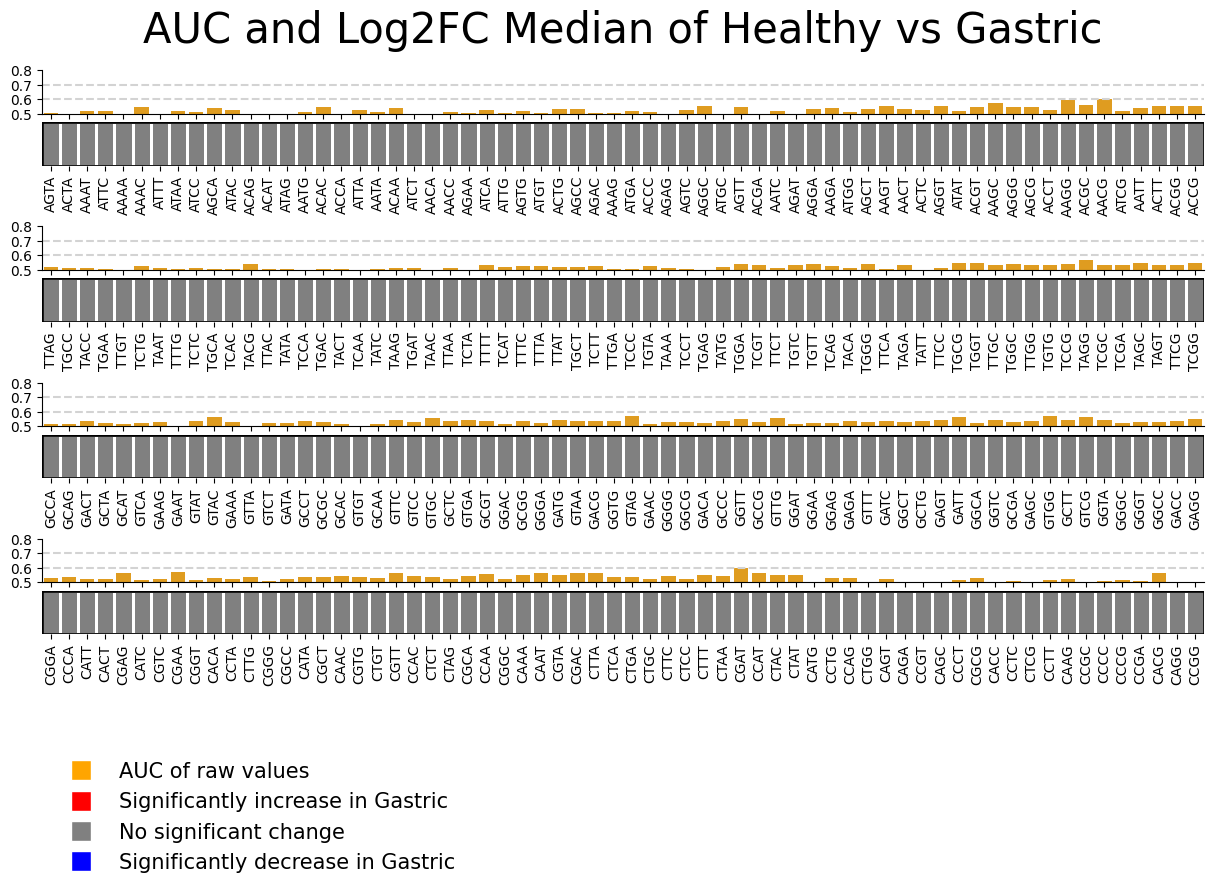

In [936]:
# data=result.sort_values(by=['nu_start','PlusMinus_Log2FC_'+p.split('-')[0]+'_'+p.split('-')[1],'ABS_Log2FC_'+p.split('-')[0]+'_'+p.split('-')[1]],ascending=True)
data=result.sort_values(by=['nu_start_order','Sig','Log2FC_+-','ABS Log2FC Median of '+p,],ascending=True)
# data=result
# cols=['Mean_F_Healthy','Mean_M_Healthy']
lst_PDAJ=list(data[data['PADJ of '+p.split(' vs ')[0]+' vs '+p.split(' vs ')[1]]<0.05]['FEATURES'])
set1=lst_PDAJ
# for n in [1,2,3,4,5,6,7,8]:
fig, axs = plt.subplots(12, 1, figsize=(15, 8))

for n in [1,2,3,4]:
        # A=data[cols][32*(n-1):32*n].T
        # A=data[['Mean of '+p.split(' vs ')[0],'Mean of '+p.split(' vs ')[1]]][64*(n-1):64*n].T
        # cmap = matplotlib.colormaps["Greens"]
        #         # Set the under color to white
        #         # cmap.set_under("yellow")
        #         # # Set the voer color to white
        #         # cmap.set_over("black")
        # # Set the background color
        # plt.figure(figsize=(15,1))
        # g = sb.heatmap(A,
        #                 # vmin=0,
        #                 # vmax=0.0125,
        #                 cmap=cmap,
        #                 # mask=mask_array,
        #                 yticklabels=True,
        #                 linewidths=2)
        # Set color of masked region
        # g.set_facecolor('gray')
        # if n==1: plt.title(col)
        # plt.title(col)

        lst_out=[]
        for i in list(np.arange(64*(n-1),64*n)):
                # if data['FEATURES'].iloc[i] not in lst_PDAJ:
                if data['FEATURES'].iloc[i] not in set(stats_fea['EM'][stats_fea['EM']['PADJ of '+p]<0.05]['FEATURES']):
                        lst_out+=[i-64*(n-1)]


        col = 'Log2FC Median of '+p.split(' vs ')[0]+' vs '+p.split(' vs ')[1]




        B = data[[col]][64*(n-1):64*n].T
        B.index=[B.columns[0][0]]
        mask_array = np.zeros((1, 64), dtype=bool)
        mask_array[:, lst_out] = True
        cmap = matplotlib.colormaps["seismic"]
        # Set the under color to white
        # cmap.set_under("yellow")
        # # Set the voer color to white
        # cmap.set_over("black")
        # Set the background color
        # plt.figure(figsize=(15,0.7))
        # cbar=True if n==1 else False
        g = sb.heatmap(B,
                        # vmin=-max([abs(min(data[col])),abs(max(data[col]))]),
                        # vmax=max([abs(min(data[col])),abs(max(data[col]))]),
                        vmin=-0.16,
                        vmax=0.16,
                        cmap=cmap,
                        mask=mask_array,
                        yticklabels=False,
                        linewidths=2,
                        # linecolor='black',
                        cbar=False,
                        # cbar_kws={'shrink': 1, 'fraction': 0.5, 'pad': 0.03},
                        # ax=axs[n-1])
                        # ax=axs[2*n-1])
                        ax=axs[(n-1)*3+1])
        # Set color of masked region
        g.set_facecolor('gray')
        # plt.title(col)ax.axhline(y=0, color='k',linewidth=10)
        g.axhline(y=0, color='k',linewidth=2)
        g.axhline(y=1, color='k',linewidth=2)
        g.axvline(x=0, color='k',linewidth=2)
        g.axvline(x=64, color='k',linewidth=2)
        for labe in g.get_xticklabels():
                text = 'EM_'+labe.get_text()
                #if text in overlap012:
                #        labe.set_color('magenta')
                #elif text in overlap01:
                #        labe.set_color('g')



        g1=sb.barplot(data=data[['FEATURES','AUCADJ of '+p]][64*(n-1):64*n],x='FEATURES',y='AUCADJ of '+p,
                #       ax=axs[2*n-2],
                      ax=axs[(n-1)*3],
                      palette=['orange'])
        g1.axhline(y=0.6,ls='--',color='lightgray')
        g1.axhline(y=0.7,ls='--',color='lightgray')
        g1.spines['top'].set_visible(False)
        g1.spines['right'].set_visible(False)
        g1.tick_params(axis='x', labelrotation=90,labelbottom=False)
        g1.set_xlabel('')
        g1.set_ylabel('')
        g1.set_yticks([0.5,0.6,0.7,0.8])
        # sb.despine(left=True)
        g1.set_xlim(left=-0.5)
        g1.set_ylim([0.5,0.8])

        if n==1: g1.set_title('AUC and '+col,pad=20,fontsize=30)

        axs[(n-1)*3+2].axis('off')
plt.tight_layout()
custom_lines = [Line2D([0], [0],marker='s', color='w', markerfacecolor='orange', markersize=15),
        Line2D([0], [0],marker='s', color='w', markerfacecolor='r', markersize=15),
                Line2D([0], [0],marker='s', color='w', markerfacecolor='gray', markersize=15),
                    Line2D([0], [0],marker='s', color='w', markerfacecolor='b', markersize=15),
                    ]
plt.legend(custom_lines,['AUC of raw values','Significantly increase in '+p.split(' vs ')[1],'No significant change','Significantly decrease in '+p.split(' vs ')[1]],loc='upper left',fontsize=15, bbox_to_anchor=(0, -1.3),frameon=False)
# plt.savefig('.\Figure\EM.png', dpi=600, bbox_inches='tight')
plt.subplots_adjust(hspace=0.2)

EM top sig

In [937]:
#stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True).head(5)[['PADJ of '+PAIR[0],'PADJ of '+PAIR[1],'PADJ of '+PAIR[2]]]
stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True).head(5)[['PADJ of '+PAIR[0]]]

,PADJ of Healthy vs Gastric
0,0.966759
1,0.966759
2,0.966759
3,0.966759
4,0.966759


In [938]:
stats_fea['EM'].sort_values(by='Log2FC Median of '+p,ascending=False).reset_index(drop=True)

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,EM_TCGG,0.000098,0.000101,0.000095,0.000100,0.000021,0.000020,22.004855,19.582610,3.452631,...,0.043659,0.062816,0.237524,0.966759,0.00,0.00,0.014682,0.000003,0.546296,0.546296
1,EM_GAGG,0.002354,0.002394,0.002353,0.002417,0.000213,0.000198,9.026775,8.266956,3.423095,...,0.024195,0.038718,0.188728,0.966759,0.00,0.00,0.014682,0.000040,0.551515,0.551515
2,EM_TTCG,0.000115,0.000116,0.000113,0.000115,0.000018,0.000016,15.385672,14.118408,3.360285,...,0.014188,0.036058,0.416287,0.966759,0.00,0.00,0.014682,0.000001,0.531860,0.531860
3,EM_ACCG,0.000643,0.000656,0.000631,0.000646,0.000083,0.000110,12.988094,16.821772,2.990842,...,0.030466,0.033750,0.162080,0.966759,0.00,0.00,0.014682,0.000014,0.554798,0.554798
4,EM_TAGT,0.002008,0.002039,0.002006,0.002052,0.000212,0.000199,10.576056,9.776603,3.490602,...,0.022612,0.032716,0.380902,0.966759,0.00,0.00,0.014682,0.000032,0.534343,0.534343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,EM_TTTC,0.002392,0.002384,0.002423,0.002386,0.000234,0.000213,9.760968,8.941065,3.452104,...,-0.005206,-0.022140,0.550479,0.966759,0.00,0.00,0.014682,-0.000009,0.476599,0.523401
252,EM_CTAC,0.003496,0.003417,0.003429,0.003376,0.000390,0.000350,11.165748,10.253164,3.333557,...,-0.033285,-0.022262,0.189451,0.966759,0.00,0.00,0.014682,-0.000080,0.448569,0.551431
253,EM_TTTA,0.003298,0.003271,0.003331,0.003277,0.000426,0.000377,12.906861,11.524469,3.627502,...,-0.011817,-0.023653,0.497358,0.966759,0.00,0.00,0.014682,-0.000027,0.473401,0.526599
254,EM_TTAT,0.002616,0.002585,0.002632,0.002589,0.000390,0.000320,14.918564,12.373299,3.245237,...,-0.016833,-0.023807,0.670668,0.966759,0.00,0.00,0.014682,-0.000030,0.483333,0.516667


In [939]:
EM_top=list(stats_fea['EM'].sort_values(by='Log2FC Median of '+p).reset_index(drop=True)['FEATURES'][0:5])+list(stats_fea['EM'].sort_values(by='Log2FC Median of '+p,ascending=False).reset_index(drop=True)['FEATURES'][0:5])
EM_top

['EM_CTAT',
 'EM_TTAT',
 'EM_TTTA',
 'EM_CTAC',
 'EM_TTTC',
 'EM_TCGG',
 'EM_GAGG',
 'EM_TTCG',
 'EM_ACCG',
 'EM_TAGT']

In [940]:
f='EM'
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list[sample_list['SampleID']==s]['Label'])[0]]
data.insert(loc=1,column='Label',value=labels)
data.sort_values(by='SampleID',inplace=True)
data.reset_index(drop=True,inplace=True)
EM_plot1=data[['Label']+EM_top[0:5]].melt(id_vars="Label")
EM_plot1['x']=EM_plot1.apply(lambda r: r['variable'][3:]+'_'+str(int(r['Label'])),axis=1)
EM_plot1.sort_values(by='x',inplace=True)
EM_plot1

C:\Users\XN\AppData\Local\Temp\ipykernel_24948\4088704475.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='SampleID',inplace=True)


,Label,variable,value,x
654,0.0,EM_CTAC,0.003535,CTAC_0
734,0.0,EM_CTAC,0.003284,CTAC_0
733,0.0,EM_CTAC,0.003265,CTAC_0
732,0.0,EM_CTAC,0.004001,CTAC_0
731,0.0,EM_CTAC,0.003252,CTAC_0
...,...,...,...,...
1011,1.0,EM_TTTC,0.002542,TTTC_1
1010,1.0,EM_TTTC,0.002452,TTTC_1
1009,1.0,EM_TTTC,0.002212,TTTC_1
1020,1.0,EM_TTTC,0.002235,TTTC_1


In [941]:
EM_plot2=data[['Label']+EM_top[5:10]].melt(id_vars="Label")
EM_plot2

,Label,variable,value
0,0.0,EM_TCGG,0.000063
1,0.0,EM_TCGG,0.000089
2,0.0,EM_TCGG,0.000100
3,0.0,EM_TCGG,0.000135
4,0.0,EM_TCGG,0.000102
...,...,...,...
1085,1.0,EM_TAGT,0.002193
1086,1.0,EM_TAGT,0.001972
1087,1.0,EM_TAGT,0.001795
1088,1.0,EM_TAGT,0.001671


Text(-1.1, -0.0065, '**  p-value < 0.05')

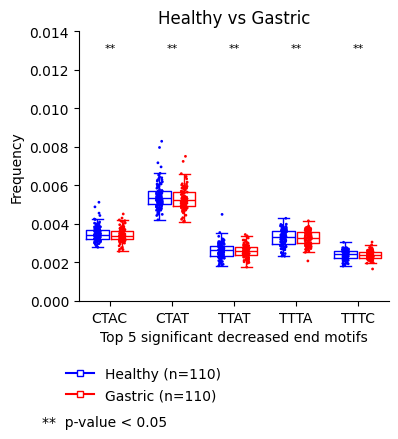

In [942]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot1,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,legend=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot1,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,legend=False,
             dodge=True
             )
plt.yticks(np.arange(0,0.016,0.002))
plt.ylim(0,0.014)
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot1['variable'].unique())])
plt.ylabel('Frequency')
plt.xlabel('Top 5 significant decreased end motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p-value < 0.00001','Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.3, .8),loc='center right',frameon=False)
# plt.legend(custom_lines,['Control (n=168)','Lung cancer (n=99)'],bbox_to_anchor=(1.05, .1),loc='center right',frameon=False)
tys=[p.split(' vs ')[0]+' (n='+str(len(SAMPLES[p.split(' vs ')[0]]))+')',
     p.split(' vs ')[1]+' (n='+str(len(SAMPLES[p.split(' vs ')[1]]))+')']
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
plt.title(p)
plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')
# plt.text(x=4.7,y=0.007,s='**',fontsize=8)
# plt.savefig('.\Figure/EM_top5_1.png',dpi=600,bbox_inches='tight')

Text(-1.1, -0.0065, '**  p-value < 0.05')

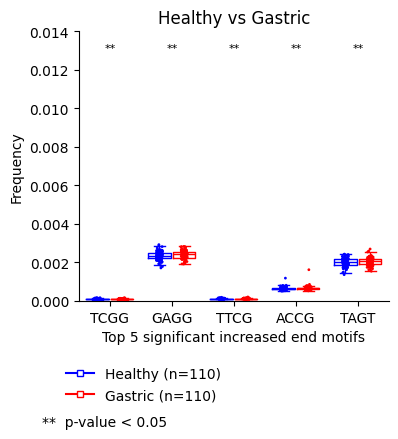

In [943]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,
             dodge=True
             )
plt.yticks(np.arange(0,0.016,0.002))
plt.ylim(0,0.014)
plt.xticks(ticks=[0,1,2,3,4],labels=[em.split('_')[1] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Frequency')
plt.xlabel('Top 5 significant increased end motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
tys=[p.split(' vs ')[0]+' (n='+str(len(SAMPLES[p.split(' vs ')[0]]))+')',
     p.split(' vs ')[1]+' (n='+str(len(SAMPLES[p.split(' vs ')[1]]))+')']
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
plt.title(p)
plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')

In [944]:
EM_plot2=data[['Label']+['EM_AAGG']].melt(id_vars="Label")
EM_plot2

,Label,variable,value
0,0.0,EM_AAGG,0.002242
1,0.0,EM_AAGG,0.002310
2,0.0,EM_AAGG,0.002393
3,0.0,EM_AAGG,0.002427
4,0.0,EM_AAGG,0.002349
...,...,...,...
213,1.0,EM_AAGG,0.002446
214,1.0,EM_AAGG,0.002214
215,1.0,EM_AAGG,0.002318
216,1.0,EM_AAGG,0.002205


Text(0.5, 1.0, 'Healthy vs Gastric')

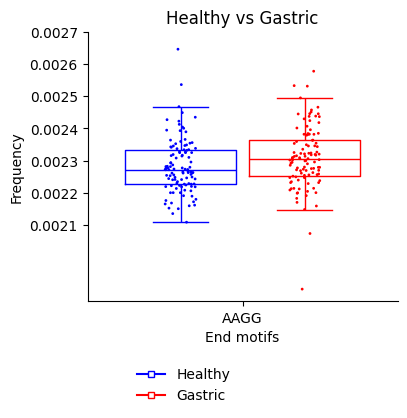

In [945]:
plt.figure(figsize=(4,3.5))
sb.boxplot(data=EM_plot2,y='value',x='variable',hue='Label',
           palette=['b','r'],hue_order=[0,1],fill=False,linewidth=1,
           flierprops=dict(marker='.',markersize=3),
           showfliers=False,
           dodge=True,width=0.8,gap=0.1)
sb.stripplot(data=EM_plot2,y='value',x='variable',hue='Label',
             palette=['b','r'],hue_order=[0,1],
             marker='.',size=4,linewidth=0,
             dodge=True
             )
plt.yticks(np.arange(0.0021,0.0027,0.0001))
# plt.ylim(0,0.014)
plt.xticks(ticks=[0,
               #    1,2,3,4
                  ],labels=[em.split('_')[1] for em in list(EM_plot2['variable'].unique())])
plt.ylabel('Frequency')
# plt.xlabel('Top 5 significant increased end motifs')
plt.xlabel('End motifs')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
custom_lines = [
                    # Line2D([0], [0], color='w', lw=0, marker='*', markersize=00),
                    Line2D([0], [0],marker='s', color='b', markerfacecolor='w', markersize=5),     
                    Line2D([0], [0],marker='s', color='r', markerfacecolor='w', markersize=5),
                    ]
# plt.legend(custom_lines,['p_value < 0.00001','Healthy','Lung'],bbox_to_anchor=(1, .8),frameon=False)
# plt.legend(custom_lines,['Control \n(n=168)','Lung cancer \n(n=99)'],bbox_to_anchor=(1.45, .8),loc='center right',frameon=False)
tys=[p.split(' vs ')[0],
     p.split(' vs ')[1]]
plt.legend(custom_lines,tys,frameon=False,loc='upper right', bbox_to_anchor=(0.5, -0.2))
# plt.text(x=0,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=1,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=2,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=3,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4,y=0.013,s='**',ha='center',fontsize=8)
# plt.text(x=4.7,y=0.0021,s='*****',fontsize=8)
# plt.savefig('.\Figure/EM_top5_2.png',dpi=600,bbox_inches='tight')
plt.title(p)
# plt.text(x=-1.1,y=-0.0065,s='**  p-value < 0.05')

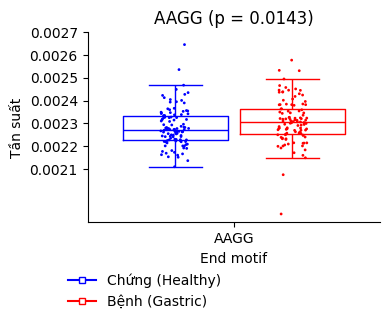

✅ Kết quả thống kê tần suất EM_AAGG:
Healthy  : Mean = 0.002284, 95% CI = [0.002268, 0.002300]
Gastric  : Mean = 0.002309, 95% CI = [0.002291, 0.002327]
📌 p-value (Mann–Whitney U test) = 0.01431


In [946]:
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib.lines import Line2D

# Hàm tính trung bình và khoảng tin cậy 95% (bootstrap)
def mean_ci(values, n_boot=1000, ci=0.95):
    means = []
    np.random.seed(42)
    for _ in range(n_boot):
        sample = np.random.choice(values, size=len(values), replace=True)
        means.append(np.mean(sample))
    lower = np.percentile(means, (1 - ci) / 2 * 100)
    upper = np.percentile(means, (1 + ci) / 2 * 100)
    return np.mean(values), (lower, upper)

# 👉 1. Lọc dữ liệu cho motif AAGG
df_aagg = EM_plot2[EM_plot2['variable'].str.contains("AAGG")]

# 👉 2. Tách theo nhóm
healthy_vals = df_aagg[df_aagg["Label"] == 0]["value"]
gastric_vals = df_aagg[df_aagg["Label"] == 1]["value"]

# 👉 3. Tính trung bình và 95%CI mỗi nhóm
mean_h, ci_h = mean_ci(healthy_vals)
mean_g, ci_g = mean_ci(gastric_vals)

# 👉 4. Kiểm định Mann–Whitney
stat, p_val = mannwhitneyu(healthy_vals, gastric_vals, alternative='two-sided')

# 👉 5. Vẽ biểu đồ
plt.figure(figsize=(4, 3.5))
sb.boxplot(data=df_aagg, y='value', x='variable', hue='Label',
           palette=['b', 'r'], hue_order=[0, 1], fill=False, linewidth=1,
           flierprops=dict(marker='.', markersize=3),
           showfliers=False, dodge=True, width=0.8, gap=0.1)
sb.stripplot(data=df_aagg, y='value', x='variable', hue='Label',
             palette=['b', 'r'], hue_order=[0, 1],
             marker='.', size=4, linewidth=0, dodge=True)

plt.yticks(np.arange(0.0021, 0.0027, 0.0001))
plt.xticks(ticks=[0], labels=[em.split('_')[1] for em in df_aagg['variable'].unique()])
plt.ylabel('Tần suất')
plt.xlabel('End motif')
plt.title(f"AAGG (p = {p_val:.4f})")
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 👉 6. Thêm chú thích nhóm
custom_lines = [
    Line2D([0], [0], marker='s', color='b', markerfacecolor='w', markersize=5),
    Line2D([0], [0], marker='s', color='r', markerfacecolor='w', markersize=5),
]
tys = ['Chứng (Healthy)', 'Bệnh (Gastric)']
plt.legend(custom_lines, tys, frameon=False, loc='upper right', bbox_to_anchor=(0.5, -0.2))

# 👉 7. Hiển thị dấu sao nếu có ý nghĩa
if p_val < 0.05:
    plt.text(x=0, y=max(df_aagg['value']) + 0.00002, s='', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 👉 8. In ra kết quả thống kê
print("✅ Kết quả thống kê tần suất EM_AAGG:")
print(f"Healthy  : Mean = {mean_h:.6f}, 95% CI = [{ci_h[0]:.6f}, {ci_h[1]:.6f}]")
print(f"Gastric  : Mean = {mean_g:.6f}, 95% CI = [{ci_g[0]:.6f}, {ci_g[1]:.6f}]")
print(f"📌 p-value (Mann–Whitney U test) = {p_val:.4g}")


In [947]:
# for

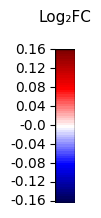

In [948]:
a=0.16
step1=0.005
Cbar=pd.DataFrame({u'log\u2082(fold change)':np.arange(a,-(a+step1),-step1)})
Cbar.index=[round(x,2) for x in Cbar[u'log\u2082(fold change)']]
plt.figure(figsize=(0.25,2))
Cbar_g=sb.heatmap(Cbar,
           cbar=False,
           cmap = matplotlib.colormaps["seismic"],
           xticklabels=False,
           )
labels=[round(i,2) for i in np.arange(a,-(a+0.04),-0.04)]
step=(len(Cbar)-1)/(len(labels)-1)
ticks=list(np.arange(0,len(Cbar),step))
plt.yticks(ticks=ticks,labels=labels)
plt.title(u'Log\u2082FC',pad=20,fontsize=11)
Cbar_g.axhline(y=0, color='k',linewidth=1)
Cbar_g.axhline(y=len(Cbar), color='k',linewidth=1)
Cbar_g.axvline(x=0, color='k',linewidth=1)
Cbar_g.axvline(x=1, color='k',linewidth=1)

FLEN distribution

In [949]:
f='FLEN'

In [950]:
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

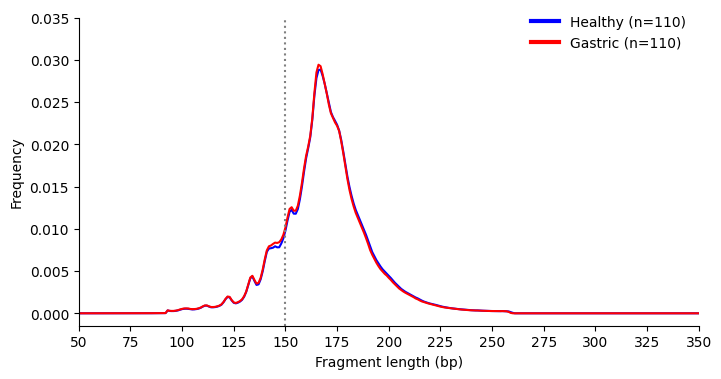

In [951]:
G={
    'Healthy':'b',
    #'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[]
# x=np.arange(100,251,1)
x=np.arange(50,351,1)

for g in list(G.keys()):
    y1=stats_fea['FLEN']['Median of '+g]
    sb.lineplot(x=x,y=y1,color=G[g],lw=1.5)
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
tys=['Healthy (n='+str(len(SAMPLES['Healthy']))+')',
    # 'Gastric_benign (n='+str(len(SAMPLES['Gastric_benign']))+')',
     'Gastric (n='+str(len(SAMPLES['Gastric']))+')']
plt.legend(custom_lines,tys,bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
# plt.xticks(np.arange(100,275,25))
plt.xlim(50,350)
plt.xticks(np.arange(50,375,25))
plt.yticks(np.arange(0,0.04,0.005))
# plt.title('Fragment length distribution')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.savefig('.\Figure/FLEN_50-350_distribution.png', dpi=600, bbox_inches='tight')
plt.grid(False)


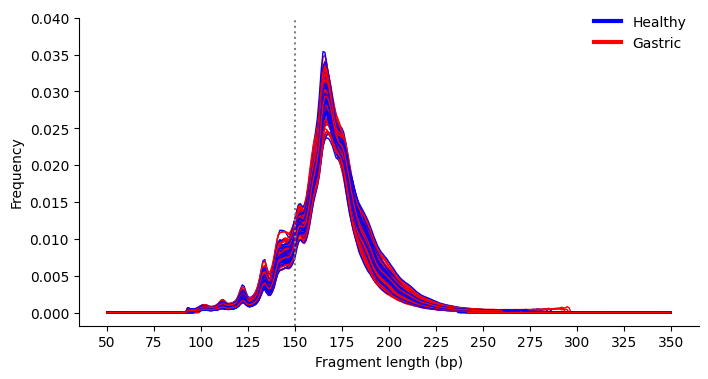

In [952]:
G2={
    'Healthy':'blue',
#    'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
#              Line2D([0], [0], color='g', lw=3),
              Line2D([0], [0], color='r', lw=3)]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)
data.reset_index(drop=True,inplace=True)

x=np.arange(50,351,1)
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,2:]
    sb.lineplot(x=x,y=y2,color=G2[g],lw=1)
#plt.legend(custom_lines,['Healthy','Gastric_benign','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.legend(custom_lines,['Healthy','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Healthy'],color='r',lw=2)
# plt.title(fea['FLEN100']['SampleID'][r])
plt.yticks(np.arange(0,0.045,0.005))
plt.xticks(np.arange(50,375,25))
plt.grid(False)

In [953]:
#df=pd.DataFrame(data[data['Type']=='Healthy'])[['SampleID','FLEN_200']].sort_values(by='FLEN_200')
#df


In [954]:
#special_sample='KGDAAA09'
#G2={
#    'Healthy':'blue',
#    'Gastric_benign':'g',
#    'Gastric':'r'
#    }
#plt.figure(figsize=(8,4))
#custom_lines=[Line2D([0], [0], color='b', lw=3),
#              Line2D([0], [0], color='g', lw=3),
#              Line2D([0], [0], color='r', lw=3)]
#vector=[]
#for s in list(DATA[f]['SampleID']):
#    if s in list(sample_list_all['SampleID']):
#        vector+=[True]
#    else:
#        vector+=[False]
#data=DATA[f][vector]
#labels=[]
#for s in list(data['SampleID']):
#    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
#data.insert(loc=1,column='Type',value=labels)
#data.sort_values(by='Type',ascending=False)
#data.reset_index(drop=True,inplace=True)

#x=np.arange(50,351,1)
#for i in range(len(data)):
#    g=data['Type'][i]
#    y2=data.iloc[i,2:]
#    if data['SampleID'][i]==special_sample:
#        sb.lineplot(x=x,y=y2,color=G2[g],lw=1)
#plt.legend(custom_lines,['Healthy','Gastric_benign','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
#plt.ylabel('Frequency')
#plt.xlabel('Fragment length (bp)')
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)
#plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['FLEN100']['Mean of Healthy'],color='r',lw=2)
#plt.title(special_sample)
#plt.yticks(np.arange(0,0.045,0.005))
#plt.xticks(np.arange(50,375,25))

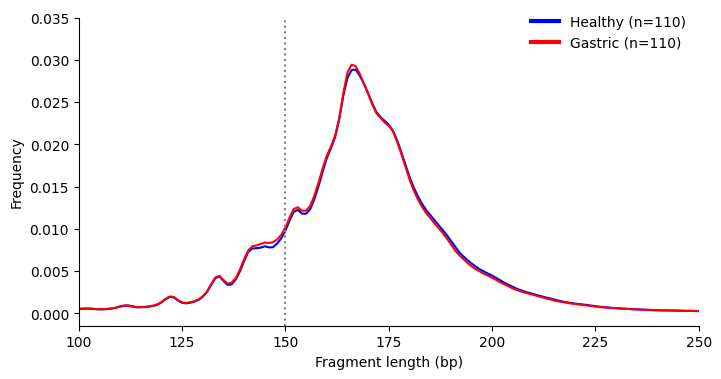

In [955]:
G={
    'Healthy':'b',
#    'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(8,4))
custom_lines=[]
# x=np.arange(100,251,1)
x=np.arange(50,351,1)

for g in list(G.keys()):
    y1=stats_fea['FLEN']['Median of '+g]
    sb.lineplot(x=x,y=y1,color=G[g],lw=1.5)
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.axvline(x=150, color='gray', label='axvline - full height',ls=':')
tys=['Healthy (n='+str(len(SAMPLES['Healthy']))+')',
#     'Gastric_benign (n='+str(len(SAMPLES['Gastric_benign']))+')',
     'Gastric (n='+str(len(SAMPLES['Gastric']))+')']
plt.legend(custom_lines,tys,bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.xlabel('Fragment length (bp)')
# plt.xticks(np.arange(100,275,25))
plt.xticks(np.arange(50,375,25))
plt.xlim(100,250)
plt.yticks(np.arange(0,0.04,0.005))
# plt.title('Fragment length distribution')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.savefig('.\Figure/FLEN_50-350_distribution.png', dpi=600, bbox_inches='tight')
plt.grid(False)

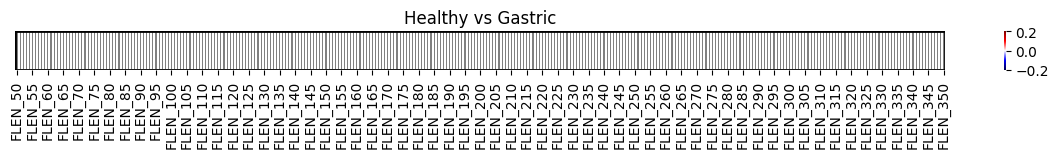

In [956]:
for p in PAIR:
    df=stats_fea['FLEN']
    set_Overlap=df[df['PADJ of '+p]<=0.05]['FEATURES']
    # df.index=df.apply(lambda row: row['FEATURES'].split('_')[1],axis=1)
    df.index=df.apply(lambda row: row['FEATURES'],axis=1)
    lst_in_out=[]
    for i in range(len(df['FEATURES'])):
        if df['FEATURES'].iloc[i] not in list(set_Overlap):
            lst_in_out+=[i]
    len(lst_in_out)

    A = df[['Log2FC Median of '+p]].T
    mask_array = np.zeros((1, df.shape[0]), dtype=bool)
    mask_array[:, lst_in_out] = True
    cmap = matplotlib.colormaps["seismic"]
    # Set the under color to white
    # cmap.set_under("yellow")
    # # Set the voer color to white
    # cmap.set_over("black")
    # Set the background color
    plt.figure(figsize=(15,0.5))
    g = sb.heatmap(A,
                    # vmin=-max([abs(min(df[col])),abs(max(df[col]))]),
                    # vmax=max([abs(min(df[col])),abs(max(df[col]))]),
                   vmin=-0.2,vmax=0.2,
                   cmap=cmap, mask=mask_array,yticklabels=False,
                   cbar=True,linewidths=0.003,linecolor='w',
                #    cbar_kws={'label': u'log\u2082(fold change)'}
                )
    # Set color of masked region
    g.set_facecolor('gray')
    g.axhline(y=0, color='k',linewidth=2)
    g.axhline(y=1, color='k',linewidth=2)
    g.axvline(x=0, color='k',linewidth=2)
    g.axvline(x=301, color='k',linewidth=2)
    g.set_title(p)
    # colorbar = g.collections[0].colorbar
    # colorbar.set_label('Colorbar Title', fontsize=12, labelpad=10)
    # colorbar.ax.invert_yaxis()
    # colorbar.set_label(u'log\u2082(fold change)', fontsize=12, rotation=0)
    # plt.title(p)
    # plt.savefig('.\Figure/FLEN_50-350_heatmap.png', dpi=600, bbox_inches='tight')

In [957]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from matplotlib.colors import TwoSlopeNorm

# Đọc dữ liệu
flen_df = pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\FLEN.csv")
meta_df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\Metadata.xlsx", sheet_name="QC", nrows=1000)

# Ghép bảng theo SampleID
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')

# Xác định cột fragment lengths từ 50 đến 350
flen_cols = [str(i) for i in range(50, 351)]



In [958]:
# Re-import necessary libraries after code execution state reset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from matplotlib.colors import TwoSlopeNorm

# Re-load the files after reset
flen_df = pd.read_csv(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\FLEN.csv")
meta_df = pd.read_excel(r"C:\Users\XN\du-an-dung-chung\HNG_5_GW + 450 region_20260302\WG\Metadata.xlsx", sheet_name="QC", nrows=1000)

# Merge on SampleID
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')

# Determine fragment length columns
flen_cols = [str(i) for i in range(50, 351)]

# Filter necessary columns for "Kích thước khối u"
merged_df = merged_df[['SampleID', 'Kích thước khối u'] + flen_cols].dropna()
merged_df = merged_df.rename(columns={'Kích thước khối u': 'TumorSize'})

# Remove rows with '-' value in TumorSize
merged_df = merged_df[merged_df['TumorSize'] != '-']

# Melt data from wide to long format
flen_long = merged_df.melt(id_vars=['SampleID', 'TumorSize'], value_vars=flen_cols,
                           var_name='Length', value_name='Count')
flen_long['Length'] = flen_long['Length'].astype(int)

# Normalize by total per sample
flen_long['Total'] = flen_long.groupby('SampleID')['Count'].transform('sum')
flen_long['Freq'] = flen_long['Count'] / flen_long['Total']

# Calculate mean frequency by TumorSize and Length
grouped = flen_long.groupby(['TumorSize', 'Length'])['Freq'].mean().reset_index()

# Line plot
plt.figure(figsize=(10, 5))
sns.set(style='whitegrid')
palette = sns.color_palette(['#e41a1c', '#377eb8'])

for idx, (group, group_data) in enumerate(grouped.groupby('TumorSize')):
    plt.plot(group_data['Length'], group_data['Freq'], label=group, linewidth=2.5, color=palette[idx % len(palette)])

plt.axvline(x=150, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Fragment length (bp)')
plt.ylabel('Frequency')
plt.title('Fragment Length Distribution by Tumor Size')
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap of log2FC with larger font and Arial
fig, ax = plt.subplots(figsize=(14, 2.5))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
norm = TwoSlopeNorm(vmin=-0.2, vcenter=0, vmax=0.2)

# Đặt font mặc định là Arial
plt.rcParams['font.family'] = 'Arial'

# Vẽ các cột biểu diễn log2FC
for i, row in stat_df.iterrows():
    color = cmap(norm(row['log2FC']))
    ax.bar(i, 1, color=color, edgecolor='black', linewidth=0.2)

# Gán nhãn trục x với cỡ chữ lớn hơn
flen_labels = [f"FLEN_{l}" for l in stat_df['Length']]
ax.set_xticks(np.arange(len(flen_labels))[::10])
ax.set_xticklabels(flen_labels[::10], rotation=90, fontsize=14)
ax.set_yticks([])

# Tiêu đề biểu đồ heatmap với tên nhóm và cỡ lớn
ax.set_title(f"{ref_group} vs {test_group}", fontsize=16, fontname='Arial')

# Thanh màu (colorbar) với cỡ chữ lớn hơn
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('log2FC', fontsize=14)

# Tiêu đề tổng thể
plt.title('Fragment Length Distribution by Tumor Size (<=5cm vs >5cm)',
          fontsize=16, fontname='Arial')

plt.tight_layout()
plt.show()

KeyError: "['Kích thước khối u'] not in index"

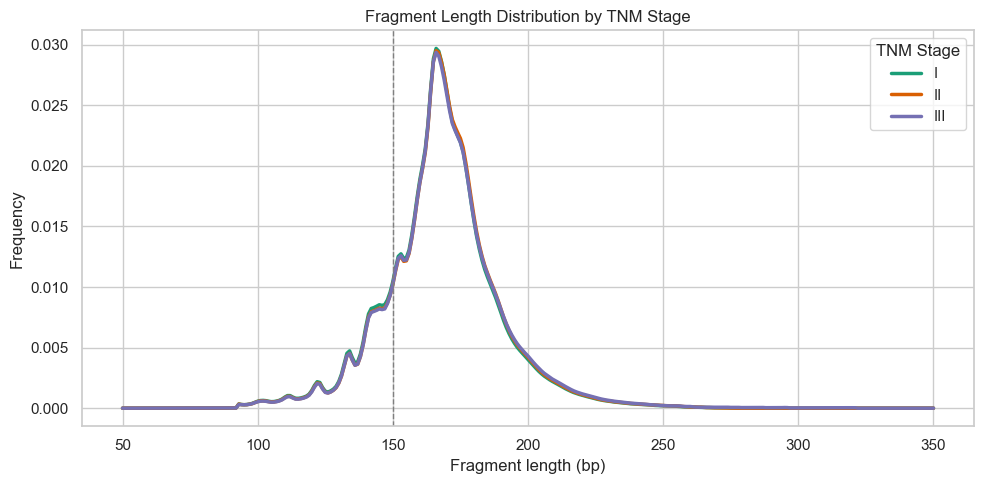

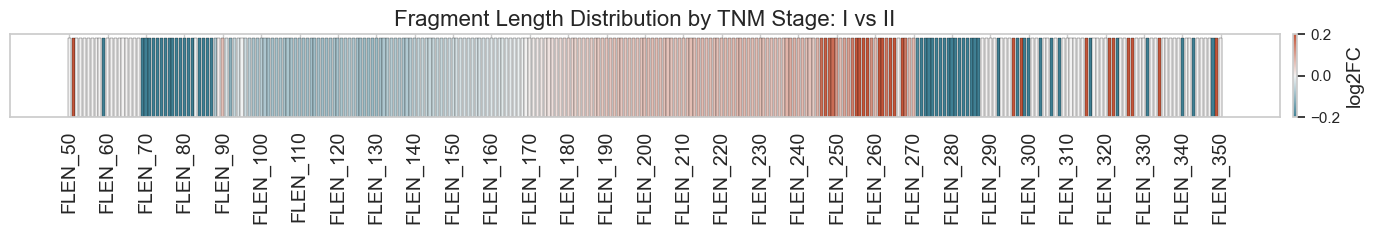

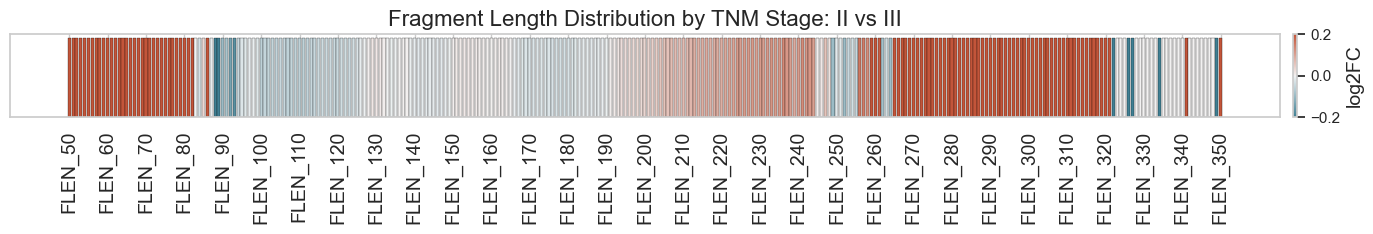

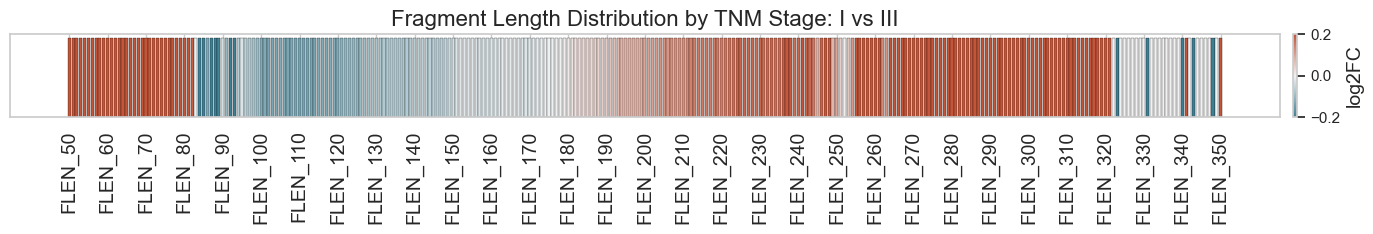

In [ ]:
import itertools

# Dữ liệu ban đầu giống như trước, chỉ thay thế cột phân nhóm
merged_df = pd.merge(flen_df, meta_df, on='SampleID', how='inner')
flen_cols = [str(i) for i in range(50, 351)]
merged_df = merged_df[['SampleID', 'Giai đoạn theo TNM'] + flen_cols].dropna()
merged_df = merged_df.rename(columns={'Giai đoạn theo TNM': 'TNMStage'})

# Loại bỏ giá trị không hợp lệ
merged_df = merged_df[merged_df['TNMStage'].isin(['I', 'II', 'III'])]

# Long format
flen_long = merged_df.melt(id_vars=['SampleID', 'TNMStage'], value_vars=flen_cols,
                           var_name='Length', value_name='Count')
flen_long['Length'] = flen_long['Length'].astype(int)
flen_long['Total'] = flen_long.groupby('SampleID')['Count'].transform('sum')
flen_long['Freq'] = flen_long['Count'] / flen_long['Total']

# Biểu đồ đường tổng quát theo TNM
grouped = flen_long.groupby(['TNMStage', 'Length'])['Freq'].mean().reset_index()

plt.figure(figsize=(10, 5))
palette = sns.color_palette(['#1b9e77', '#d95f02', '#7570b3'])
for idx, (stage, data) in enumerate(grouped.groupby('TNMStage')):
    plt.plot(data['Length'], data['Freq'], label=stage, linewidth=2.5, color=palette[idx])
plt.axvline(x=150, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Fragment length (bp)')
plt.ylabel('Frequency')
plt.title('Fragment Length Distribution by TNM Stage')
plt.legend(title="TNM Stage")
plt.tight_layout()
plt.show()

# Heatmap log2FC cho từng cặp: I vs II, II vs III, I vs III
pair_results = {}

# Cài đặt font mặc định là Arial
plt.rcParams['font.family'] = 'Arial'

for ref_stage, test_stage in [('I', 'II'), ('II', 'III'), ('I', 'III')]:
    # Pivot dữ liệu
    pivot_df = grouped[grouped['TNMStage'].isin([ref_stage, test_stage])] \
        .pivot(index='Length', columns='TNMStage', values='Freq').fillna(0)

    epsilon = 1e-9
    log2fc = np.log2((pivot_df[test_stage] + epsilon) / (pivot_df[ref_stage] + epsilon))

    p_values = []
    log2fc_values = []

    for length in range(50, 351):
        ref_vals = flen_long[(flen_long['TNMStage'] == ref_stage) & (flen_long['Length'] == length)]['Freq'].dropna()
        test_vals = flen_long[(flen_long['TNMStage'] == test_stage) & (flen_long['Length'] == length)]['Freq'].dropna()
        if len(ref_vals) > 0 and len(test_vals) > 0:
            stat, p = mannwhitneyu(test_vals, ref_vals, alternative='two-sided')
            lfc = np.log2((test_vals.mean() + epsilon) / (ref_vals.mean() + epsilon))
        else:
            p = np.nan
            lfc = 0
        p_values.append(p)
        log2fc_values.append(lfc)

    stat_df = pd.DataFrame({
        'Length': list(range(50, 351)),
        'log2FC': log2fc_values,
        'p-value': p_values
    })
    stat_df['Significance'] = ['p < 0.05' if p < 0.05 else 'n.s.' for p in stat_df['p-value']]
    pair_results[f"{ref_stage} vs {test_stage}"] = stat_df

    # Vẽ heatmap
    fig, ax = plt.subplots(figsize=(14, 2.5))
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    norm = TwoSlopeNorm(vmin=-0.2, vcenter=0, vmax=0.2)

    for i, row in stat_df.iterrows():
        color = cmap(norm(row['log2FC']))
        ax.bar(i, 1, color=color, edgecolor='black', linewidth=0.2)

    flen_labels = [f"FLEN_{l}" for l in stat_df['Length']]
    ax.set_xticks(np.arange(len(flen_labels))[::10])
    ax.set_xticklabels(flen_labels[::10], rotation=90, fontsize=14)
    ax.set_yticks([])

    # Tiêu đề biểu đồ heatmap với Arial và kích thước lớn
    ax.set_title(f"Fragment Length Distribution by TNM Stage: {ref_stage} vs {test_stage}", fontsize=16, fontname='Arial')

    # Thêm colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.01)
    cbar.set_label('log2FC', fontsize=14)

    plt.tight_layout()
    plt.show()


NFP distribution

In [959]:
f='NFP'

In [960]:
#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]>=0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]>=0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]>=0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nIncerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

#df=stats_fea[f]
#a=set(df[(df['PADJ of '+PAIR[0]]<0.05)&(df['Log2FC Median of '+PAIR[0]]<0)]['FEATURES'])
#b=set(df[(df['PADJ of '+PAIR[1]]<0.05)&(df['Log2FC Median of '+PAIR[1]]<0)]['FEATURES'])
#c=set(df[(df['PADJ of '+PAIR[2]]<0.05)&(df['Log2FC Median of '+PAIR[2]]<0)]['FEATURES'])
#plt.figure(figsize=(3,3))
#matplotlib_venn.venn3_unweighted([a,b,c],[PAIR[0],PAIR[1],PAIR[2]])
#plt.title(f+" \nDecerease in cancer")
#overlap01=list(a&b-c)
#overlap012=list(a&b&c)

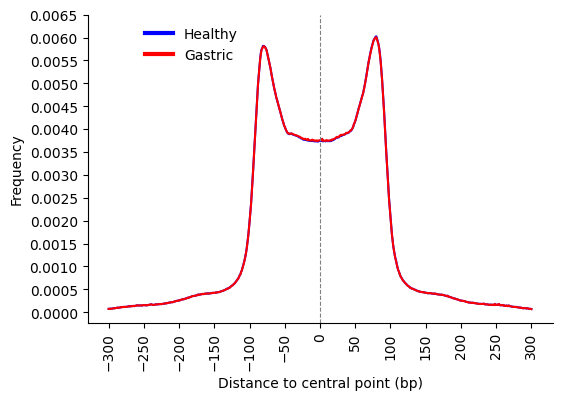

In [961]:
G={
    'Healthy':'b',
    #'Gastric_benign':'g',
    'Gastric':'r'
    }
plt.figure(figsize=(6,4))
custom_lines=[]
x=np.arange(-300,301,1)

for g in list(G.keys()):
    y1=stats_fea['NFP']['Median of '+g]
    ax=sb.lineplot(x=x,y=y1,color=G[g])
    custom_lines += [Line2D([0], [0], color=G[g], lw=3)]

plt.legend(custom_lines,G,bbox_to_anchor=(0.35, 1.),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.007,0.0005))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')

# plt.savefig('.\Figure/NFP_distribution.png', dpi=600, bbox_inches='tight')
plt.grid(False)

C:\Users\XN\AppData\Local\Temp\ipykernel_24948\3160854511.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='order',ascending=True,inplace=True)


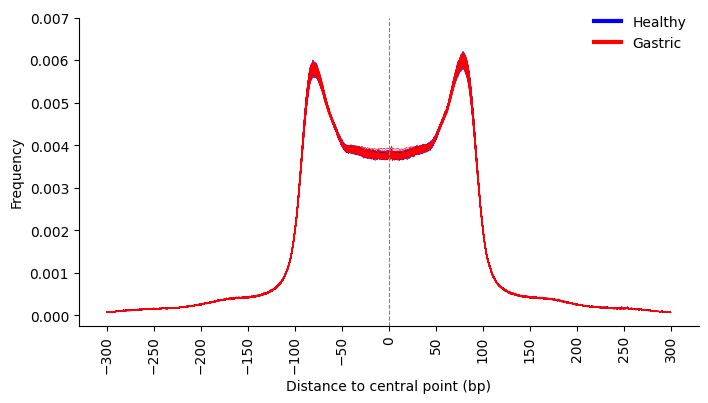

In [962]:
G2={
    'Healthy':'blue',
    'Gastric':'r',
    #'Gastric_benign':'g',   
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
              Line2D([0], [0], color='r', lw=3),
              Line2D([0], [0], color='g', lw=3)
              ]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)

order=[]
for s in list(data['SampleID']):
    if list(data[data['SampleID']==s]['Type'])[0]=='Healthy':
        order+=[0]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric':
        order+=[1]
    #elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric_benign':
    #    order+=[2]
data.insert(loc=1,column='order',value=order)
data.sort_values(by='order',ascending=True,inplace=True)          
data.reset_index(drop=True,inplace=True)

x=np.arange(-300,301,1)

# for g in list(G.keys()):
#     y1=stats_fea['NFP']['Mean of '+g]
#     ax=sb.lineplot(x=x,y=y1,color=G[g],lw=2)
#     custom_lines += [Line2D([0], [0], color=G[g], lw=3)]
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,3:]
    sb.lineplot(x=x,y=y2,color=G2[g],lw=0.5)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Healthy'],color='r',lw=2)

#plt.legend(custom_lines,['Healthy','Gastric','Gastric_benign'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.legend(custom_lines,['Healthy','Gastric'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.008,0.001))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# square=patches.Rectangle((0.003, 0.003), 0.006, 0.006, edgecolor='orange', facecolor='none')
# ax.add_patch(square)
# plt.title('Nucleosome footprint partern')
# plt.savefig('.\Figure/NFP_distribution_all.png', dpi=600, bbox_inches='tight')

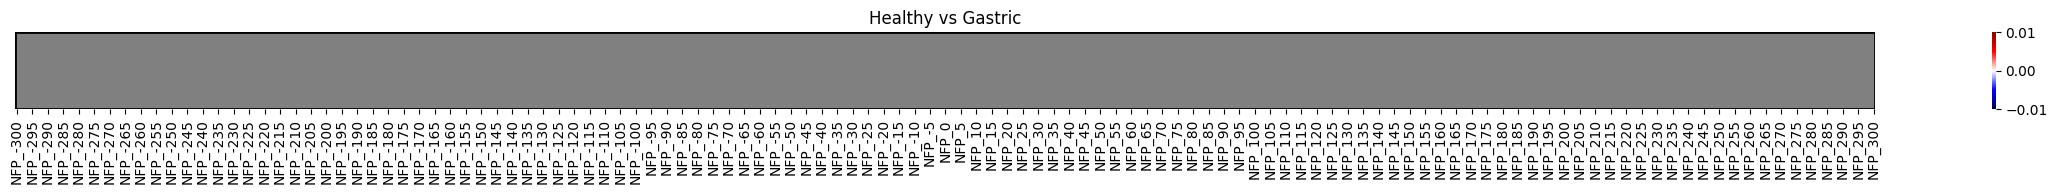

In [963]:
for p in PAIR:
    df=stats_fea['NFP']
    set_Overlap=df[df['PADJ of '+p]<=0.05]['FEATURES']
    # df.index=df.apply(lambda row: row['FEATURES'].split('_')[1],axis=1)
    df.index=df.apply(lambda row: row['FEATURES'],axis=1)
    lst_in_out=[]
    for i in range(len(df['FEATURES'])):
        if df['FEATURES'].iloc[i] not in list(set_Overlap):
            lst_in_out+=[i]
    len(lst_in_out)

    A = df[['Log2FC Median of '+p]].T
    mask_array = np.zeros((1, df.shape[0]), dtype=bool)
    mask_array[:, lst_in_out] = True
    cmap = matplotlib.colormaps["seismic"]
    # Set the under color to white
    # cmap.set_under("yellow")
    # # Set the voer color to white
    # cmap.set_over("black")
    # Set the background color
    plt.figure(figsize=(30,1))
    g = sb.heatmap(A,
                    # vmin=-max([abs(min(df[col])),abs(max(df[col]))]),
                    # vmax=max([abs(min(df[col])),abs(max(df[col]))]),
                   vmin=-0.01,vmax=0.01,
                   cmap=cmap, mask=mask_array,yticklabels=False,
                   cbar=True,linewidths=0.00,linecolor='w',
                #    cbar_kws={'label': u'log\u2082(fold change)'}
                )
    # Set color of masked region
    g.set_facecolor('gray')
    g.axhline(y=0, color='k',linewidth=2)
    g.axhline(y=1, color='k',linewidth=2)
    g.axvline(x=0, color='k',linewidth=2)
    g.axvline(x=601, color='k',linewidth=2)
    g.set_title(p)
    # colorbar = g.collections[0].colorbar
    # colorbar.set_label('Colorbar Title', fontsize=12, labelpad=10)
    # colorbar.ax.invert_yaxis()
    # colorbar.set_label(u'log\u2082(fold change)', fontsize=12, rotation=0)
    # plt.title(p)
    # plt.savefig('.\Figure/FLEN_50-350_heatmap.png', dpi=600, bbox_inches='tight')

In [964]:
df=pd.DataFrame(data[data['Type']=='Healthy'])[['SampleID','NFP_75']].sort_values(by='NFP_75')
df

,SampleID,NFP_75
74,HNGH141,0.005692
75,HNGH124,0.005730
62,HNGH097,0.005731
25,HNGH037,0.005736
26,HNGH036,0.005740
...,...,...
88,HNGH147,0.005973
34,HNGH056,0.005979
80,HNGH114,0.005983
23,HNGH043,0.005997


C:\Users\XN\AppData\Local\Temp\ipykernel_24948\1935119429.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by='order',ascending=True,inplace=True)


Text(0.5, 1.0, 'KGDAAA09')

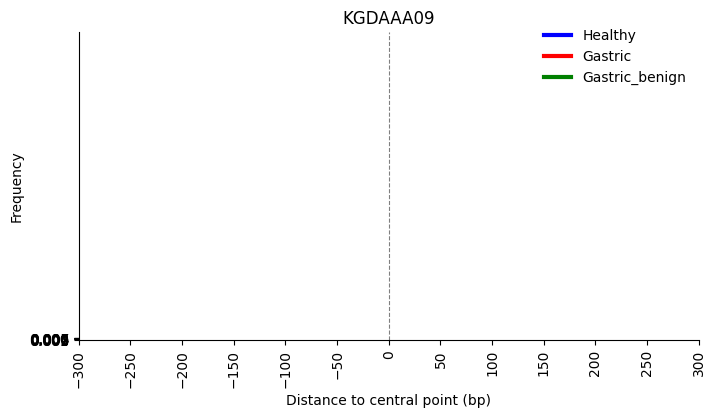

In [965]:
special_sample='KGDAAA09'
G2={
    'Healthy':'blue',
    'Gastric':'r',
    'Gastric_benign':'g'
    }
plt.figure(figsize=(8,4))
custom_lines=[Line2D([0], [0], color='b', lw=3),
              Line2D([0], [0], color='r', lw=3),
              Line2D([0], [0], color='g', lw=3)
              ]
vector=[]
for s in list(DATA[f]['SampleID']):
    if s in list(sample_list_all['SampleID']):
        vector+=[True]
    else:
        vector+=[False]
data=DATA[f][vector]
labels=[]
for s in list(data['SampleID']):
    labels+=[list(sample_list_all[sample_list_all['SampleID']==s]['Type'])[0]]
data.insert(loc=1,column='Type',value=labels)
data.sort_values(by='Type',ascending=False)

order=[]
for s in list(data['SampleID']):
    if list(data[data['SampleID']==s]['Type'])[0]=='Healthy':
        order+=[0]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric':
        order+=[1]
    elif list(data[data['SampleID']==s]['Type'])[0]=='Gastric_benign':
        order+=[2]
data.insert(loc=1,column='order',value=order)
data.sort_values(by='order',ascending=True,inplace=True)          
data.reset_index(drop=True,inplace=True)

x=np.arange(-300,301,1)

# for g in list(G.keys()):
#     y1=stats_fea['NFP']['Mean of '+g]
#     ax=sb.lineplot(x=x,y=y1,color=G[g],lw=2)
#     custom_lines += [Line2D([0], [0], color=G[g], lw=3)]
for i in range(len(data)):
    g=data['Type'][i]
    y2=data.iloc[i,3:]
    if data['SampleID'][i]==special_sample:
        sb.lineplot(x=x,y=y2,color=G2[g],lw=0.5)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Lung'],color='b',lw=2)
# sb.lineplot(x=x,y=stats_fea['NFP']['Mean of Healthy'],color='r',lw=2)

plt.legend(custom_lines,['Healthy','Gastric','Gastric_benign'],bbox_to_anchor=(1, 1.05),frameon=False)
plt.ylabel('Frequency')
plt.yticks(np.arange(0,0.008,0.001))
plt.xlabel('Distance to central point (bp)')
plt.xticks(np.arange(-300,350,50),rotation=90)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axvline(x=0, color='gray', label='axvline - full height',ls='--',lw=0.8)

# plt.axvline(x=-90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axvline(x=90, ymin=0.0035/0.0070, ymax=0.0065/0.0070,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0035-0.00011, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# plt.axhline(y=0.0065, xmin=(300-90+9)/601, xmax=(300+90-7)/601,ls='-',lw=0.8,color='gray')
# square=patches.Rectangle((0.003, 0.003), 0.006, 0.006, edgecolor='orange', facecolor='none')
# ax.add_patch(square)
plt.title(special_sample)
# plt.savefig('.\Figure/NFP_distribution_all.png', dpi=600, bbox_inches='tight')

CNA bins

In [966]:
def vectorcolor(p,f):
    data_split=stats_fea[f]
    # data_concatenate=stats_fea['All_features']
    col_PADJ='PADJ of '+p
    col_L2FC='Log2FC of '+p
    cols=[]
    for i in list(data_split.iloc[:,0]):
        PADJ_split=data_split[data_split[data_split.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]
        # PADJ_concatenate=data_concatenate[data_concatenate[data_concatenate.columns[0]]==i][col_PADJ].reset_index(drop=True)[0]

        L2FC_split=data_split[data_split[data_split.columns[0]]==i][col_L2FC].reset_index(drop=True)[0]

        if L2FC_split <0 and PADJ_split<=0.05:
            cols.append('b')
        elif L2FC_split >=0 and PADJ_split<=0.05:
            cols.append('red')
        elif PADJ_split>0.05:
            cols.append('gray')
    return cols

In [967]:
#Tạo position cho chromosome
Chromosome=[]
for i in range(len(stats_fea['CNA'])):
    chromosome=int(stats_fea['CNA']['FEATURES'].iloc[i].split(":")[0].split("_")[1])
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
results

,Count,Vline,Position
Chromosome,,,
1,159,159,39
2,162,321,240
3,148,469,395
4,140,609,539
5,136,745,677
6,120,865,805
7,111,976,920
8,108,1084,1030
9,83,1167,1125


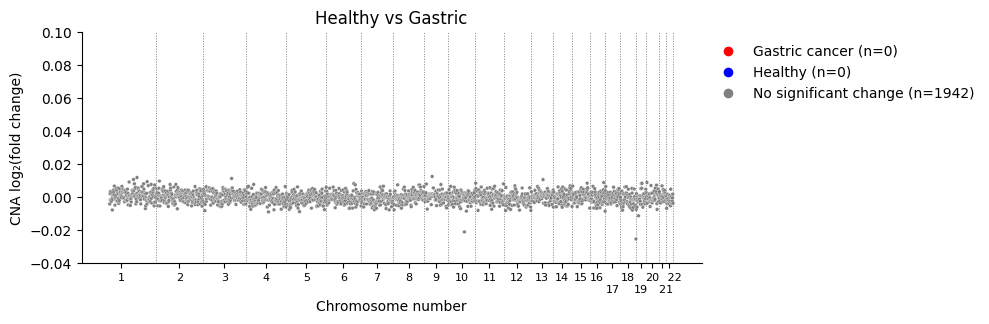

In [968]:
f = 'CNA'
data = stats_fea[f]

for p in PAIR:
    col_log = 'Log2FC of ' + p
    if col_log not in data.columns:
        col_log = 'Distance of ' + p
    col_PADJ = 'PADJ of ' + p 
    cols = vectorcolor(p, f) 

    # --- 1. ĐẾM SỐ LƯỢNG ĐIỂM CHO TẤT CẢ CÁC MÀU ---
    col_counts = pd.Series(cols).value_counts()
    n_gain = col_counts.get('red', 0)
    n_loss = col_counts.get('blue', 0) # Hoặc 'b' tùy vào hàm vectorcolor của bạn
    n_nosig = col_counts.get('gray', 0)

    # --- 2. CẬP NHẬT CÁC ĐỐI TƯỢNG TRONG CHÚ GIẢI ---
    custom_lines = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, mec='w'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, mec='w'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, mec='w'),
    ]

    plt.figure(figsize=(8, 3))
    xlabels = ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','\n17','18','\n19','20','\n  21','   22']
    x = data['FEATURES']
    y = data[col_log]

    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', ls=':', lw=0.7)
        
    sb.scatterplot(x=x, y=y, c=cols, s=7, edgecolor='w')
   
    plt.xticks(ticks=results['Position'], labels=xlabels, fontsize=8)
    plt.yticks(np.arange(-0.04, 0.1, 0.02))
    plt.xlabel('Chromosome number')
    plt.ylabel('CNA ' + u'log\u2082(fold change)')
    plt.title(p)

    # --- 3. CẬP NHẬT DANH SÁCH NHÃN CHÚ GIẢI ---
    legend_labels = [
        f'Gastric cancer (n={n_gain})', 
        f'Healthy (n={n_loss})', 
        f'No significant change (n={n_nosig})'
    ]
    
    plt.legend(custom_lines, legend_labels, 
               loc='upper left', 
               bbox_to_anchor=(1, 1), 
               frameon=False)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout

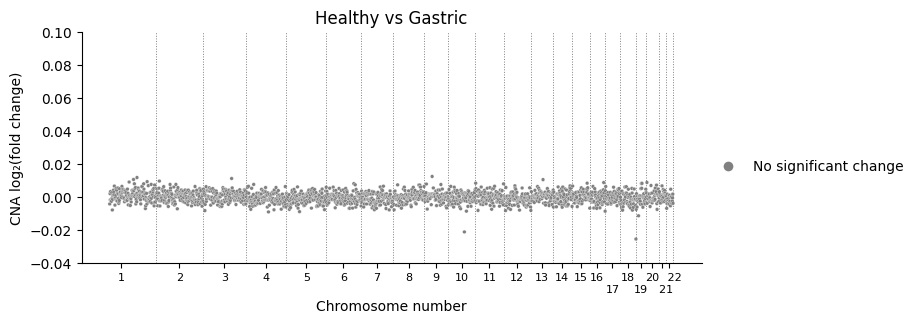

In [969]:
f='CNA'
custom_lines = [
    # Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=8,mec='w'),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='gray', markersize=8,mec='w'),
                    # Line2D([0], [0],marker='o', color='w', markerfacecolor='b', markersize=8,mec='w'),
                    ]
data=stats_fea[f]
for p in PAIR:
    col_log='Log2FC of '+p
    if col_log not in data.columns:
        col_log='Distance of '+p
    col_PADJ='PADJ of '+p 
    cols=vectorcolor(p,f)

    plt.figure(figsize=(8, 3))
    # plt.figure(figsize=(6/1.4,3/1.5))
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','\n17','18','\n19','20','\n  21','   22']
    x=data['FEATURES']
    y=data[col_log]

    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
        
    sb.scatterplot(x=x,y=y,c=cols,s=7,edgecolor='w')
    # lst_name_show=["CNA_10:135000001-135534747"]
    # region_name = list(data['FEATURES'])
    # for i, txt in enumerate(region_name):
    #     if txt in lst_name_show:
    #         plt.text(x[i],y[i],txt,fontsize=8,color='red')
   
    
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(-0.04,0.1,0.02))
    plt.xlabel('Chromosome number')
    plt.ylabel('CNA '+u'log\u2082(fold change)')
    plt.title(p)
    # n_gain=pd.DataFrame(cols)[0].value_counts()['red']
    # n_loss=pd.DataFrame(cols)[0].value_counts()['b']
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['No significant change'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\CNA_bins.png', dpi=600, bbox_inches='tight')

SCNA bins

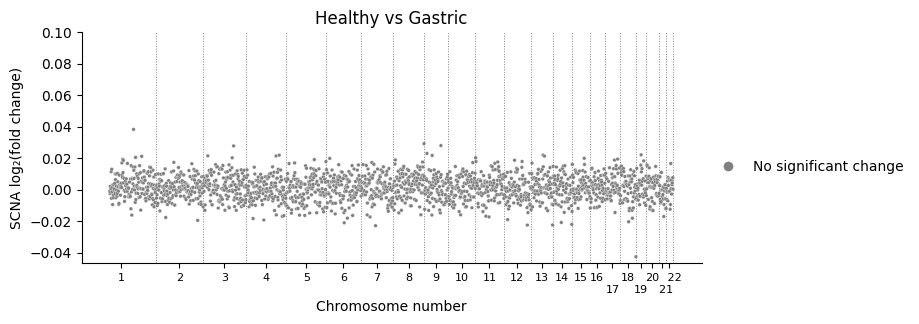

In [970]:
f='SCNA'
custom_lines = [
    # Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=8,mec='w'),
                Line2D([0], [0],marker='o', color='w', markerfacecolor='gray', markersize=8,mec='w'),
                    # Line2D([0], [0],marker='o', color='w', markerfacecolor='b', markersize=8,mec='w'),
                    ]
data=stats_fea[f]
for p in PAIR:
    col_log='Log2FC of '+p
    if col_log not in data.columns:
        col_log='Distance of '+p
    col_PADJ='PADJ of '+p 
    cols=vectorcolor(p,f)

    plt.figure(figsize=(8, 3))
    # plt.figure(figsize=(6/1.4,3/1.5))
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','\n17','18','\n19','20','\n  21','   22']
    x=data['FEATURES']
    y=data[col_log]

    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
        
    sb.scatterplot(x=x,y=y,c=cols,s=7,edgecolor='w')
    # lst_name_show=["CNA_10:135000001-135534747"]
    # region_name = list(data['FEATURES'])
    # for i, txt in enumerate(region_name):
    #     if txt in lst_name_show:
    #         plt.text(x[i],y[i],txt,fontsize=8,color='red')
   
    
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(-0.04,0.1,0.02))
    plt.xlabel('Chromosome number')
    plt.ylabel('SCNA '+u'log\u2082(fold change)')
    plt.title(p)
    # n_gain=pd.DataFrame(cols)[0].value_counts()['red']
    # n_loss=pd.DataFrame(cols)[0].value_counts()['b']
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['No significant change'],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    # plt.legend(custom_lines,['CNA gain (n='+str(n_gain)+')','No significant change','CNA loss (n='+str(n_loss)+')'],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\CNA_bins.png', dpi=600, bbox_inches='tight')

RATIOSL

In [971]:
#Tạo position cho chromosome
GWFP=stats_fea['RATIOSL']
GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
Chromosome=[]
for i in range(len(GWFP)):
    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
    chromosome=int(chromosome)
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
results

,Count,Vline,Position
Chromosome,,,
1,230,230,57
2,241,471,350
3,196,667,569
4,190,857,762
5,178,1035,946
6,165,1200,1117
7,158,1358,1279
8,144,1502,1430
9,117,1619,1560



📊 Healthy vs Gastric:
  Healthy - Mean: 0.1822, Median: 0.1785, Min: 0.1573, Max: 0.3398
  Gastric - Mean: 0.1916, Median: 0.1877, Min: 0.1666, Max: 0.3504
  🔥 Mann-Whitney U test: p = 2.588e-165
  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.


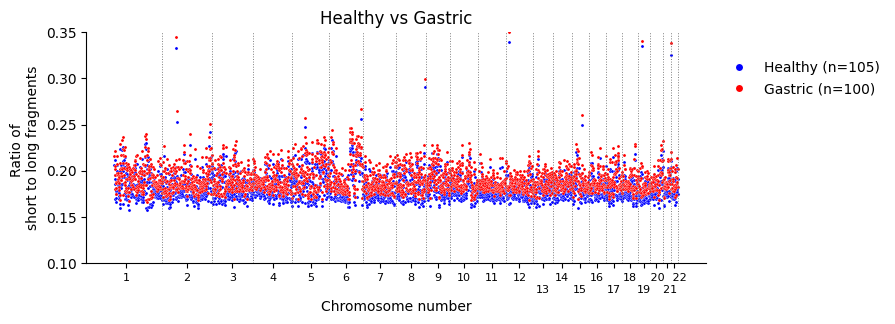

In [972]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to long fragments')
    plt.title(p)
    #custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    #plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric (n='+str(len(gastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

    group1_values = GWFP[col1].dropna()
    group2_values = GWFP[col2].dropna()
     # ✅ Sau khi vẽ, in thống kê và kết luận
    mean1, mean2 = group1_values.mean(), group2_values.mean()
    median1, median2 = group1_values.median(), group2_values.median()
    min1, min2 = group1_values.min(), group2_values.min()
    max1, max2 = group1_values.max(), group2_values.max()

    print(f"\n📊 {p}:")
    print(f"  {p.split(' vs ')[0]} - Mean: {mean1:.4f}, Median: {median1:.4f}, Min: {min1:.4f}, Max: {max1:.4f}")
    print(f"  {p.split(' vs ')[1]} - Mean: {mean2:.4f}, Median: {median2:.4f}, Min: {min2:.4f}, Max: {max2:.4f}")

    # ✅ Kiểm định thống kê giữa 2 nhóm
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    print(f"  🔥 Mann-Whitney U test: p = {p_value:.4g}")

    # ✅ Kết luận
    if p_value < 0.05:
        print("  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")
    else:
        print("  ❌ Kết luận: Không có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")



RATIOST

In [973]:
#Tạo position cho chromosome
GWFP=stats_fea['RATIOST']
GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
Chromosome=[]
for i in range(len(GWFP)):
    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
    chromosome=int(chromosome)
    Chromosome+=[chromosome]
results=pd.DataFrame({'Chromosome':Chromosome})
results=results['Chromosome'].value_counts().sort_index()
results=pd.DataFrame({'Count':results})
lst=[]
for i in range(len(results)):
    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
    lst+=[sum(results.iloc[:i+1,0])]
results['Vline']=lst

Position=[]
for i in range(1,23,1):
    if i ==1:
        posit=int(results['Vline'][i]/4)
    else:
        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
    Position+=[posit]
results['Position']=Position
# results


📊 Healthy vs Gastric:
  Healthy - Mean: 0.1533, Median: 0.1507, Min: 0.1353, Max: 0.2527
  Gastric - Mean: 0.1599, Median: 0.1573, Min: 0.1421, Max: 0.2583
  🔥 Mann-Whitney U test: p = 2.72e-162
  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.


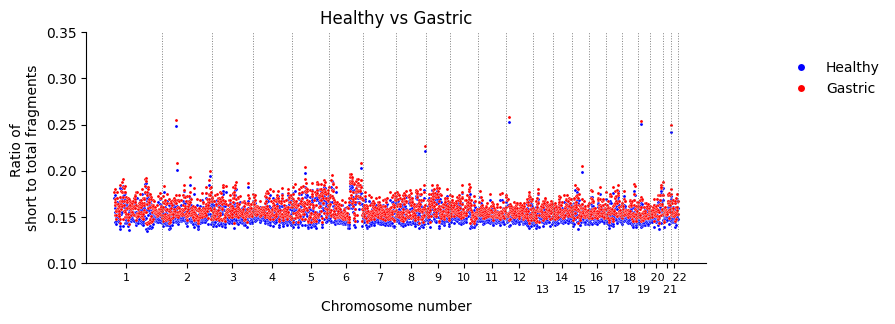

In [974]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to total fragments')
    plt.title(p)
    #custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
    #               Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    #plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.legend(custom_lines,['Healthy','Gastric'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

    group1_values = GWFP[col1].dropna()
    group2_values = GWFP[col2].dropna()
     # ✅ Sau khi vẽ, in thống kê và kết luận
    mean1, mean2 = group1_values.mean(), group2_values.mean()
    median1, median2 = group1_values.median(), group2_values.median()
    min1, min2 = group1_values.min(), group2_values.min()
    max1, max2 = group1_values.max(), group2_values.max()

    print(f"\n📊 {p}:")
    print(f"  {p.split(' vs ')[0]} - Mean: {mean1:.4f}, Median: {median1:.4f}, Min: {min1:.4f}, Max: {max1:.4f}")
    print(f"  {p.split(' vs ')[1]} - Mean: {mean2:.4f}, Median: {median2:.4f}, Min: {min2:.4f}, Max: {max2:.4f}")

    # ✅ Kiểm định thống kê giữa 2 nhóm
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    print(f"  🔥 Mann-Whitney U test: p = {p_value:.4g}")

    # ✅ Kết luận
    if p_value < 0.05:
        print("  ✅ Kết luận: Có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")
    else:
        print("  ❌ Kết luận: Không có sự khác biệt có ý nghĩa thống kê giữa 2 nhóm.")

In [975]:
# ✅ LẤY DANH SÁCH CÁC CỘT TÍNH TOÁN (KHÔNG GỒM CỘT PHÂN NHÓM)
#columns = [col for col in df.columns if col != 'Giai đoạn theo TNM']

# -----------------------------
# TÍNH LOG2FC & P-VALUE
# -----------------------------
#results = []
#for feature in columns:
#    group_I = df[df['Giai đoạn theo TNM'] == 'I'][feature]
#    group_II = df[df['Giai đoạn theo TNM'] == 'II'][feature]

#   mean_I = group_I.mean()
#    mean_II = group_II.mean()
#    log2fc = np.log2((mean_II + 1e-9) / (mean_I + 1e-9))
#    _, p_val = ttest_ind(group_II, group_I, equal_var=False)

#    results.append({
#        'FEATURE': feature,
#        'Log2FC': log2fc,
#        'p-value': p_val
#    })

#results_df = pd.DataFrame(results)

# -----------------------------
# VẼ HEATMAP (GIỮ ĐÚNG VỊ TRÍ, CHỈ HIỂN THỊ P < 0.05)
# -----------------------------
#sorted_all = results_df.sort_values(by='p-value', ascending=True).reset_index(drop=True)
#log2fc_vals = sorted_all['Log2FC'].values
#features = sorted_all['FEATURE'].values
#pvals = sorted_all['p-value'].values

#masked_vals = [val if p < 0.05 else np.nan for val, p in zip(log2fc_vals, pvals)]
#masked_df = pd.DataFrame([masked_vals], columns=features, index=['Log₂FC'])

#plt.figure(figsize=(12, 2))
#sb.heatmap(masked_df,
#           cmap='seismic', center=0,
#           vmin=-0.16, vmax=0.16,
#           linewidths=1,
#           xticklabels=True, yticklabels=True,
#           cbar_kws={'label': 'Log₂FC'})
#plt.xticks(rotation=90)
#plt.title('Log₂FC heatmap (features with p < 0.05 only)', fontsize=12)
#plt.tight_layout()
#plt.show()

In [976]:
stats_fea['RATIOSL']

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,RATIOSL_1:1-1000000,0.206040,0.215975,0.200684,0.208963,0.039138,0.040261,18.995483,18.641398,3.126502,...,0.067938,0.058320,0.044639,0.073370,0.21,0.22,1.134482,0.009935,0.578704,0.578704
1,RATIOSL_1:100000001-101000000,0.191028,0.201402,0.184709,0.193993,0.036565,0.041396,19.141311,20.553992,3.089996,...,0.076299,0.070753,0.035507,0.073370,0.19,0.20,1.134482,0.010375,0.582407,0.582407
2,RATIOSL_1:10000001-11000000,0.194903,0.204679,0.190520,0.200134,0.036623,0.038684,18.790512,18.899577,3.122361,...,0.070613,0.071023,0.044412,0.073370,0.19,0.20,1.134482,0.009777,0.578788,0.578788
3,RATIOSL_1:1000001-2000000,0.211064,0.221867,0.207704,0.217325,0.036782,0.039145,17.426849,17.643464,3.139557,...,0.072017,0.065323,0.031914,0.073370,0.21,0.22,1.134482,0.010803,0.584091,0.584091
4,RATIOSL_1:101000001-102000000,0.185484,0.195182,0.182020,0.189425,0.035320,0.037800,19.041860,19.366644,3.045117,...,0.073525,0.057537,0.033669,0.073370,0.19,0.20,1.134482,0.009698,0.583249,0.583249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2867,RATIOSL_Y:10000001-11000000,0.240791,0.247693,0.238949,0.245773,0.054993,0.055213,22.838419,22.290916,3.451592,...,0.040775,0.040625,0.310734,0.311276,0.24,0.25,0.506855,0.006903,0.539731,0.539731
2868,RATIOSL_Y:13000001-14000000,0.482031,0.479249,0.439905,0.455926,0.125731,0.113619,26.083584,23.707681,3.647321,...,-0.008351,0.051607,0.943500,0.943500,0.48,0.48,0.025258,-0.002782,0.502778,0.497222
2869,RATIOSL_Y:58000001-59000000,0.340472,0.349036,0.331345,0.341972,0.066767,0.066607,19.610190,19.083099,3.292941,...,0.035839,0.045547,0.241816,0.242491,0.34,0.35,0.615304,0.008564,0.545875,0.545875
2870,RATIOSL_Y:59000001-59373566,0.199530,0.213539,0.196222,0.212464,0.049208,0.052898,24.661762,24.772070,3.366097,...,0.097896,0.114734,0.049529,0.073370,0.20,0.21,1.134482,0.014009,0.576978,0.576978


In [977]:
GWFP

,FEATURES,Mean of Healthy,Mean of Gastric,Median of Healthy,Median of Gastric,SD of Healthy,SD of Gastric,CV% of Healthy,CV% of Gastric,Entropy of Healthy,...,Log2FC of Healthy vs Gastric,Log2FC Median of Healthy vs Gastric,P of Healthy vs Gastric,PADJ of Healthy vs Gastric,Round_Mean of Healthy,Round_Mean of Gastric,-log10(p-value) of Healthy vs Gastric,Distance of Healthy vs Gastric,AUC of Healthy vs Gastric,AUCADJ of Healthy vs Gastric
0,RATIOST_1:1-1000000,0.170006,0.176724,0.167141,0.172845,0.025775,0.026943,15.161242,15.245744,3.224541,...,0.055909,0.048409,0.044639,0.073421,0.17,0.18,1.134179,0.006718,0.578704,0.578704
1,RATIOST_1:100000001-101000000,0.159637,0.166671,0.155911,0.162474,0.024536,0.028132,15.369575,16.878761,3.178651,...,0.062207,0.059486,0.035507,0.073421,0.16,0.17,1.134179,0.007034,0.582407,0.582407
2,RATIOST_1:10000001-11000000,0.162367,0.169067,0.160031,0.166760,0.024372,0.026081,15.010229,15.426229,3.149573,...,0.058340,0.059420,0.044412,0.073421,0.16,0.17,1.134179,0.006700,0.578788,0.578788
3,RATIOST_1:1000001-2000000,0.173551,0.180759,0.171982,0.178526,0.024063,0.025678,13.864927,14.205527,3.242003,...,0.058710,0.053876,0.031914,0.073421,0.17,0.18,1.134179,0.007208,0.584091,0.584091
4,RATIOST_1:101000001-102000000,0.155748,0.162480,0.153990,0.159258,0.024043,0.026196,15.437077,16.122587,3.106344,...,0.061044,0.048527,0.033669,0.073421,0.16,0.16,1.134179,0.006731,0.583249,0.583249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2713,RATIOST_9:95000001-96000000,0.168093,0.174997,0.165733,0.170746,0.023531,0.025603,13.999033,14.630657,3.175654,...,0.058076,0.042985,0.037233,0.073421,0.17,0.17,1.134179,0.006905,0.581650,0.581650
2714,RATIOST_9:96000001-97000000,0.151705,0.157592,0.148045,0.155171,0.023750,0.024959,15.655215,15.837669,3.073191,...,0.054927,0.067825,0.053517,0.074484,0.15,0.16,1.127939,0.005887,0.575673,0.575673
2715,RATIOST_9:97000001-98000000,0.153435,0.160414,0.149945,0.157322,0.024250,0.025603,15.804649,15.960506,3.190770,...,0.064169,0.069291,0.030074,0.073421,0.15,0.16,1.134179,0.006979,0.585017,0.585017
2716,RATIOST_9:98000001-99000000,0.147849,0.153684,0.146003,0.150796,0.023688,0.025733,16.021859,16.744331,3.222184,...,0.055843,0.046598,0.075717,0.086767,0.15,0.15,1.061645,0.005835,0.569613,0.569613


CLE

In [978]:
#Tạo position cho chromosome
#GWFP=stats_fea['CLE']
#GWFP=GWFP[~GWFP['FEATURES'].str.contains('X|Y', case=False, na=False)]
#Chromosome=[]
#for i in range(len(GWFP)):
#    chromosome=GWFP['FEATURES'].iloc[i].split("_")[1].split(':')[0]
#    chromosome=int(chromosome)
#    Chromosome+=[chromosome]
#results=pd.DataFrame({'Chromosome':Chromosome})
#results=results['Chromosome'].value_counts().sort_index()
#results=pd.DataFrame({'Count':results})
#lst=[]
#for i in range(len(results)):
#    # lst+=[sum(results.iloc[:i,0])+round(results.iloc[i,0]/2,0)]
#    lst+=[sum(results.iloc[:i+1,0])]
#results['Vline']=lst

#Position=[]
#for i in range(1,23,1):
#    if i ==1:
#        posit=int(results['Vline'][i]/4)
#    else:
#        posit=int((results['Vline'][i]+results['Vline'][i-1])/2)
#    Position+=[posit]
#results['Position']=Position
#results

NameError: name 'gastric_benign' is not defined

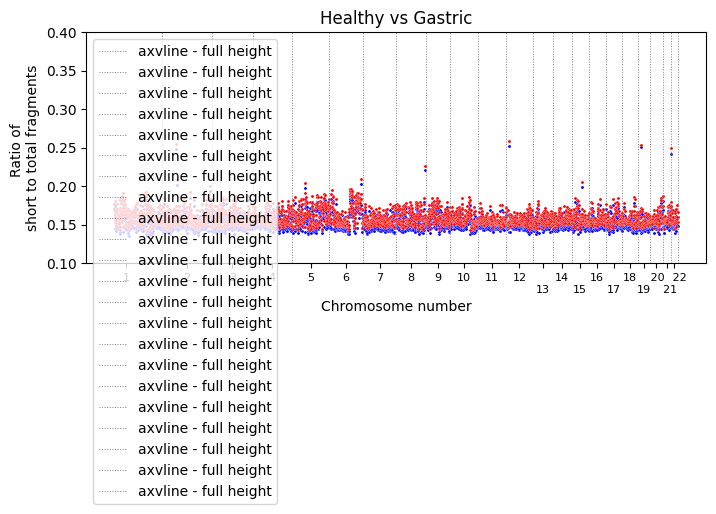

In [979]:
G['Nongastric']='cyan'
for p in PAIR:
    col1='Mean of '+p.split(" vs ")[0]
    #col2='Mean of '+p.split(" vs ")[1]
    # col_log='Log2FC_'+p 
    # col_PADJ='PADJ_'+p 
    # vectorcolorCNA=[]
    # for i in range(len(stat_GWFP_ratio)):
    #     if stat_CNA[col_PADJ].iloc[i] >= 0.05:
    #         vectorcolorCNA+=['gray']
    #     elif stat_CNA[col_log].iloc[i] > 0:
    #         vectorcolorCNA+=['red']
    #     else:
    #         vectorcolorCNA+=['blue']
    plt.figure(figsize=(8,3))
    for vline in results['Vline']:
        plt.axvline(x=vline, color='gray', label='axvline - full height',ls=':',lw=0.7)
    xlabels=['1','2','3','4','5','6','7','8','9','10','11','12','\n13','14','\n15','16','\n17','18','\n19',' 20','\n  21','   22']
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col1],c=G[p.split(" vs ")[0]],s=5,edgecolor='w')
    sb.scatterplot(x=GWFP['FEATURES'],y=GWFP[col2],c=G[p.split(" vs ")[1]],s=5,edgecolor='w')
    plt.xticks(ticks=results['Position'],labels=xlabels,fontsize=8)
    plt.yticks(np.arange(0.1,0.4,0.05))
    # plt.ylim((0.1,0.35))
    plt.xlabel('Chromosome number')
    plt.ylabel('Ratio of \nshort to total fragments')
    plt.title(p)
    custom_lines = [Line2D([0], [0],marker='o',color='w', markerfacecolor='b', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='g', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='r', markersize=6,mec='w'),
                    Line2D([0], [0],marker='o', color='w', markerfacecolor='cyan', markersize=6,mec='w')]
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper right', bbox_to_anchor=(0.5, -0.3),frameon=False)
    # plt.legend(custom_lines,[p.split(" vs ")[1],p.split(" vs ")[0]],loc='upper left', bbox_to_anchor=(1, 0.5),frameon=False)
    plt.legend(custom_lines,['Healthy (n='+str(len(healthy))+')','Gastric_benign (n='+str(len(gastric_benign))+')','Gastric (n='+str(len(gastric))+')','Nongastric (n='+str(len(Nongastric))+')'],loc='center right',bbox_to_anchor=(1.3, 0.8),frameon=True,edgecolor='w')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # plt.savefig('.\Figure\FLEN_ratio_short_total.png', dpi=600, bbox_inches='tight')

PCA

In [ ]:
G={
    'Healthy':'b',
    'Gastric_benign':'g',
    'Gastric':'r'
    }

In [ ]:
special_samples=['KGDAAA09','MG168','ZK0AAAI07NB','ZMG050NB']
special_samples

['KGDAAA09', 'MG168', 'ZK0AAAI07NB', 'ZMG050NB']

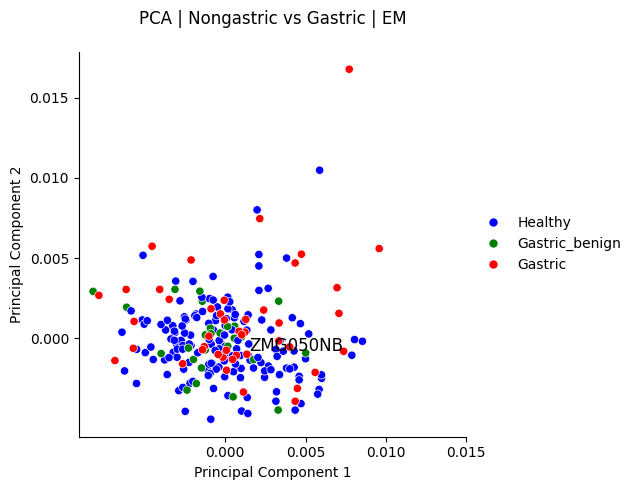

In [ ]:
f='EM'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[0,0.02,0.005],xticks=[0,0.02,0.005],
      save=False,figname='PCA.png'
            )

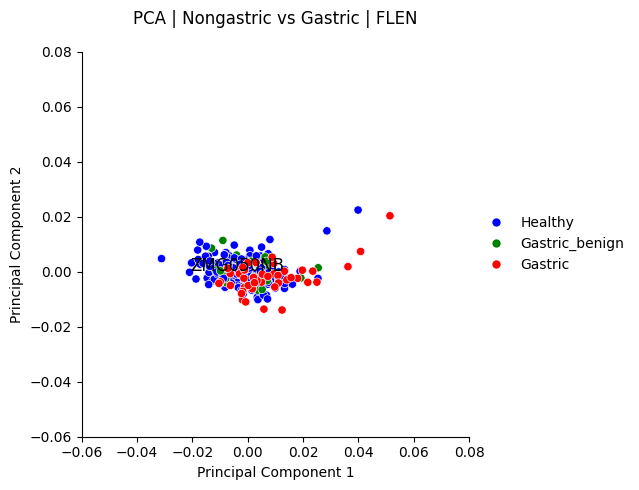

In [ ]:
f='FLEN'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.06,0.08,0.02],xticks=[-0.06,0.08,0.02],
      save=False,figname='PCA.png'
            )

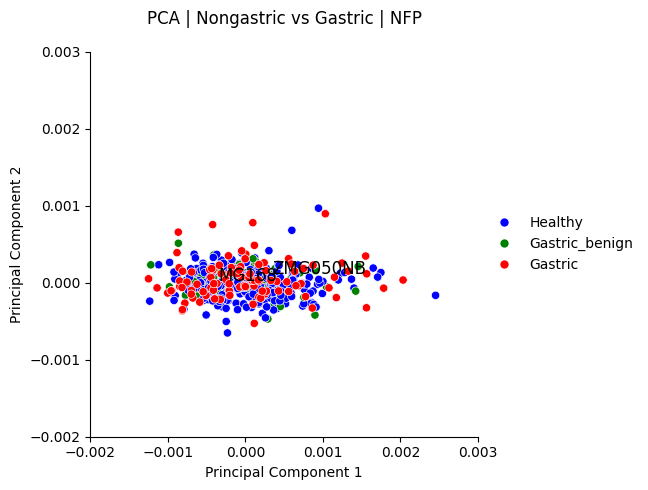

In [ ]:
f='NFP'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.002,0.004,0.001],xticks=[-0.002,0.004,0.001],
      save=False,figname='PCA.png'
            )

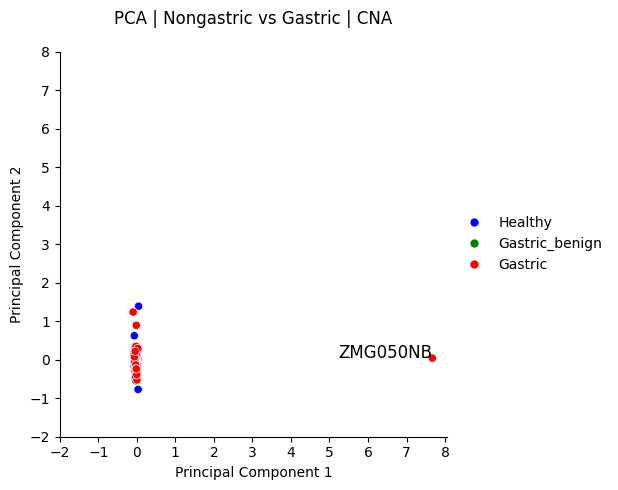

In [ ]:
f='CNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

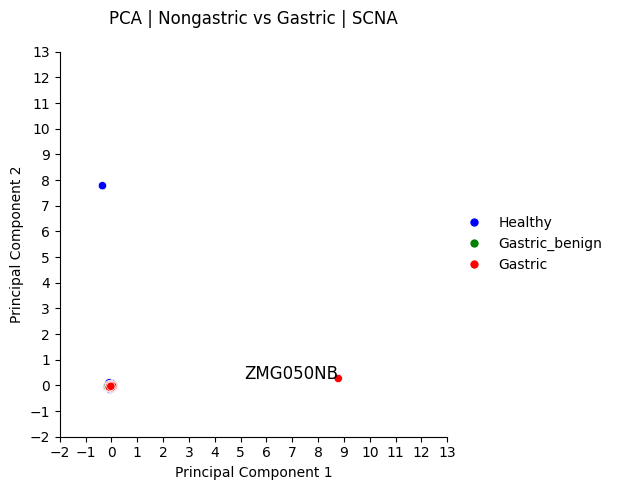

In [ ]:
f='SCNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,14,1],xticks=[-2,14,1],
      save=False,figname='PCA.png'
            )

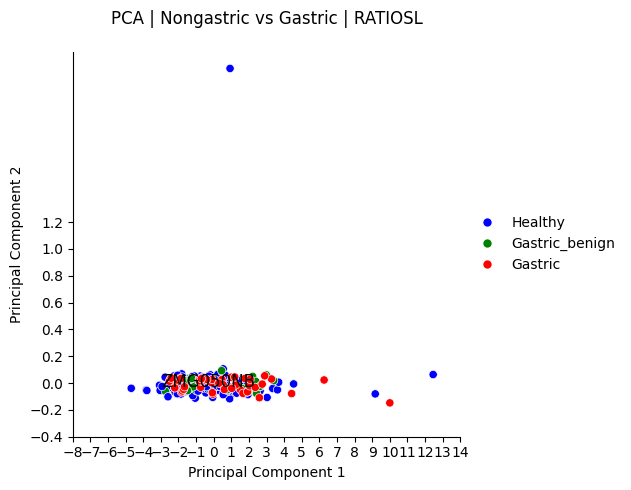

In [ ]:
f='RATIOSL'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.4,1.4,0.2],xticks=[-8,15,1],
      save=False,figname='PCA.png'
            )

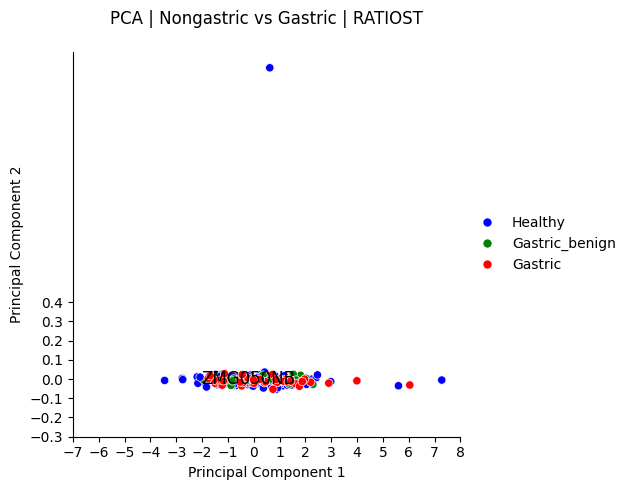

In [ ]:
f='RATIOST'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.3,0.5,0.1],xticks=[-7,9,1],
      save=False,figname='PCA.png'
            )

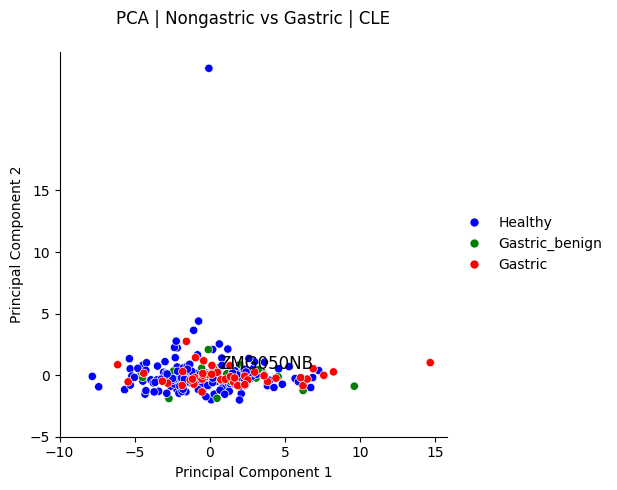

In [ ]:
f='CLE'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES,
      stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=special_samples,
      plot_pct_explain=False,top_pc=2,
      yticks=[-5,20,5],xticks=[-10,20,5],
      save=False,figname='PCA.png'
            )

PCA filter

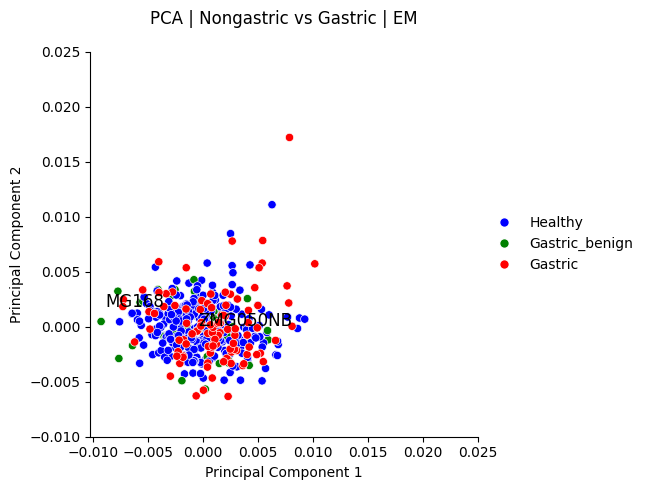

In [ ]:
f='EM'
healthy1=healthy[~healthy.iloc[:, 0].str.contains(special_sample, na=False)]
Nongastric1=pd.concat([healthy1,gastric_benign],axis=0)
PCAsigfea(
        DATA,
        SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
        stats_fea=stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        p='Nongastric vs Gastric',
        f=f,
        sig=False,alpha=0.05,
        show_ID=True,IDs=special_samples,
        plot_pct_explain=False,top_pc=2,
        yticks=[-0.01,0.025,0.005],xticks=[-0.01,0.025,0.005],
        save=False,figname='PCA.png'
              )

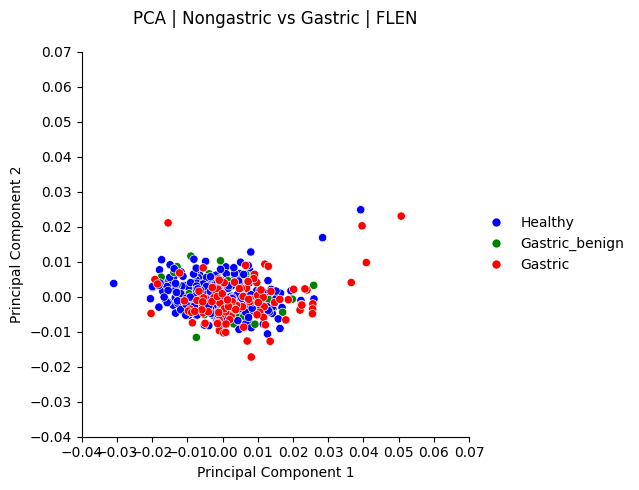

In [ ]:
f='FLEN'
healthy1=healthy[~healthy.iloc[:, 0].str.contains(special_sample, na=False)]
Nongastric1=pd.concat([healthy1,gastric_benign],axis=0)
PCAsigfea(
        DATA,
        SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
        stats_fea=stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        p='Nongastric vs Gastric',
        f=f,
        sig=False,alpha=0.05,
        show_ID=True,IDs=[special_sample],
        plot_pct_explain=False,top_pc=2,
        yticks=[-0.04,0.07,0.01],xticks=[-0.04,0.07,0.01],
        save=False,figname='PCA.png'
              )

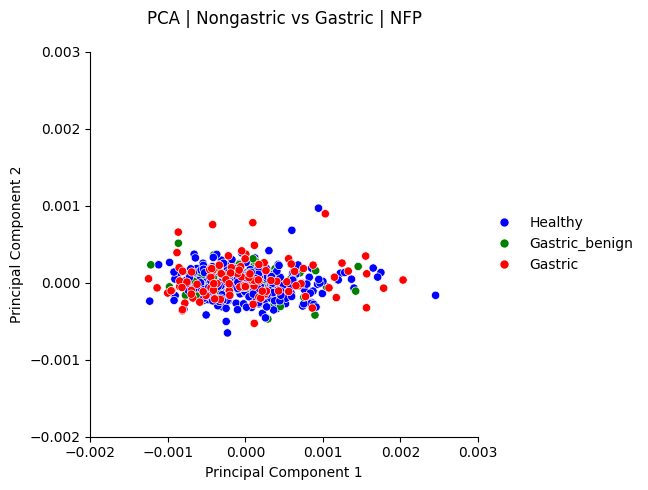

In [ ]:
f='NFP'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=[special_sample],
      plot_pct_explain=False,top_pc=2,
      yticks=[-0.002,0.004,0.001],xticks=[-0.002,0.004,0.001],
      save=False,figname='PCA.png'
            )

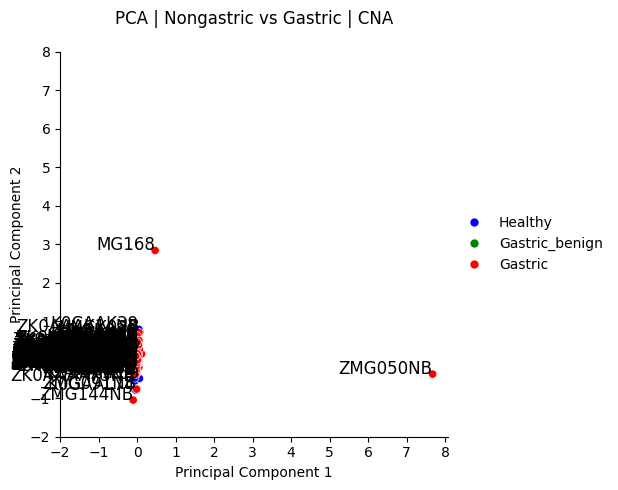

In [ ]:
f='CNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=list(set(sample_list_all['SampleID'])-set(special_sample)),
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

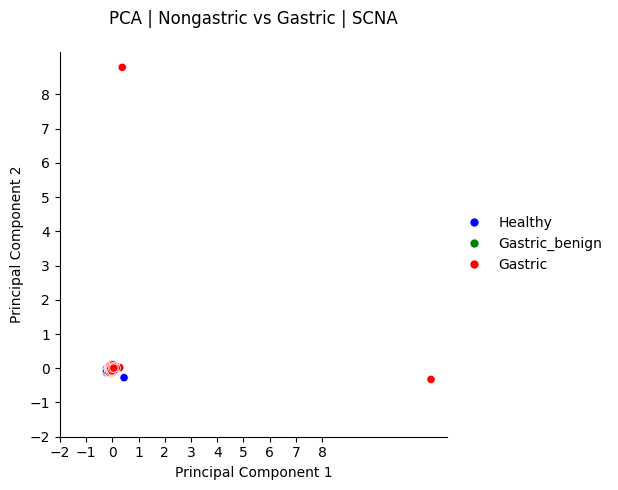

In [ ]:
f='SCNA'
# for f in features:
PCAsigfea(
      DATA,
      SAMPLES={'Healthy':healthy1,'Gastric':gastric,'Gastric_benign':gastric_benign,'Nongastric':Nongastric1},
      stats_fea=stats_fea,
      dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
      p='Nongastric vs Gastric',
      f=f,
      sig=False,alpha=0.05,
      show_ID=True,IDs=[special_sample],
      plot_pct_explain=False,top_pc=2,
      yticks=[-2,9,1],xticks=[-2,9,1],
      save=False,figname='PCA.png'
            )

t-SNE

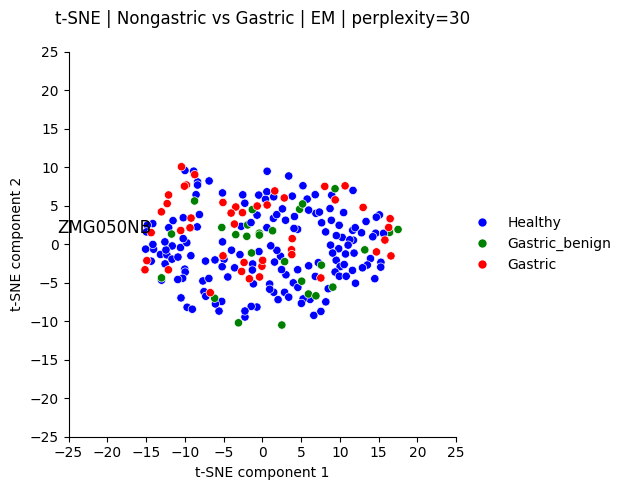

In [ ]:
f='EM'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-25,30,5],
    xticks=[-25,30,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

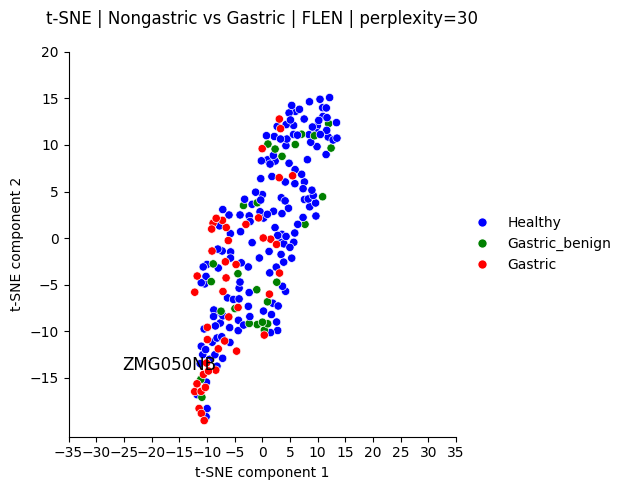

In [ ]:
f='FLEN'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-15,25,5],
    xticks=[-35,40,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

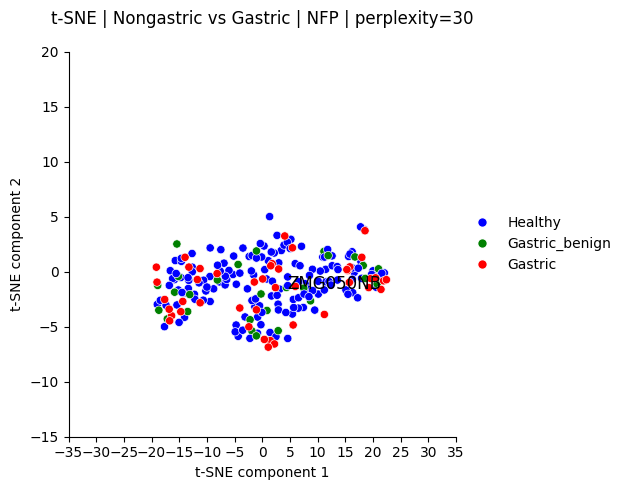

In [ ]:
f='NFP'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-15,25,5],
    xticks=[-35,40,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

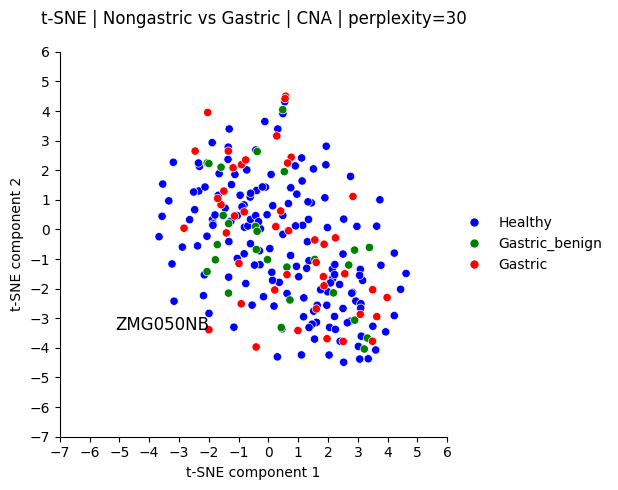

In [ ]:
f='CNA'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-7,7,1],
    xticks=[-7,7,1],
    perplexity=30,
    save=False,
    figname='TSNE.png')

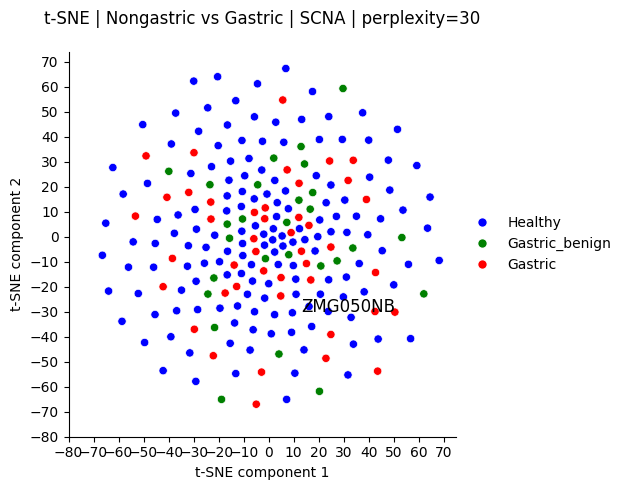

In [ ]:
f='SCNA'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-80,80,10],
    xticks=[-80,80,10],
    perplexity=30,
    save=False,
    figname='TSNE.png')

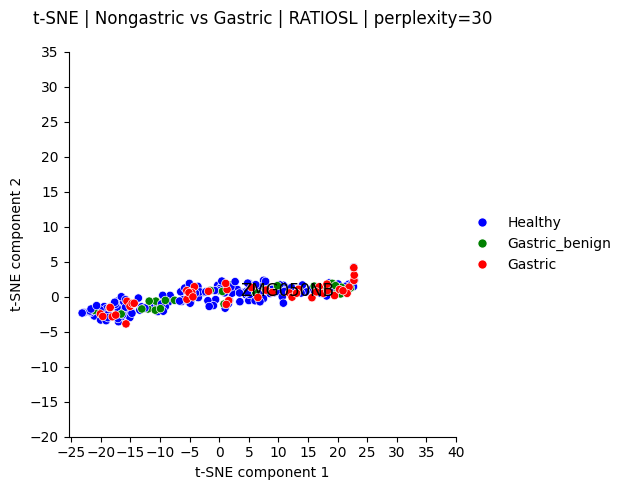

In [ ]:
f='RATIOSL'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-20,40,5],
    xticks=[-25,45,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

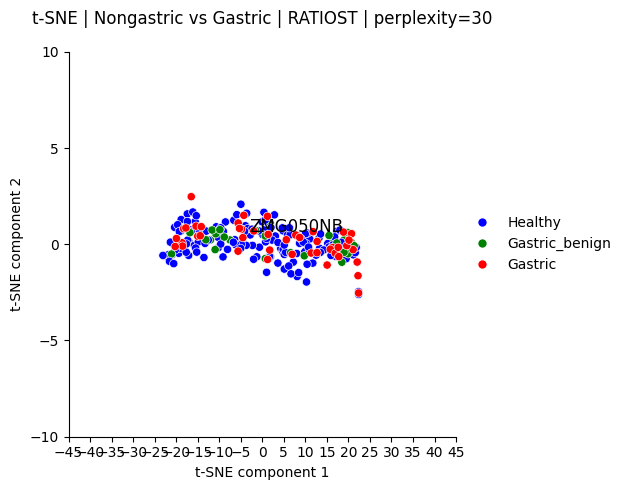

In [ ]:
f='RATIOST'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-10,15,5],
    xticks=[-45,50,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

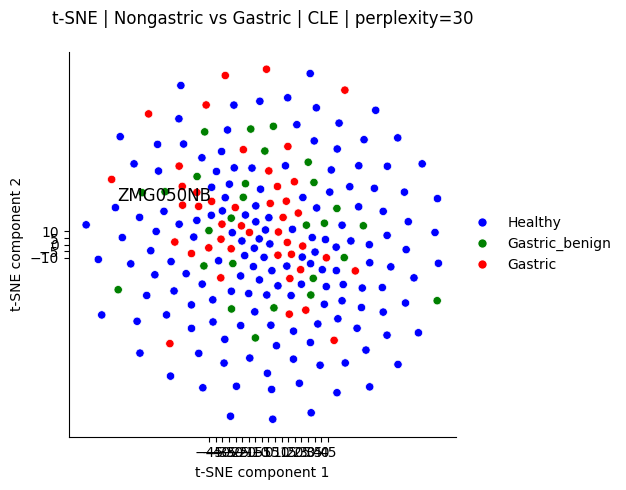

In [ ]:
f='CLE'
TSNEfea(DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,
    p='Nongastric vs Gastric',
    sig=False,alpha=0.05,
    show_ID=True,IDs=special_samples,
    yticks=[-10,15,5],
    xticks=[-45,50,5],
    perplexity=30,
    save=False,
    figname='TSNE.png')

UMAP

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


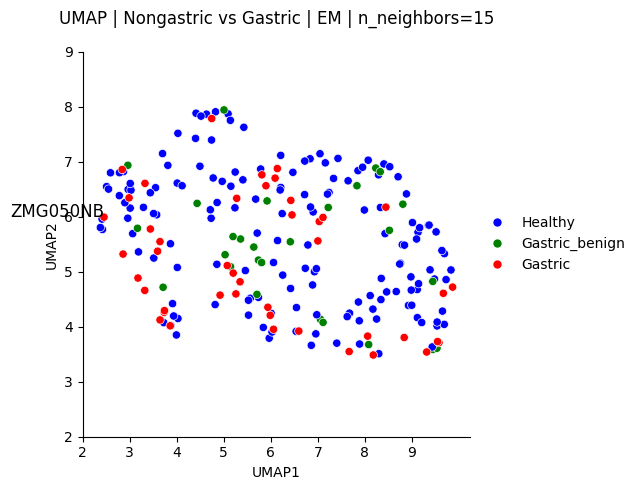

In [ ]:
f='EM'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[2,10,1],
        xticks=[2,10,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


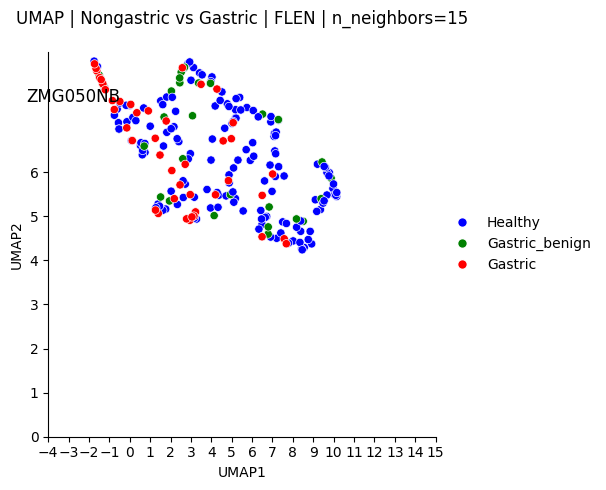

In [ ]:
f='FLEN'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[0,7,1],
        xticks=[-4,16,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


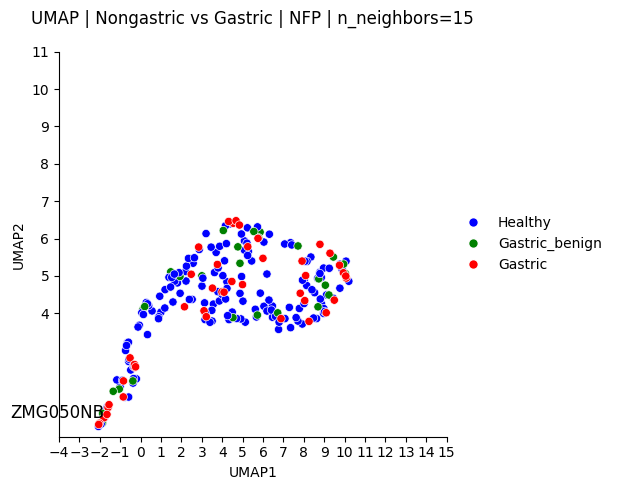

In [ ]:
f='NFP'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[4,12,1],
        xticks=[-4,16,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


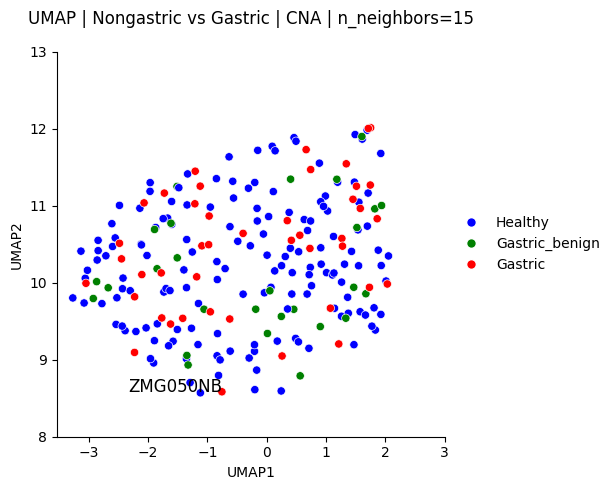

In [ ]:
f='CNA'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[8,14,1],
        xticks=[-3,4,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


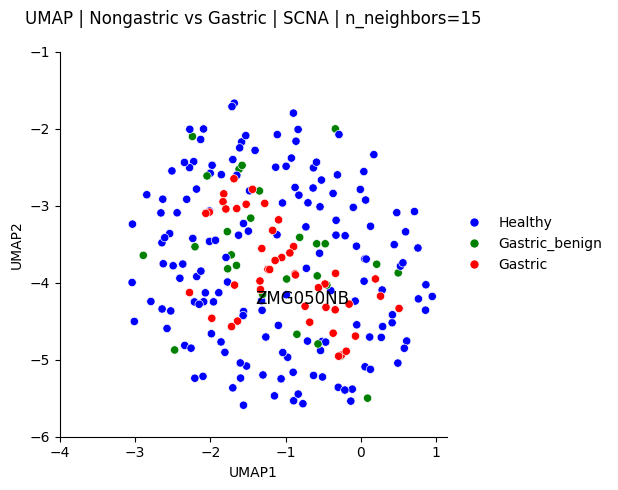

In [ ]:
f='SCNA'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[-6,0,1],
        xticks=[-4,2,1],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


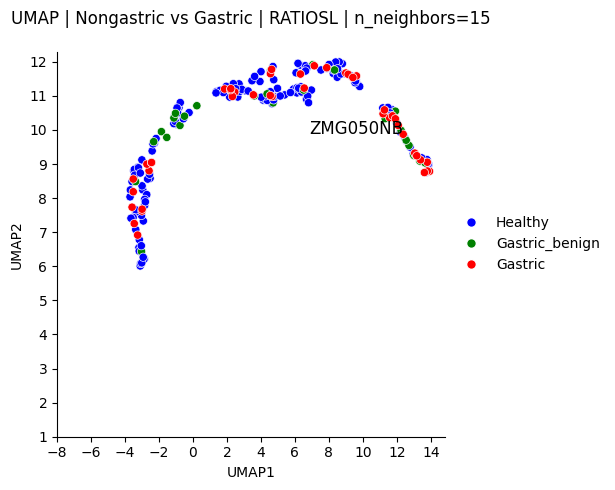

In [ ]:
f='RATIOSL'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[1,13,1],
        xticks=[-8,16,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


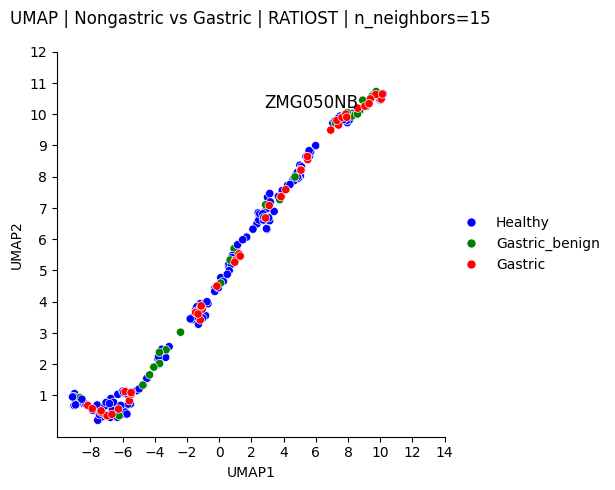

In [ ]:
f='RATIOST'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[1,13,1],
        xticks=[-8,16,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

C:\Users\VODACHO\AppData\Roaming\Python\Python38\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


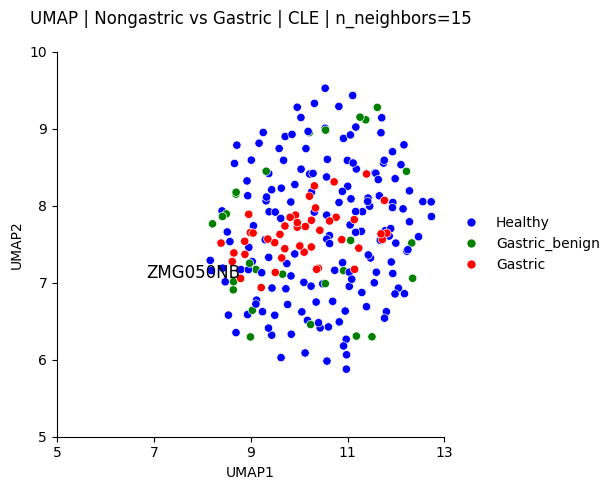

In [ ]:
f='CLE'
UMAPfea(
        DATA, SAMPLES,stats_fea,
        dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
        f=f,p='Nongastric vs Gastric',
        sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
        yticks=[5,11,1],
        xticks=[5,14,2],
        n_neighbors=15,n_components=2,
        save=False,figname='UMAP.png'
            )

LDA

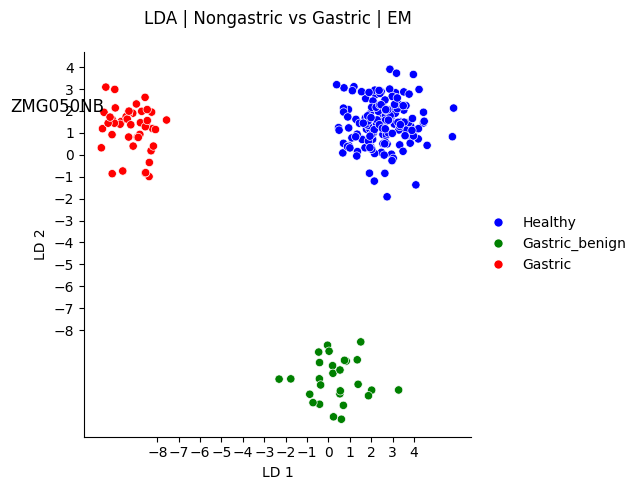

In [ ]:
f='EM'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

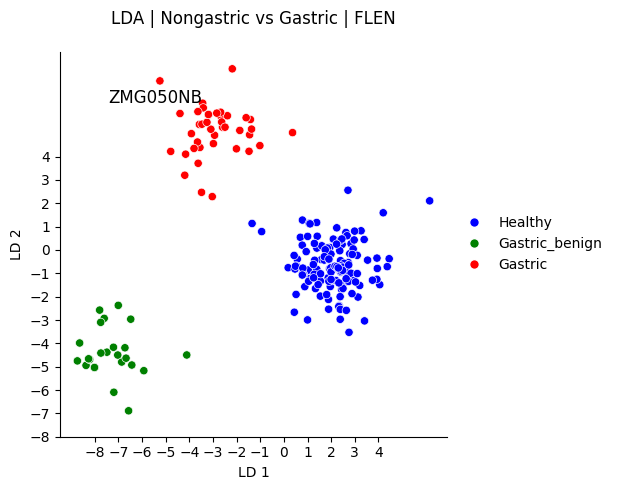

In [ ]:
f='FLEN'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

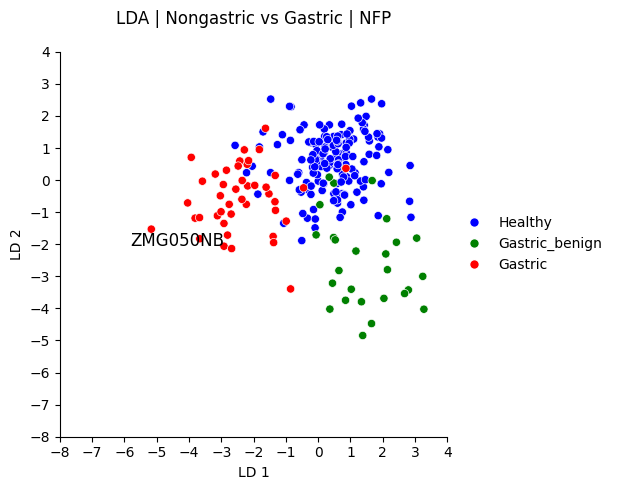

In [ ]:
f='NFP'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-8,5,1],xticks=[-8,5,1],
              save=False,figname='LDA.png'
              )

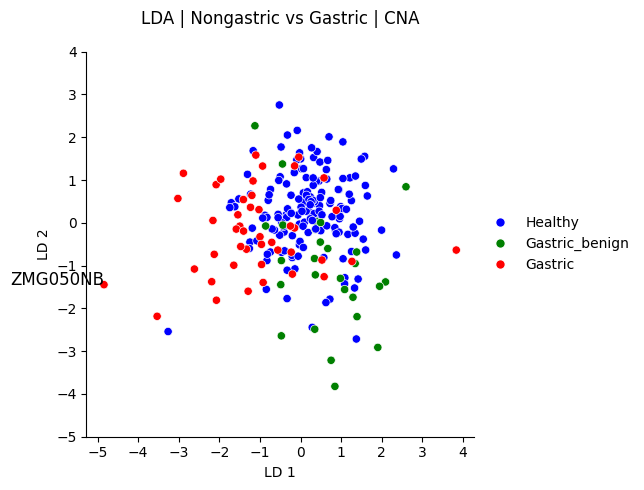

In [ ]:
f='CNA'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,5,1],
              save=False,figname='LDA.png'
              )

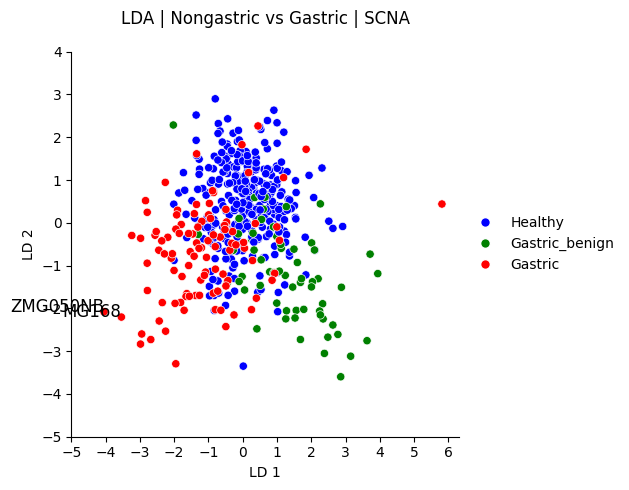

In [ ]:
f='SCNA'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False,figname='LDA.png'
              )

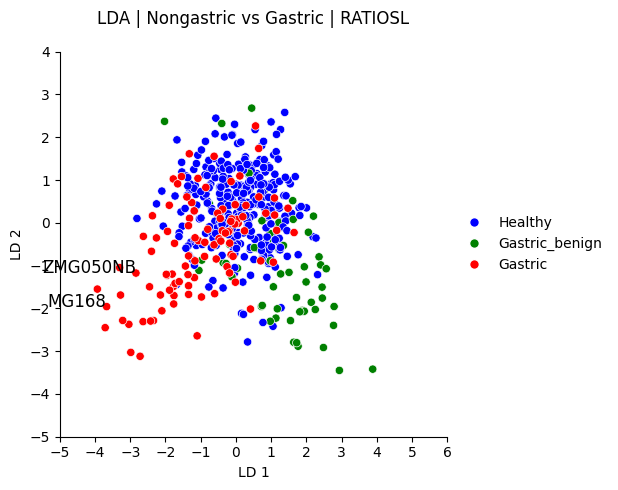

In [ ]:
f='RATIOSL'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False,figname='LDA.png'
              )

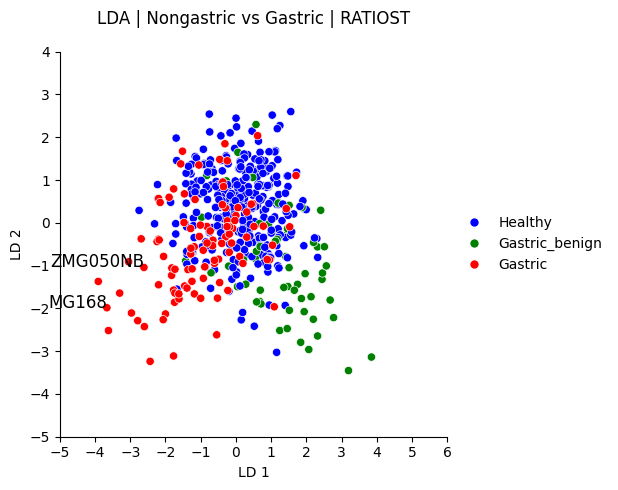

In [ ]:
f='RATIOST'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False)

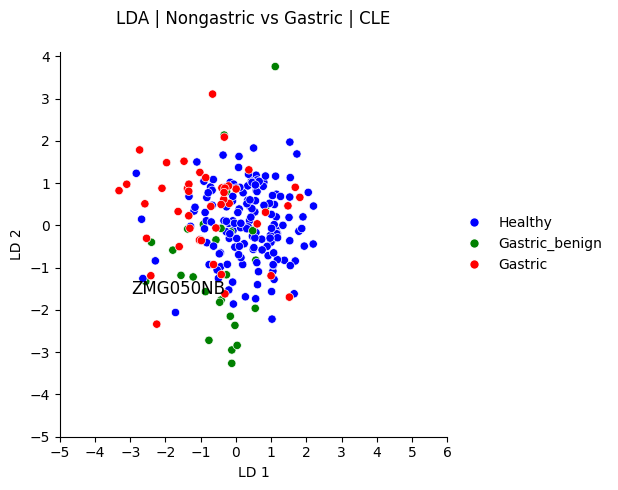

In [ ]:
f='CLE'
LDAsigfea(DATA,SAMPLES,stats_fea=stats_fea,
          dict_cols={'Healthy': 'b', 'Gastric_benign': 'g', 'Gastric': 'r'},
          p='Nongastric vs Gastric',f=f,
              sig=False,alpha=0.05,show_ID=True,IDs=special_samples,
              yticks=[-5,5,1],xticks=[-5,7,1],
              save=False)